<a href="https://colab.research.google.com/github/Capaquira/projectsHighCode/blob/Notebooks/IFP_WHP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import TimeSeriesSplit

# for normalizations
from sklearn import preprocessing

# Metrics
from sklearn.metrics import max_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/DB_ESP_wells_v01.xlsx'

In [ ]:
InputData = pd.read_excel(file_path,
                   sheet_name = 'CleanData')

In [ ]:
InputData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8897 entries, 0 to 8896
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Well             8897 non-null   object        
 1   Date             8897 non-null   datetime64[ns]
 2   Choke            8897 non-null   float64       
 3   WHP_psig         8897 non-null   float64       
 4   FLP_psig         8897 non-null   float64       
 5   Casing_Pr        8897 non-null   float64       
 6   WHT_degF         8897 non-null   float64       
 7   Rate             8897 non-null   float64       
 8   BSW              8897 non-null   float64       
 9   DG_Load_1_Kw     8880 non-null   float64       
 10  DG_Load_2_Kw     8881 non-null   float64       
 11  Freq             7824 non-null   float64       
 12  InputVolt_AB     6933 non-null   float64       
 13  InputVolt_BC     6933 non-null   float64       
 14  InputVolt_CA     6905 non-null   float64

In [ ]:
'''Data Cleaning'''
df_clean = InputData

'''Removing not related physical values'''
df_clean.drop(['FLP_psig'], axis = 1, inplace=True)
df_clean.drop(['Casing_Pr'], axis = 1, inplace=True)
df_clean.drop(['WHT_degF'], axis = 1, inplace=True)

'''Pump only represented by Frequency'''
df_clean.drop(['DG_Load_1_Kw'], axis = 1, inplace=True)
df_clean.drop(['DG_Load_2_Kw'], axis = 1, inplace=True)
df_clean.drop(['InputVolt_AB'], axis = 1, inplace=True)
df_clean.drop(['InputVolt_BC'], axis = 1, inplace=True)
df_clean.drop(['InputVolt_CA'], axis = 1, inplace=True)
df_clean.drop(['VSD_Output_AmpA'], axis = 1, inplace=True)
df_clean.drop(['VSD_Output_AmpB'], axis = 1, inplace=True)
df_clean.drop(['VSD_Output_AmpC'], axis = 1, inplace=True)
df_clean.drop(['DH_AmpA'], axis = 1, inplace=True)
df_clean.drop(['DH_AmpB'], axis = 1, inplace=True)
df_clean.drop(['DH_AmpC'], axis = 1, inplace=True)
df_clean.drop(['Ti_degC'], axis = 1, inplace=True)
df_clean.drop(['Tm_degC'], axis = 1, inplace=True)
df_clean.drop(['Vx_G'], axis = 1, inplace=True)
df_clean.drop(['Vy_G'], axis = 1, inplace=True)
df_clean.drop(['Ct_mA'], axis = 1, inplace=True)
df_clean.drop(['DP_psia'], axis = 1, inplace=True)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8897 entries, 0 to 8896
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Well      8897 non-null   object        
 1   Date      8897 non-null   datetime64[ns]
 2   Choke     8897 non-null   float64       
 3   WHP_psig  8897 non-null   float64       
 4   Rate      8897 non-null   float64       
 5   BSW       8897 non-null   float64       
 6   Freq      7824 non-null   float64       
 7   Pi_psia   8895 non-null   float64       
 8   Pd_psia   8897 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 625.7+ KB


In [ ]:
'''Removing Black space'''
df_clean = df_clean.dropna(subset=['Freq'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7824 entries, 0 to 8896
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Well      7824 non-null   object        
 1   Date      7824 non-null   datetime64[ns]
 2   Choke     7824 non-null   float64       
 3   WHP_psig  7824 non-null   float64       
 4   Rate      7824 non-null   float64       
 5   BSW       7824 non-null   float64       
 6   Freq      7824 non-null   float64       
 7   Pi_psia   7822 non-null   float64       
 8   Pd_psia   7824 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 611.2+ KB


# **Outliers detection**

# **1. Boxplot (BEST quick outlier detector)**

👉 This is the most widely used plot in engineering to detect outliers.

📌 What it detects:

Points outside the interquartile range (IQR)

Extreme abnormal values automatically

/tmp/ipython-input-1904154332.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=well_names)


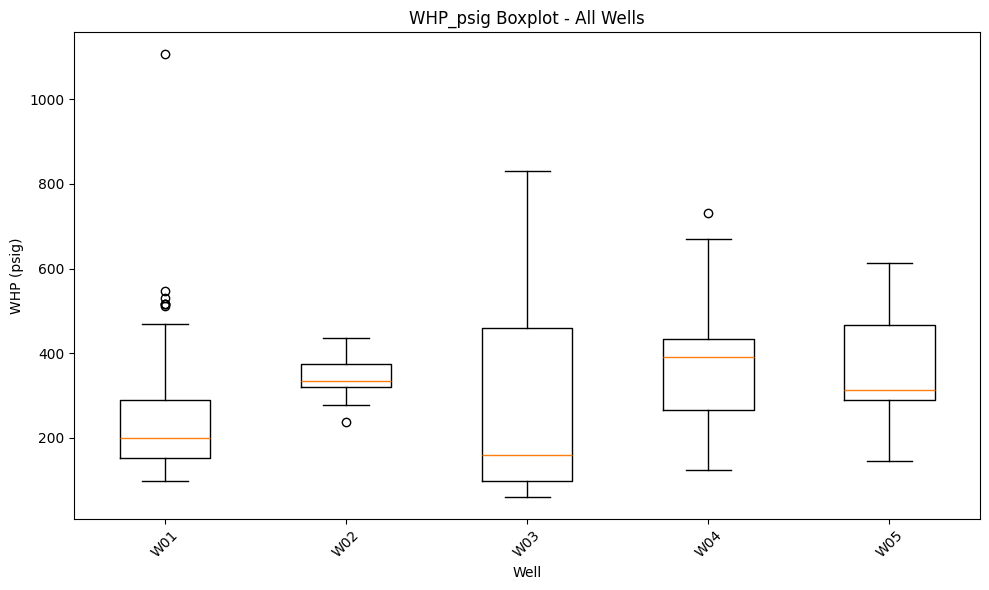

In [ ]:
import matplotlib.pyplot as plt

# Prepare data: list of WHP arrays, one per well
well_names = df_clean["Well"].unique()
data = [InputData[InputData["Well"] == well]["WHP_psig"] for well in well_names]

plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=well_names)

plt.title("WHP_psig Boxplot - All Wells")
plt.ylabel("WHP (psig)")
plt.xlabel("Well")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **2. Scatter: WHP vs Date**

👉 Perfect for detecting:

Sudden spikes

Sensor failures

Data entry errors

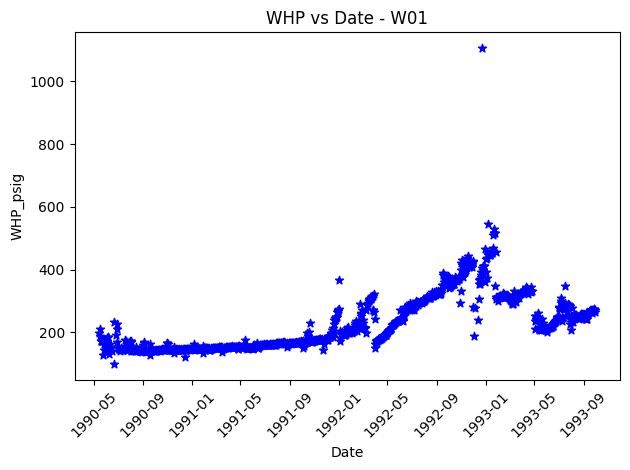

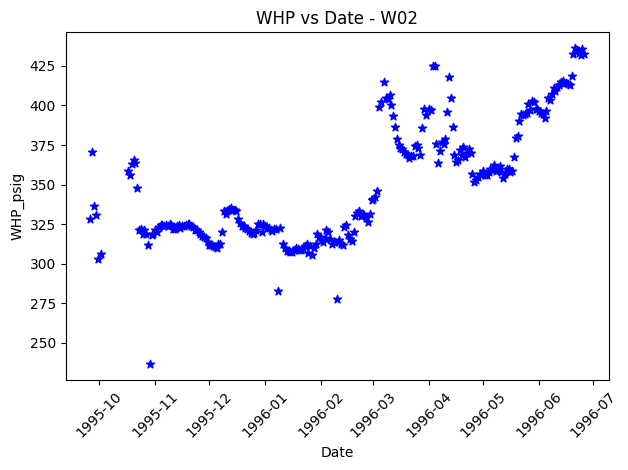

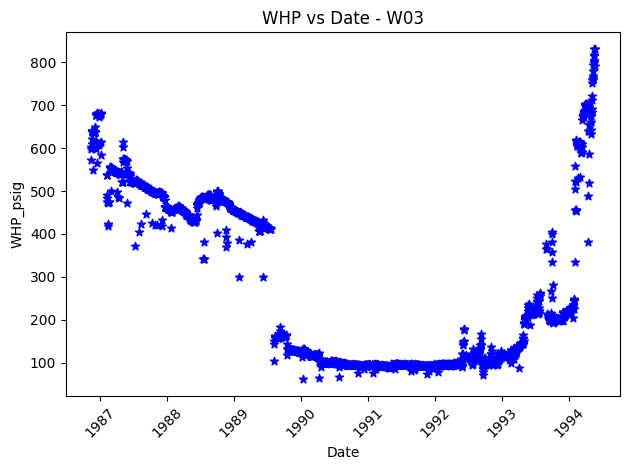

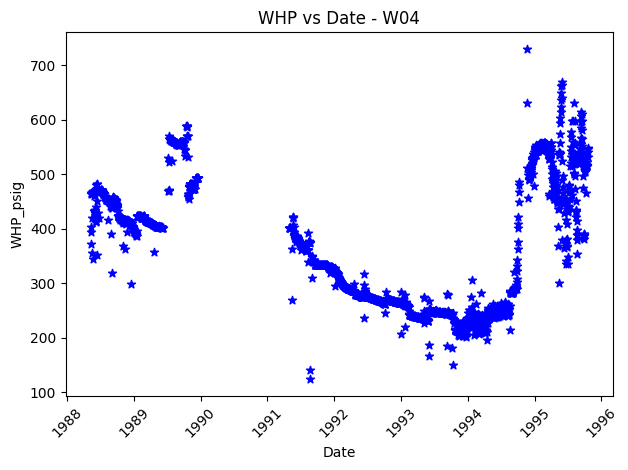

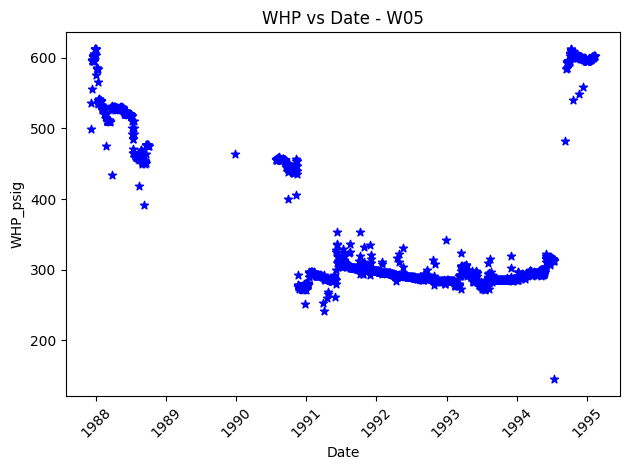

In [ ]:
for well, group in df_clean.groupby("Well"):

    plt.figure()  # ✅ Un solo gráfico por pozo

    plt.scatter(group["Date"], group["WHP_psig"],c='blue', marker='*')

    plt.xlabel("Date")
    plt.ylabel("WHP_psig")
    plt.title(f"WHP vs Date - {well}")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# **3. Histogram (To detect abnormal distributions)**

👉 Useful to detect:

Long tails

Abnormal measurement ranges

Physically impossible values

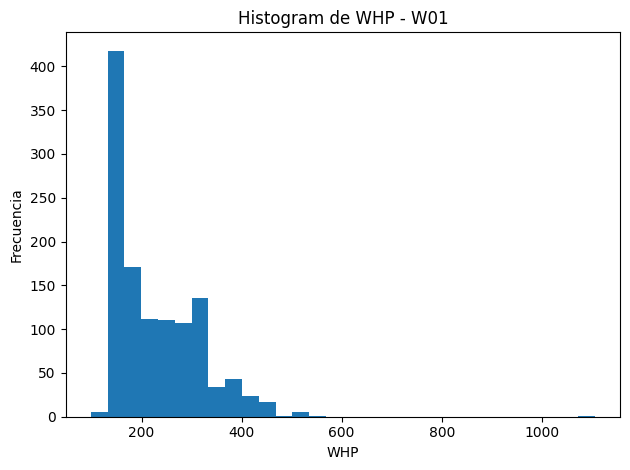

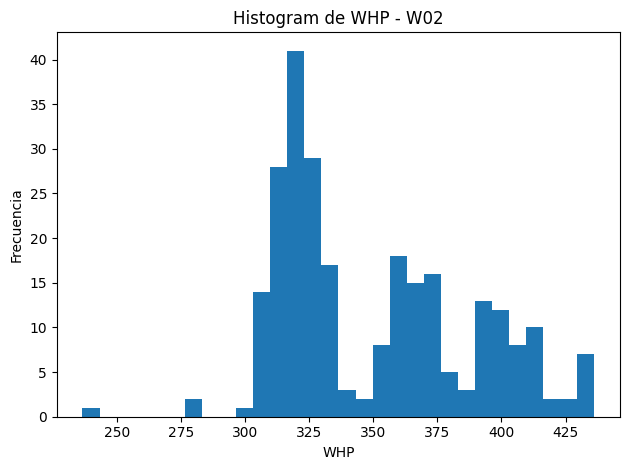

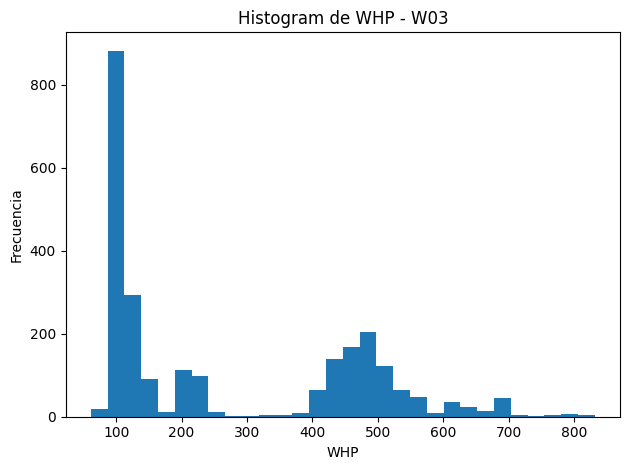

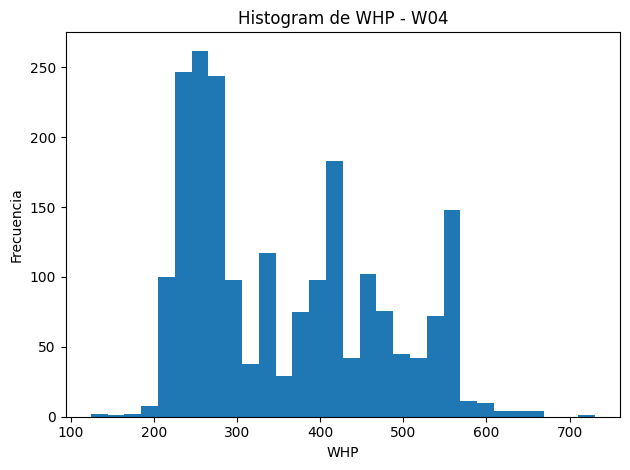

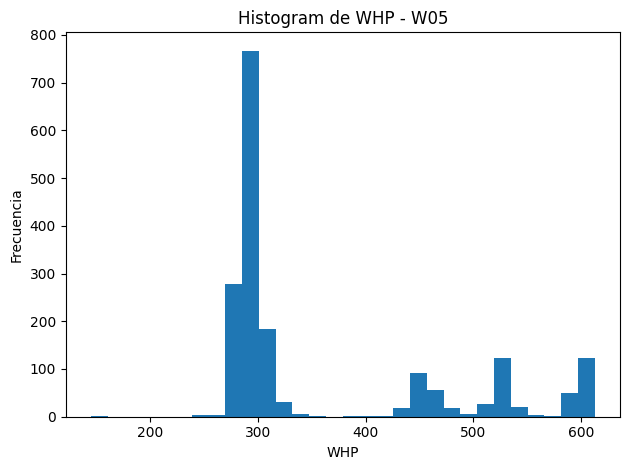

In [ ]:
for well, group in df_clean.groupby("Well"):

    plt.figure()
    plt.hist(group["WHP_psig"], bins=30)

    plt.xlabel("WHP")
    plt.ylabel("Frecuencia")
    plt.title(f"Histogram de WHP - {well}")

    plt.tight_layout()
    plt.show()


# **4. Q–Q Plot (Advanced statistical validation)**

👉 Checks if data follows a normal distribution
👉 Points far from the diagonal = outliers

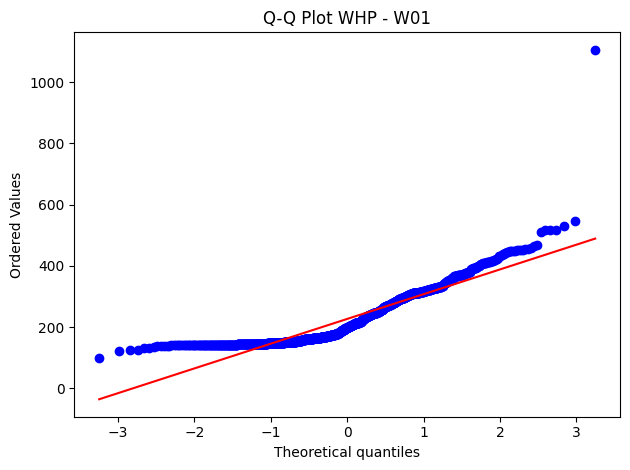

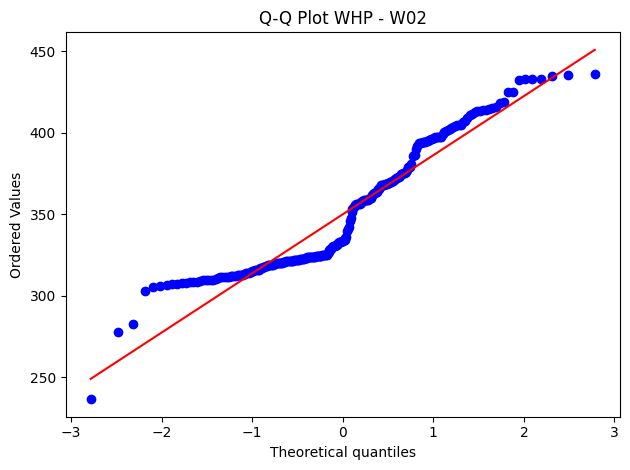

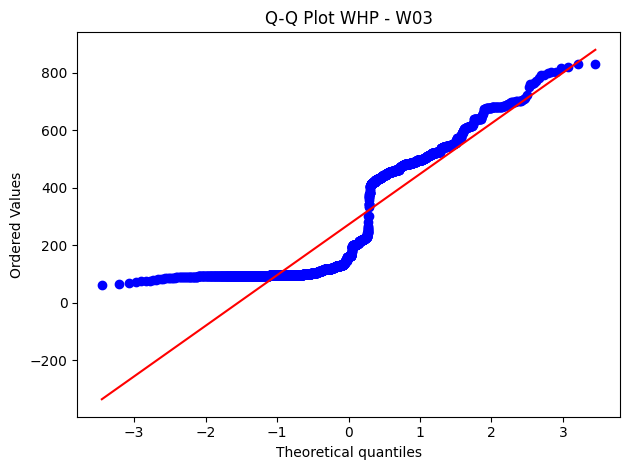

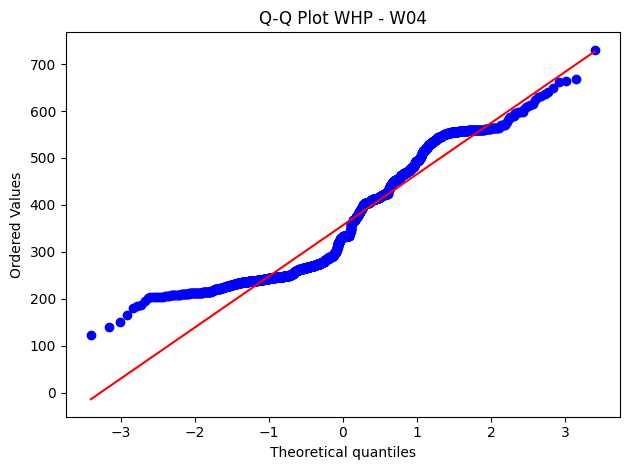

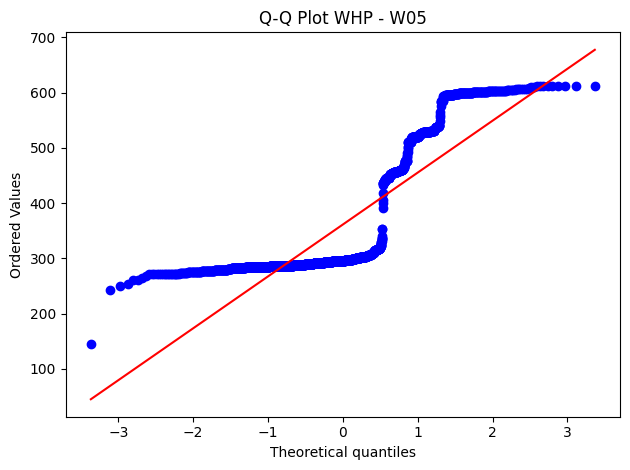

In [ ]:
import scipy.stats as stats

for well, group in df_clean.groupby("Well"):

    plt.figure()
    stats.probplot(group["WHP_psig"], plot=plt)

    plt.title(f"Q-Q Plot WHP - {well}")
    plt.tight_layout()
    plt.show()


# **5. Scatter: WHP vs Another Variable (Physical validation)**

Example: WHP vs Qoil

👉 Detects:

Physically impossible measurements

Badly calibrated sensors

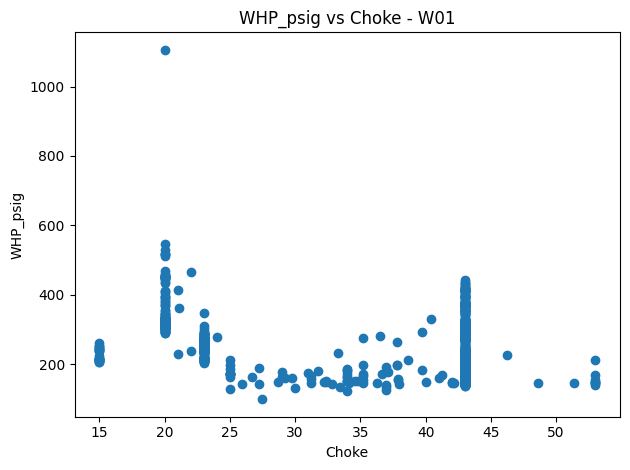

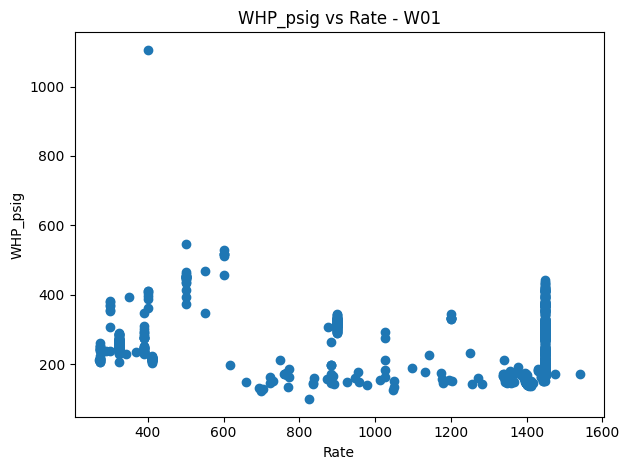

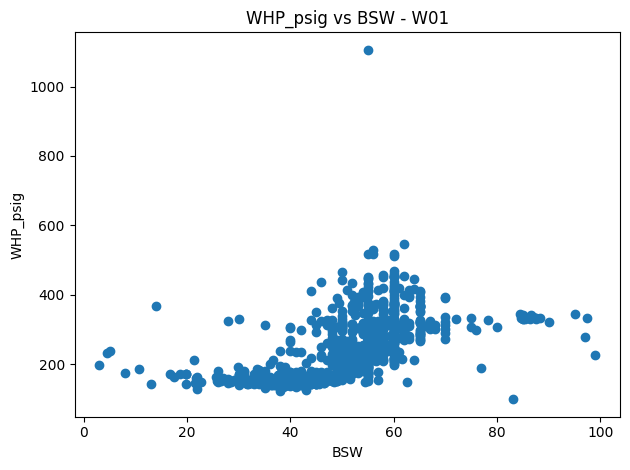

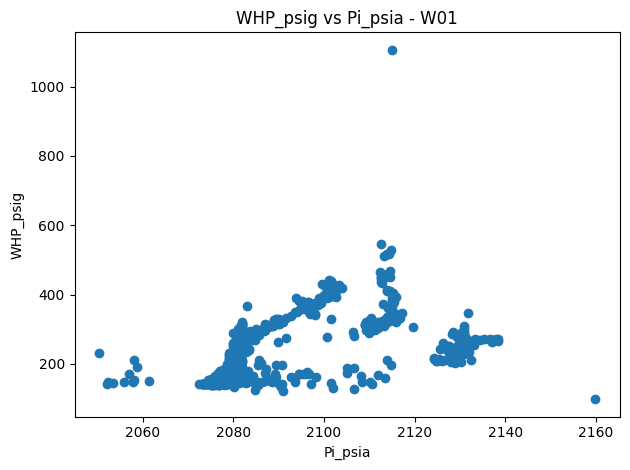

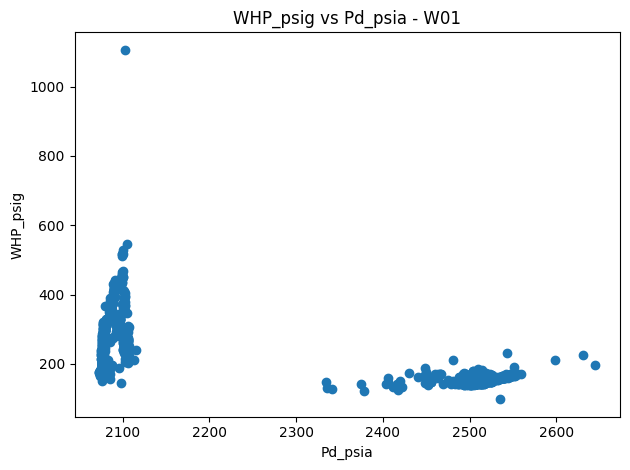

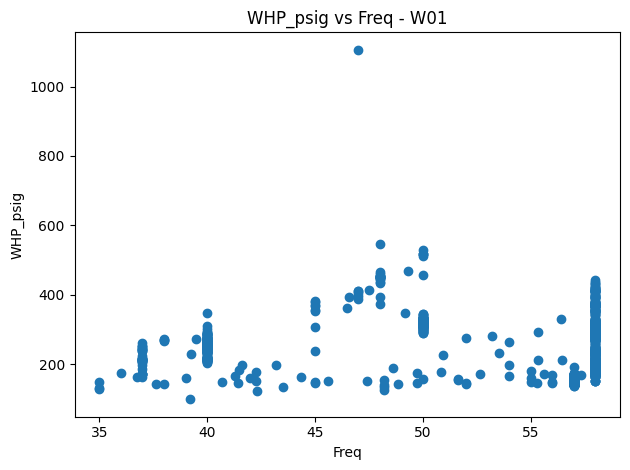

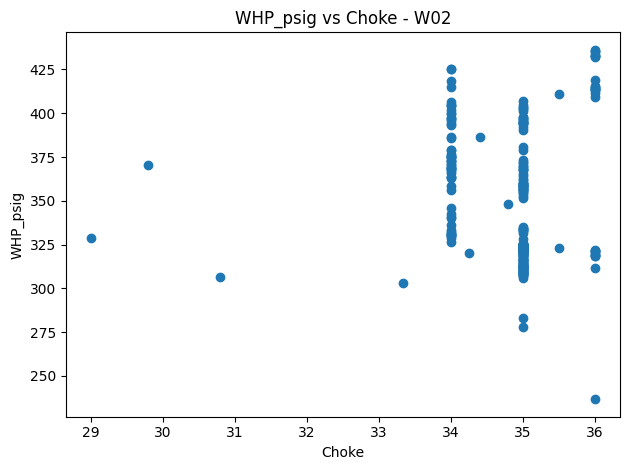

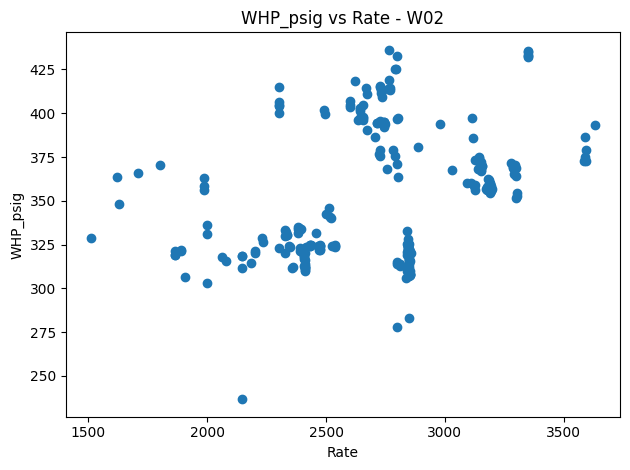

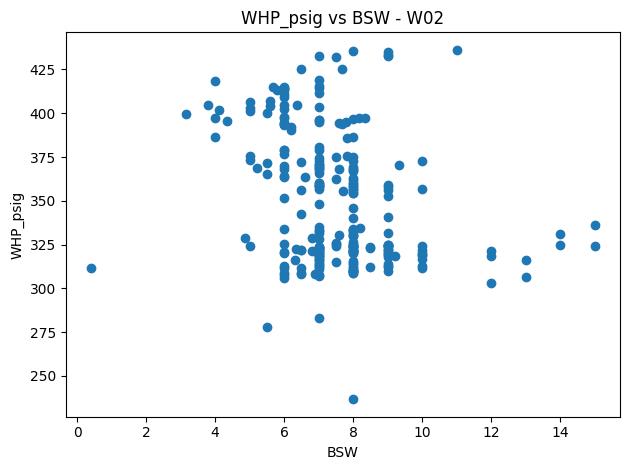

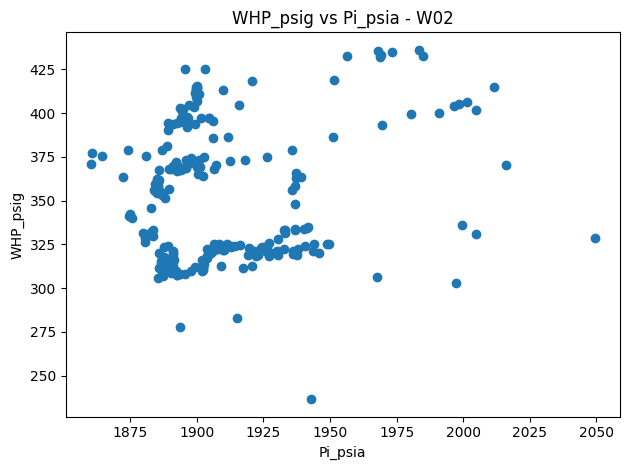

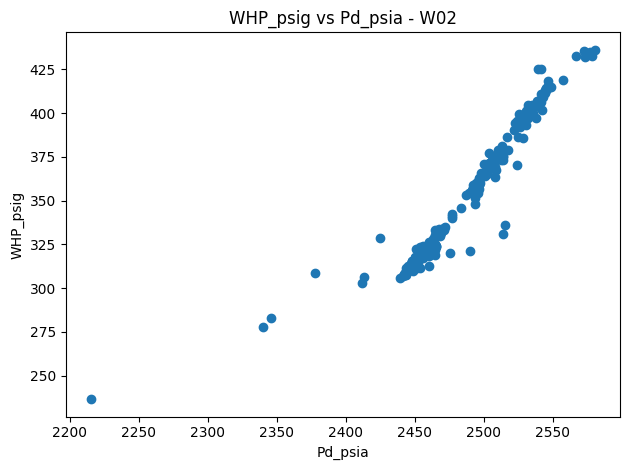

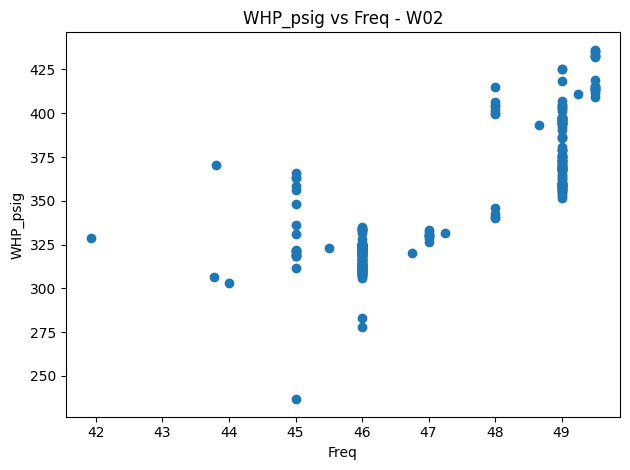

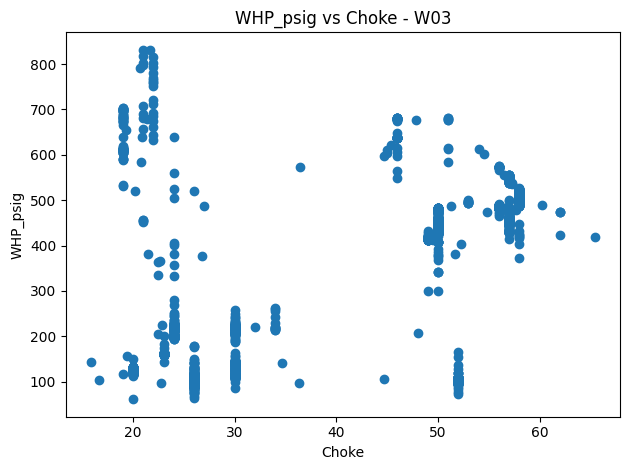

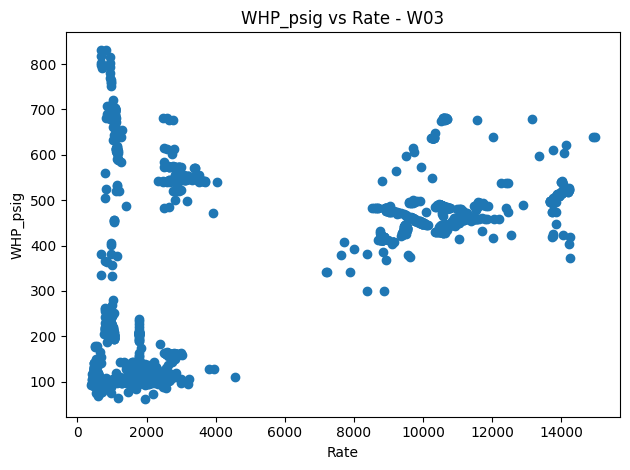

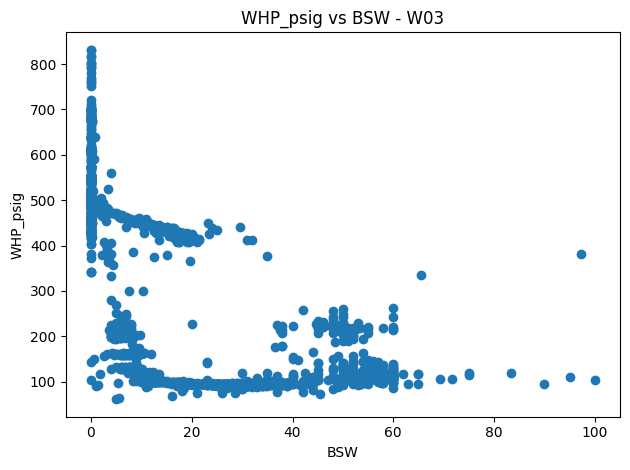

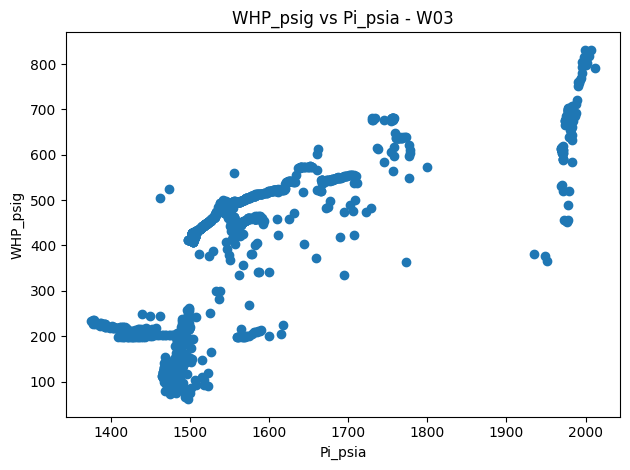

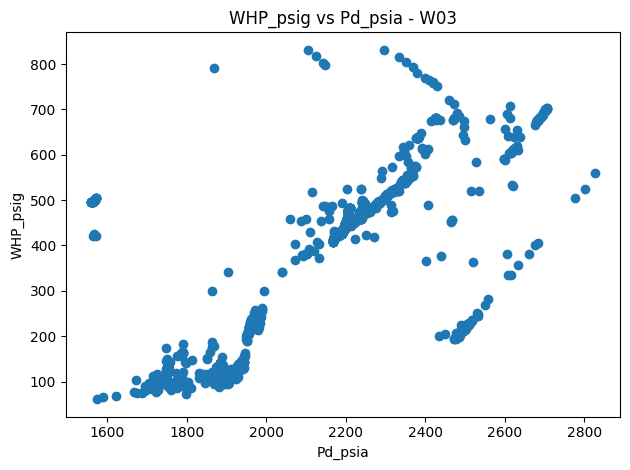

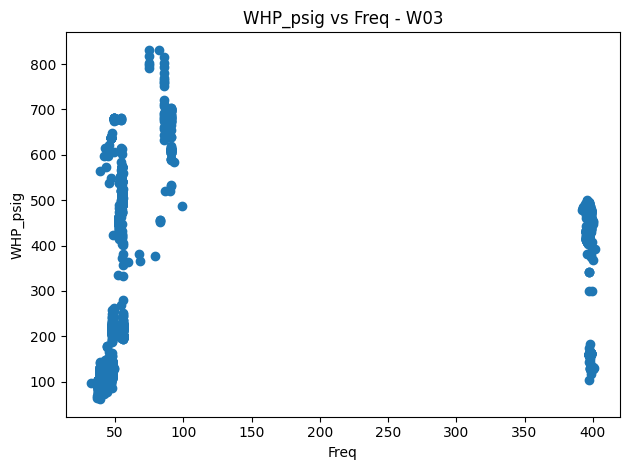

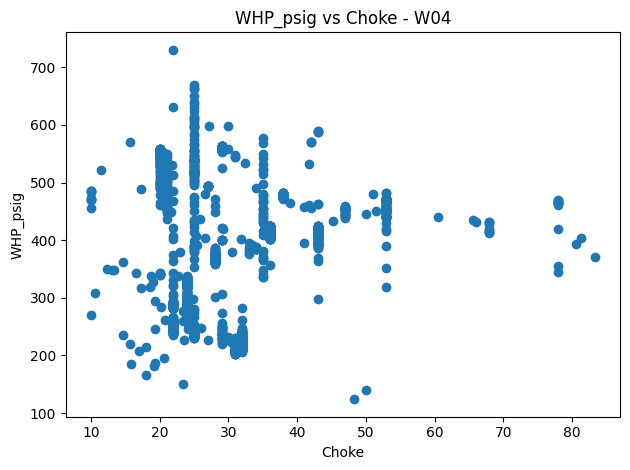

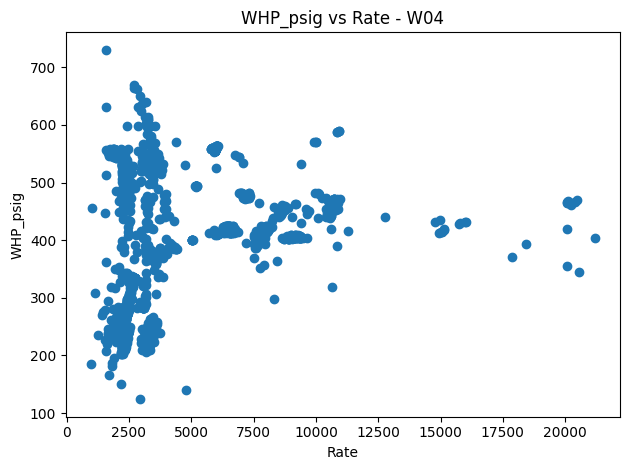

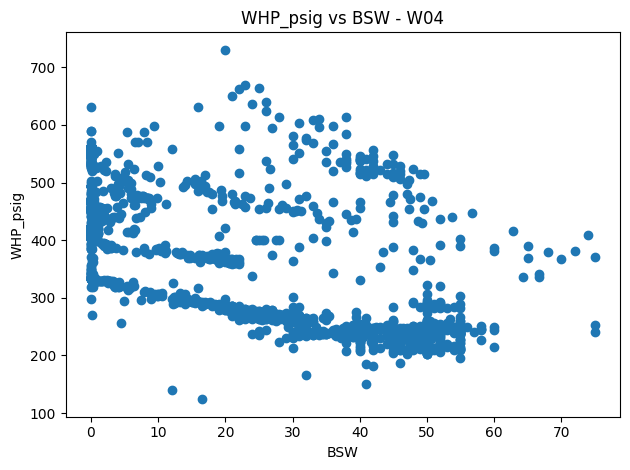

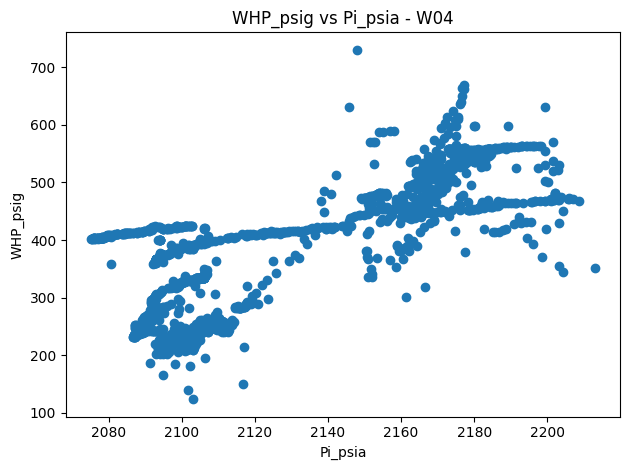

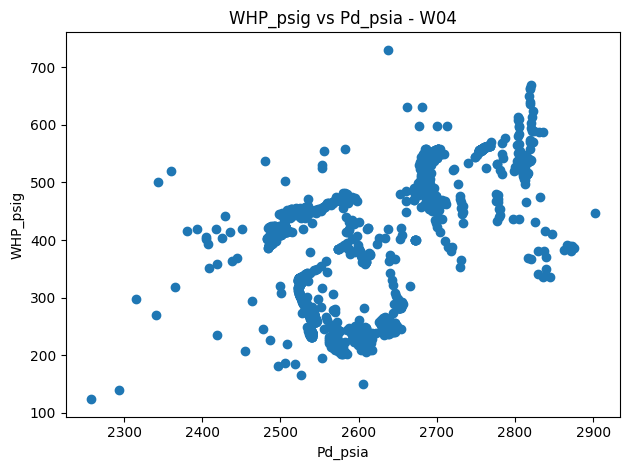

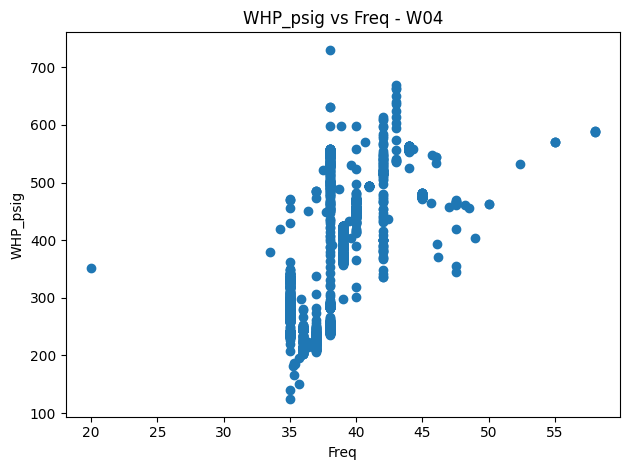

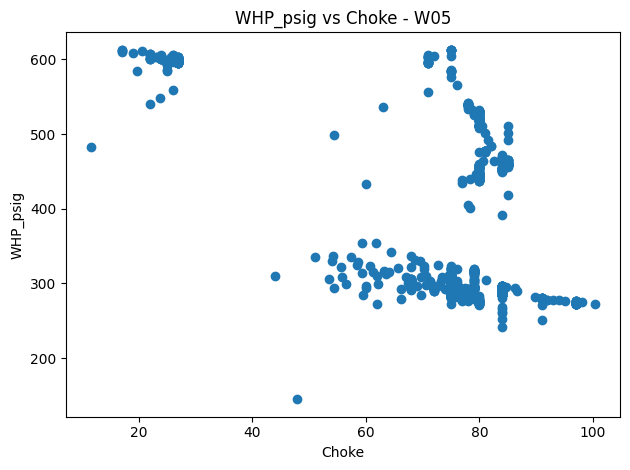

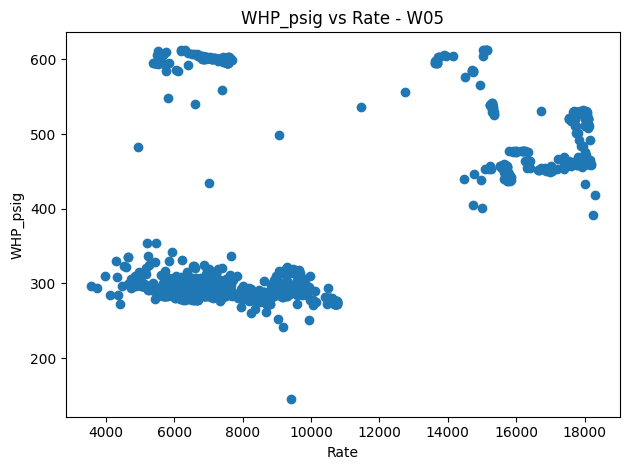

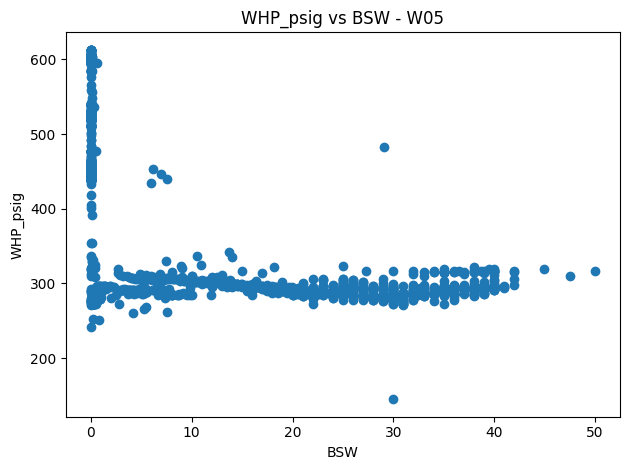

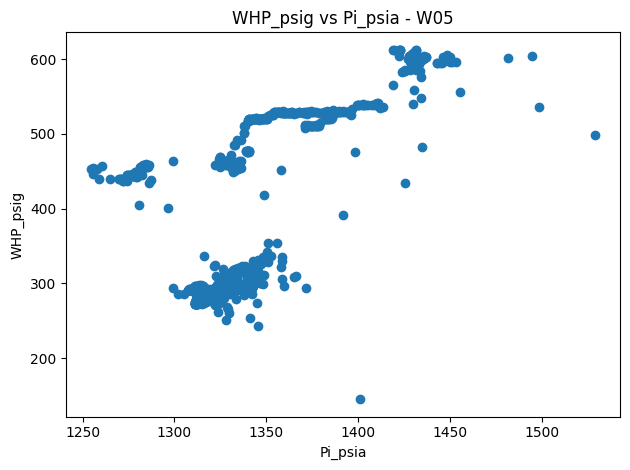

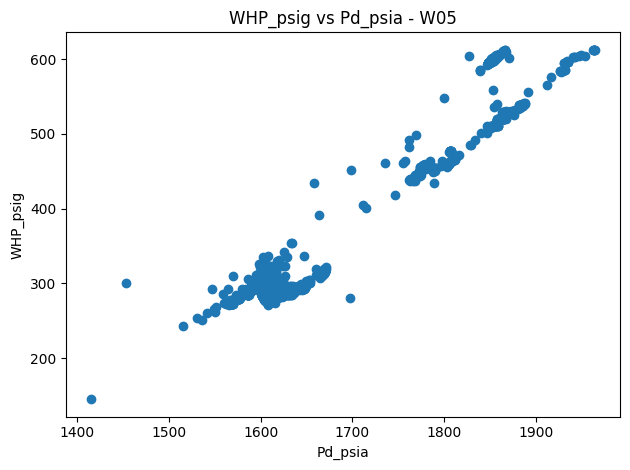

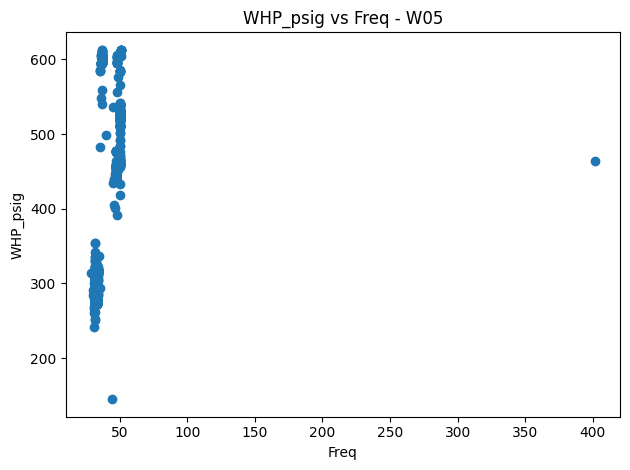

In [ ]:
x_vars = ["Choke", "Rate", "BSW", "Pi_psia", "Pd_psia", "Freq"]
y_var = "WHP_psig"

for well, group in df_clean.groupby("Well"):

    for x in x_vars:

        # Skip variable if it does not exist in the dataset
        if x not in group.columns:
            print(f"Skipping {x} (not found in columns)")
            continue

        plt.figure()

        plt.scatter(group[x], group[y_var], marker="o")

        plt.xlabel(x)
        plt.ylabel(y_var)
        plt.title(f"{y_var} vs {x} - {well}")

        plt.tight_layout()
        plt.show()


# **AUTOMATIC OUTLIER HIGHLIGHTING** (WITHOUT DELETING)

In [ ]:
import numpy as np

def detect_outliers_iqr(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    mask_outliers = (series < lower) | (series > upper)
    return mask_outliers

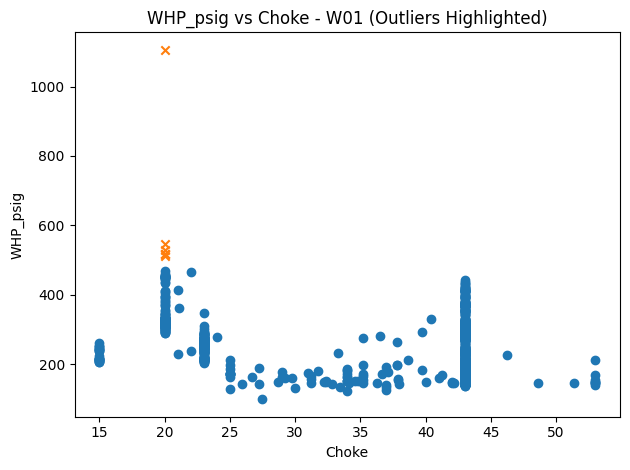

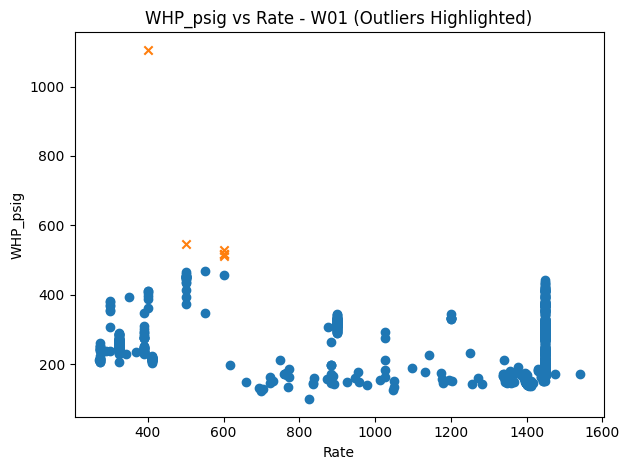

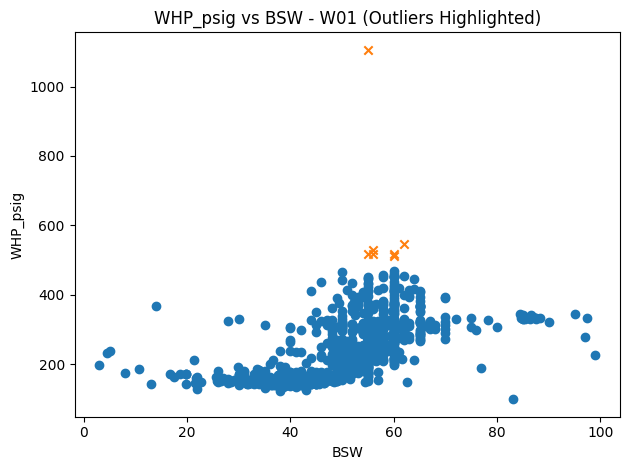

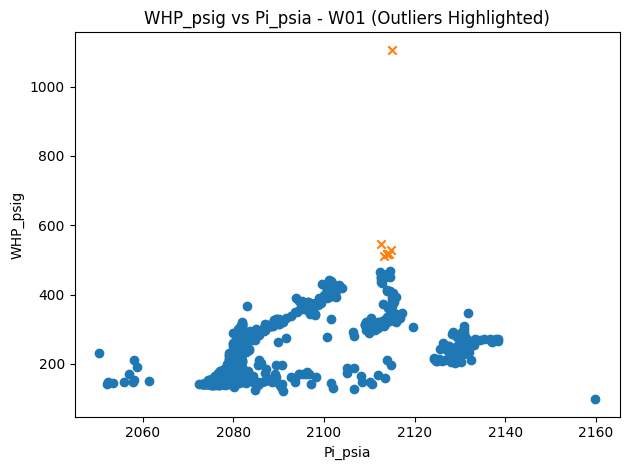

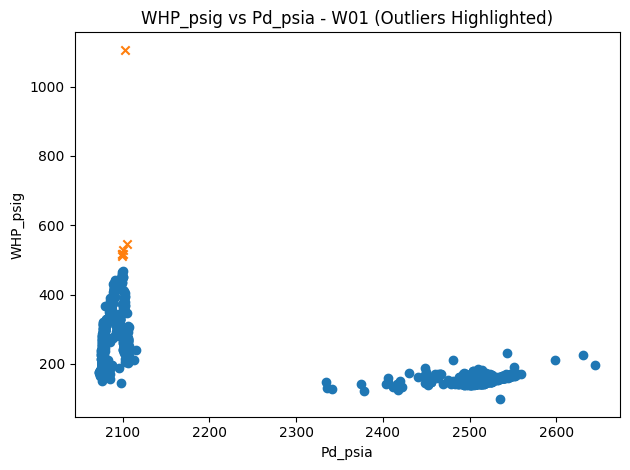

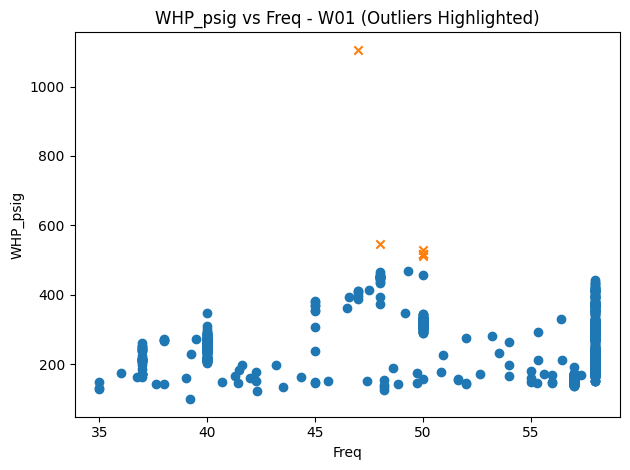

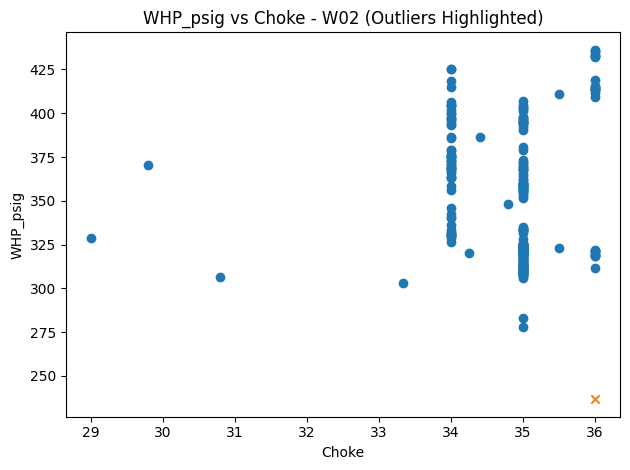

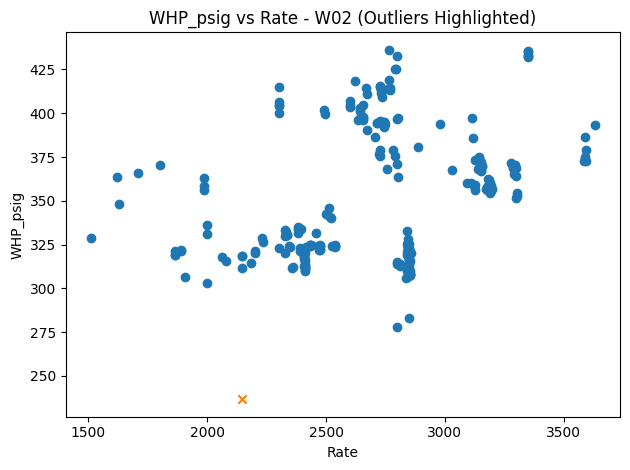

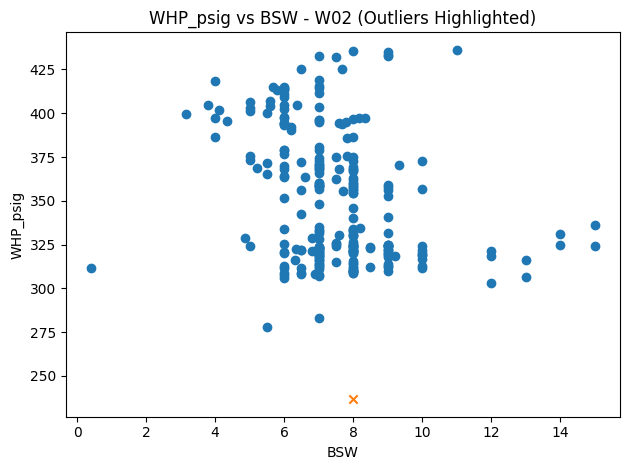

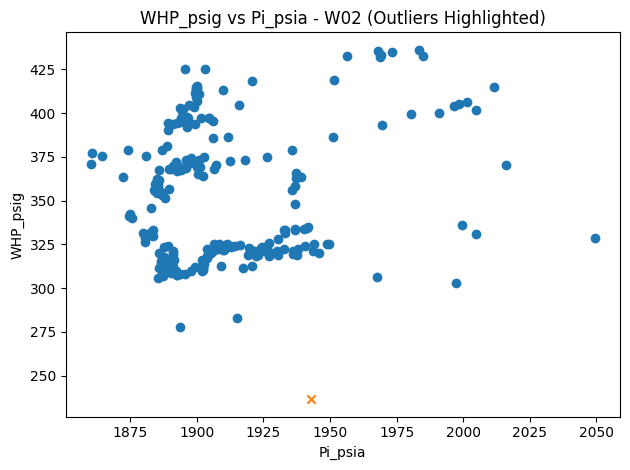

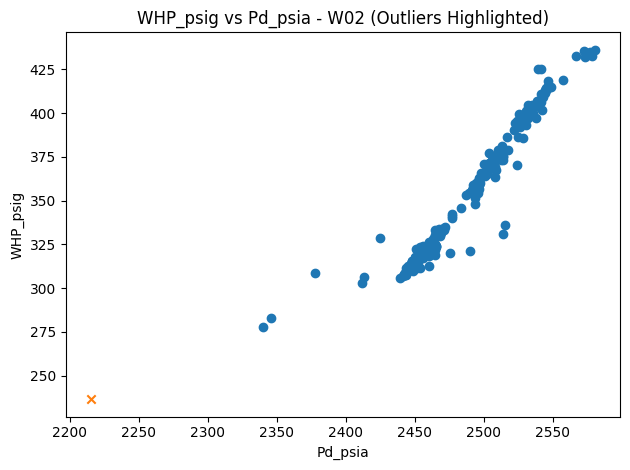

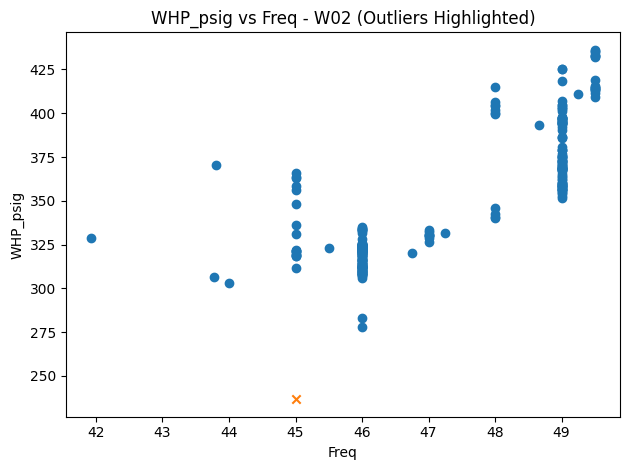

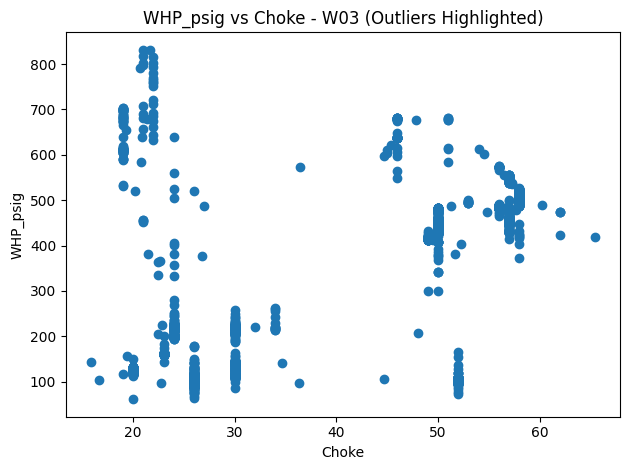

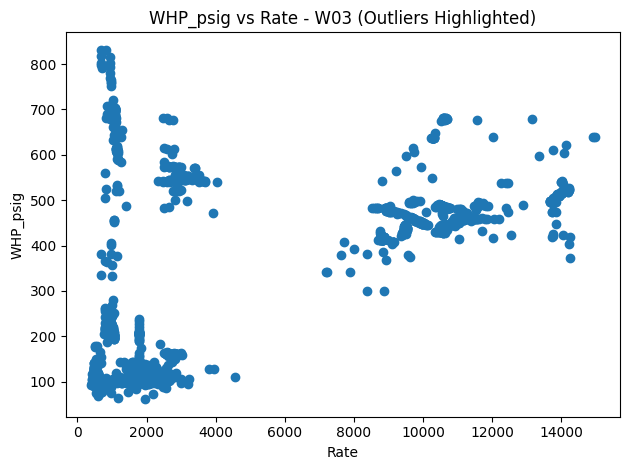

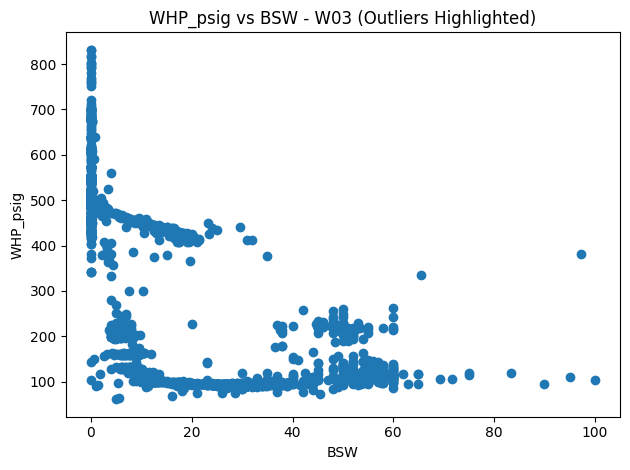

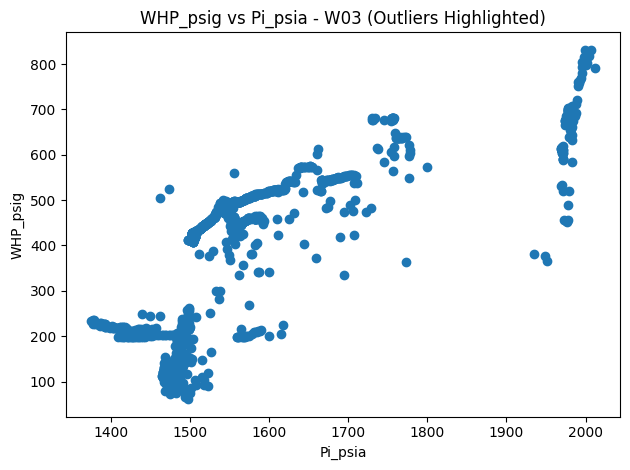

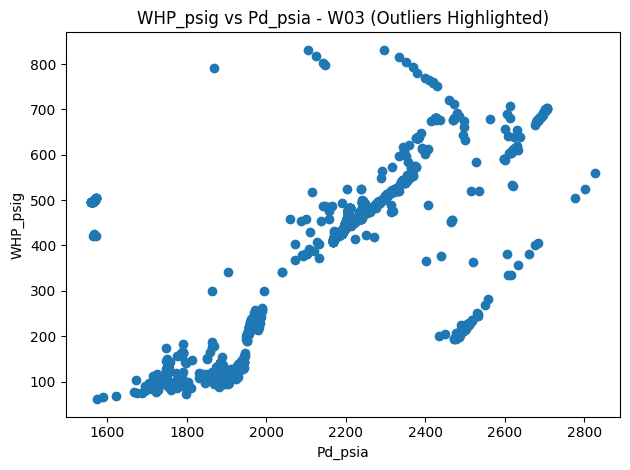

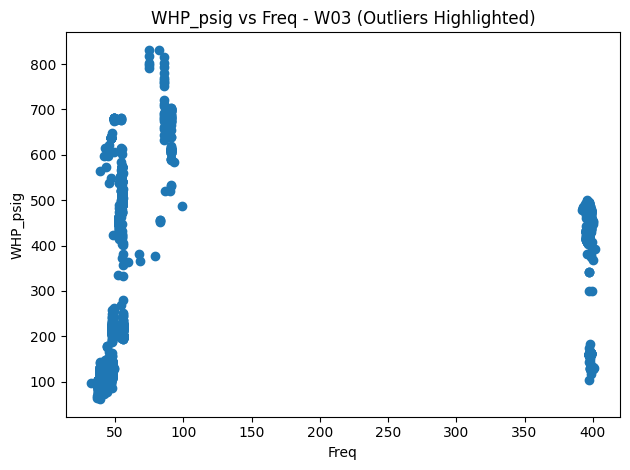

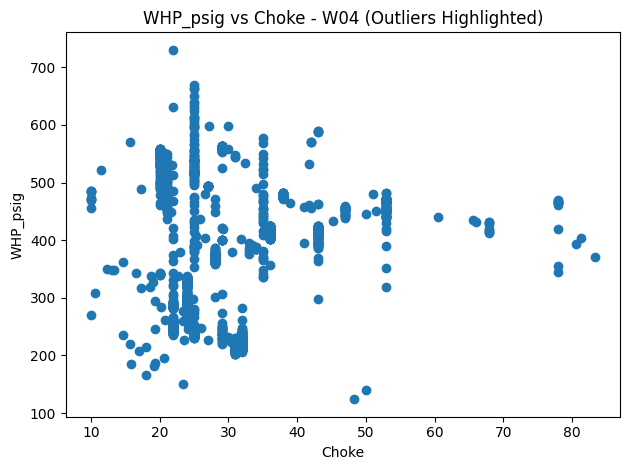

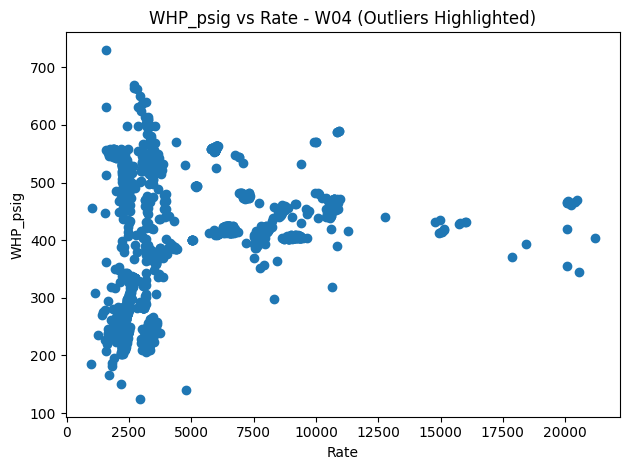

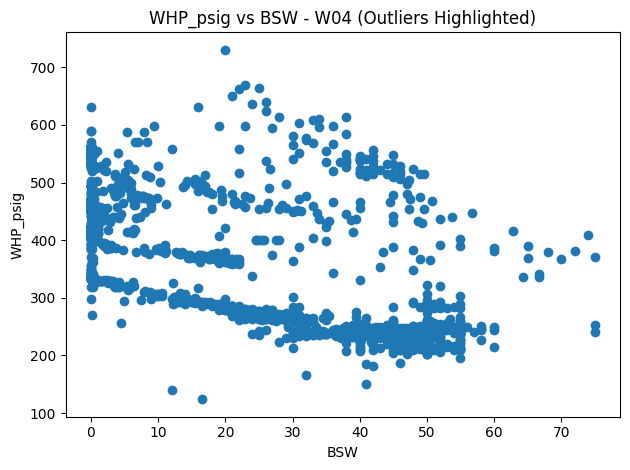

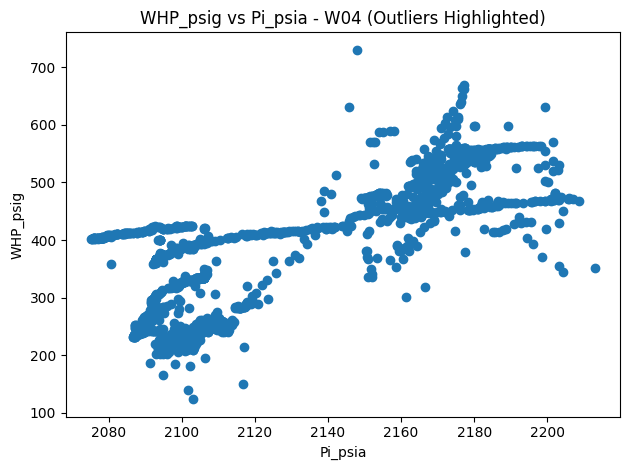

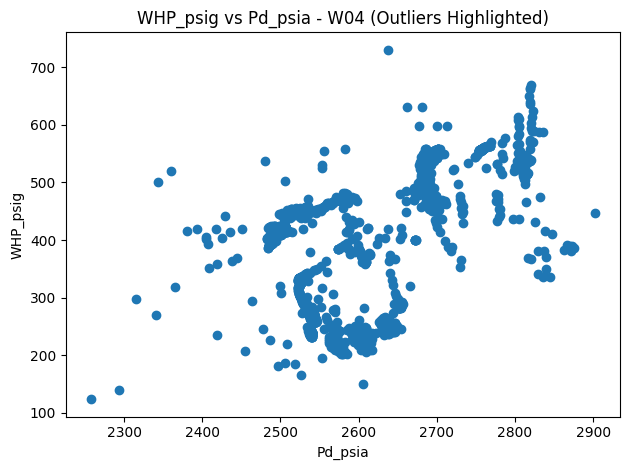

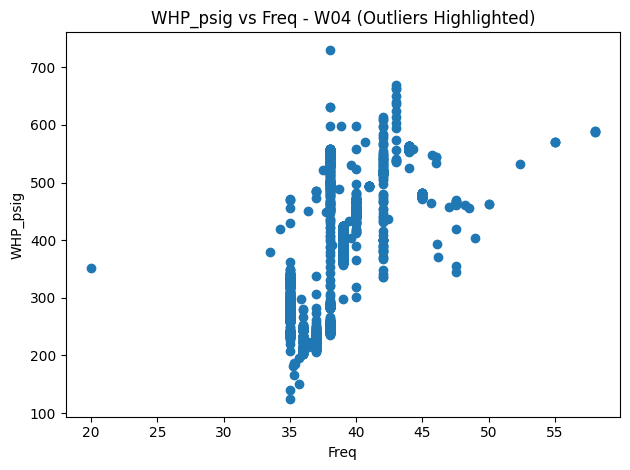

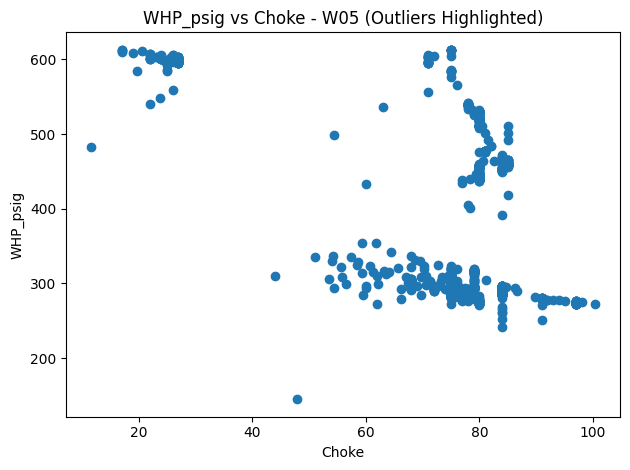

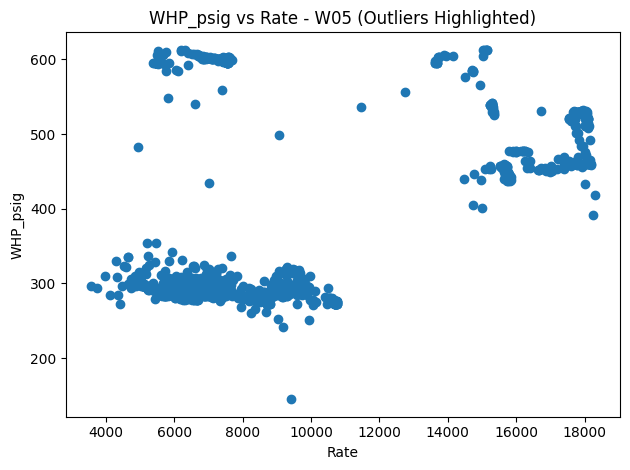

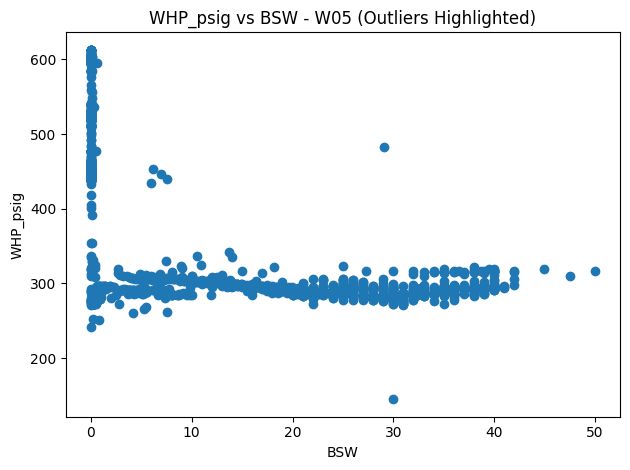

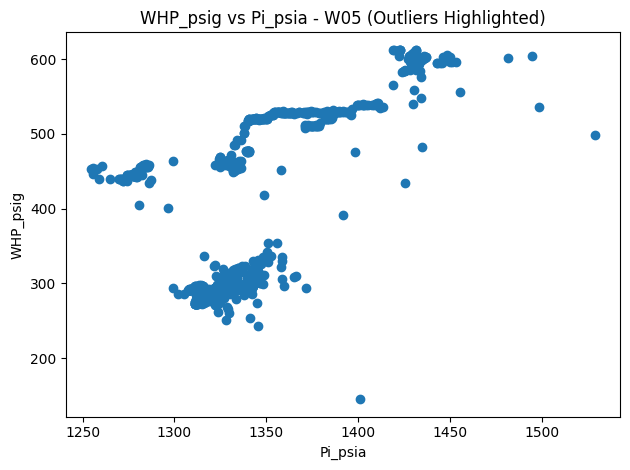

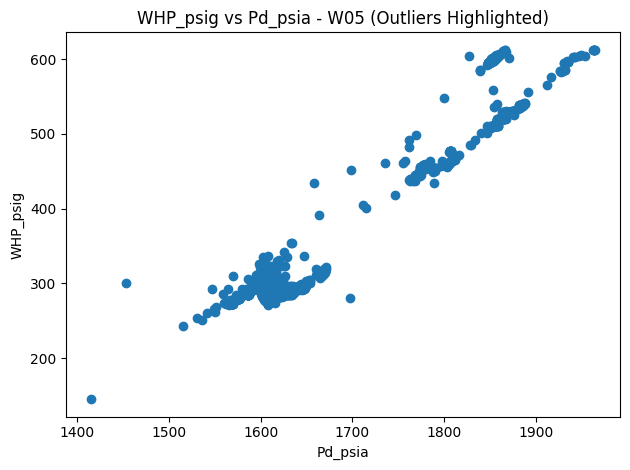

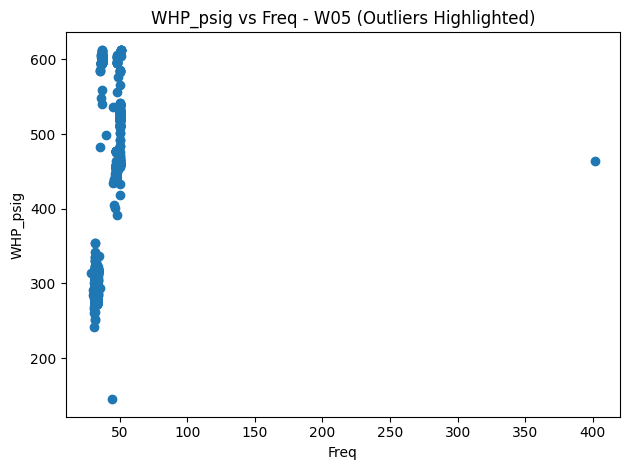

In [ ]:
import matplotlib.pyplot as plt

x_vars = ["Choke", "Rate", "BSW", "Pi_psia", "Pd_psia", "Freq"]
y_var = "WHP_psig"

for well, group in df_clean.groupby("Well"):

    outlier_mask = detect_outliers_iqr(group[y_var])

    for x in x_vars:

        if x not in group.columns:
            continue

        plt.figure()

        # ✅ Normal data
        plt.scatter(
            group.loc[~outlier_mask, x],
            group.loc[~outlier_mask, y_var],
            marker="o"
        )

        # ✅ Outliers highlighted (not removed)
        plt.scatter(
            group.loc[outlier_mask, x],
            group.loc[outlier_mask, y_var],
            marker="x"
        )

        plt.xlabel(x)
        plt.ylabel(y_var)
        plt.title(f"{y_var} vs {x} - {well} (Outliers Highlighted)")

        plt.tight_layout()
        plt.show()


4. BEFORE vs AFTER CLEANING PLOTS (AUTOMATIC)

In [ ]:
clean_dfs = []

for well, group in df_clean.groupby("Well"):
    outlier_mask = detect_outliers_iqr(group[y_var])
    df_cle = group.loc[~outlier_mask].copy()
    clean_dfs.append(df_cle)

df_no_outliers = pd.concat(clean_dfs).reset_index(drop=True)


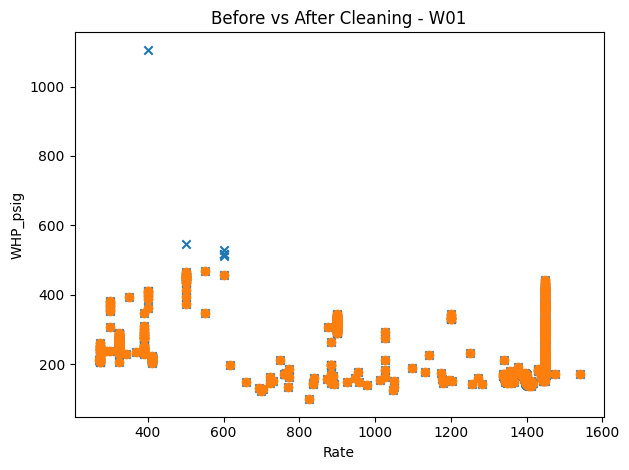

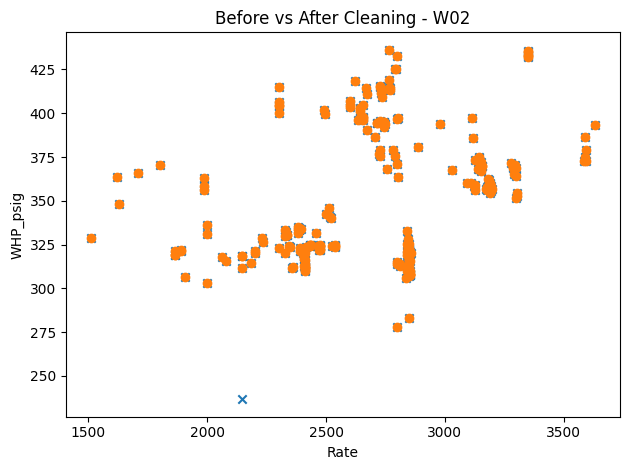

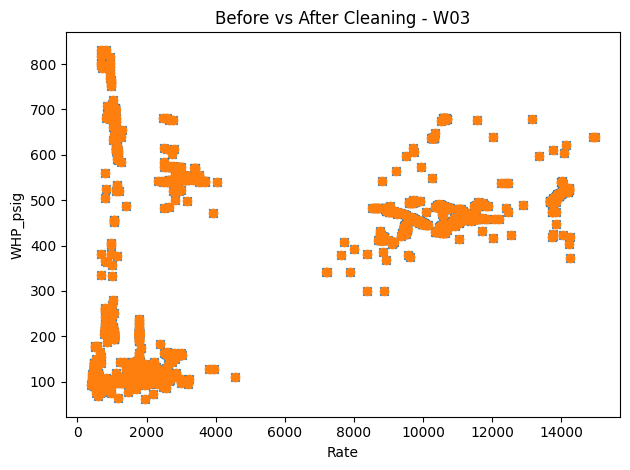

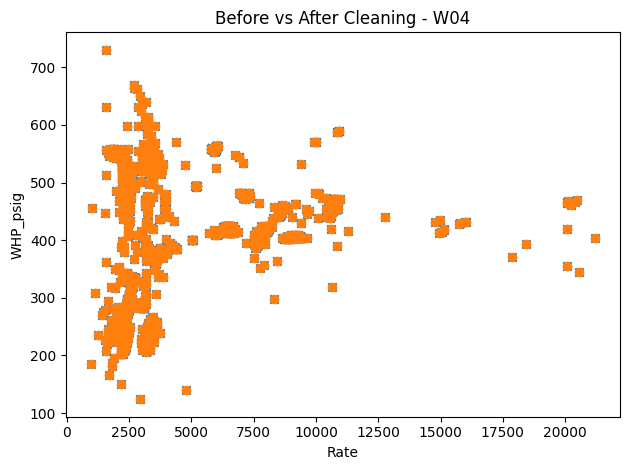

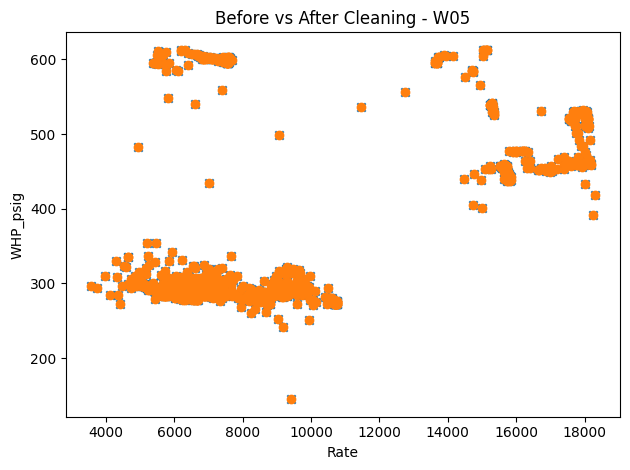

In [ ]:
for well, group in df_clean.groupby("Well"):

    group_clean = df_no_outliers[df_no_outliers["Well"] == well]

    plt.figure()
    plt.scatter(group["Rate"], group[y_var], marker="x")   # BEFORE
    plt.scatter(group_clean["Rate"], group_clean[y_var], marker="o")  # AFTER

    plt.xlabel("Rate")
    plt.ylabel(y_var)
    plt.title(f"Before vs After Cleaning - {well}")

    plt.tight_layout()
    plt.show()


In [ ]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7816 entries, 0 to 7815
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Well      7816 non-null   object        
 1   Date      7816 non-null   datetime64[ns]
 2   Choke     7816 non-null   float64       
 3   WHP_psig  7816 non-null   float64       
 4   Rate      7816 non-null   float64       
 5   BSW       7816 non-null   float64       
 6   Freq      7816 non-null   float64       
 7   Pi_psia   7814 non-null   float64       
 8   Pd_psia   7816 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 549.7+ KB


All well boxplot

/tmp/ipython-input-2910548443.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=well_names)


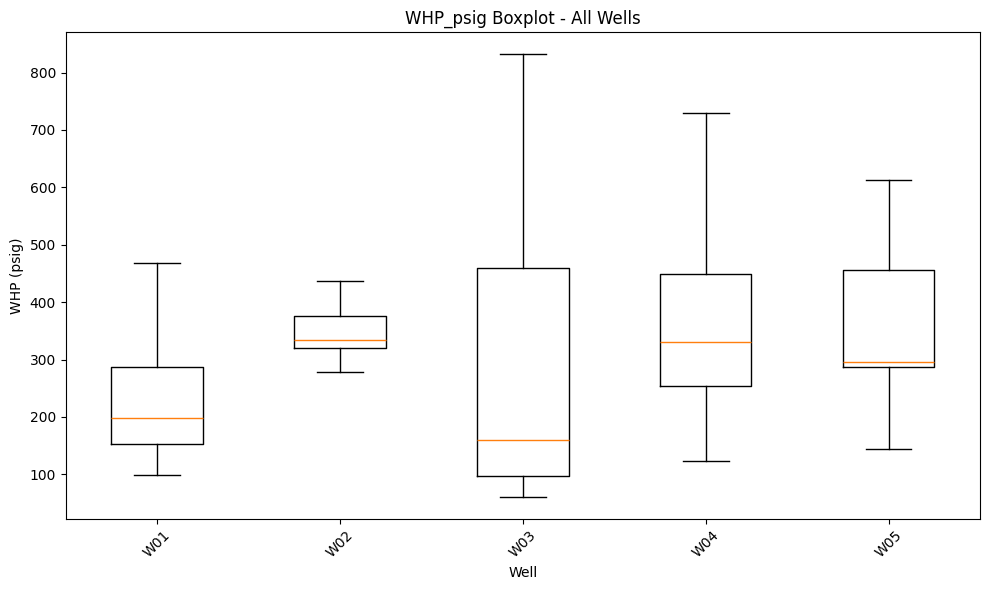

In [ ]:
import matplotlib.pyplot as plt

# Prepare data: list of WHP arrays, one per well
well_names = df_no_outliers["Well"].unique()
data = [df_no_outliers[df_no_outliers["Well"] == well]["WHP_psig"] for well in well_names]

plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=well_names)

plt.title("WHP_psig Boxplot - All Wells")
plt.ylabel("WHP (psig)")
plt.xlabel("Well")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7816 entries, 0 to 7815
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Well      7816 non-null   object        
 1   Date      7816 non-null   datetime64[ns]
 2   Choke     7816 non-null   float64       
 3   WHP_psig  7816 non-null   float64       
 4   Rate      7816 non-null   float64       
 5   BSW       7816 non-null   float64       
 6   Freq      7816 non-null   float64       
 7   Pi_psia   7814 non-null   float64       
 8   Pd_psia   7816 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 549.7+ KB


WHP vs time to check other outliers

<Figure size 640x480 with 0 Axes>

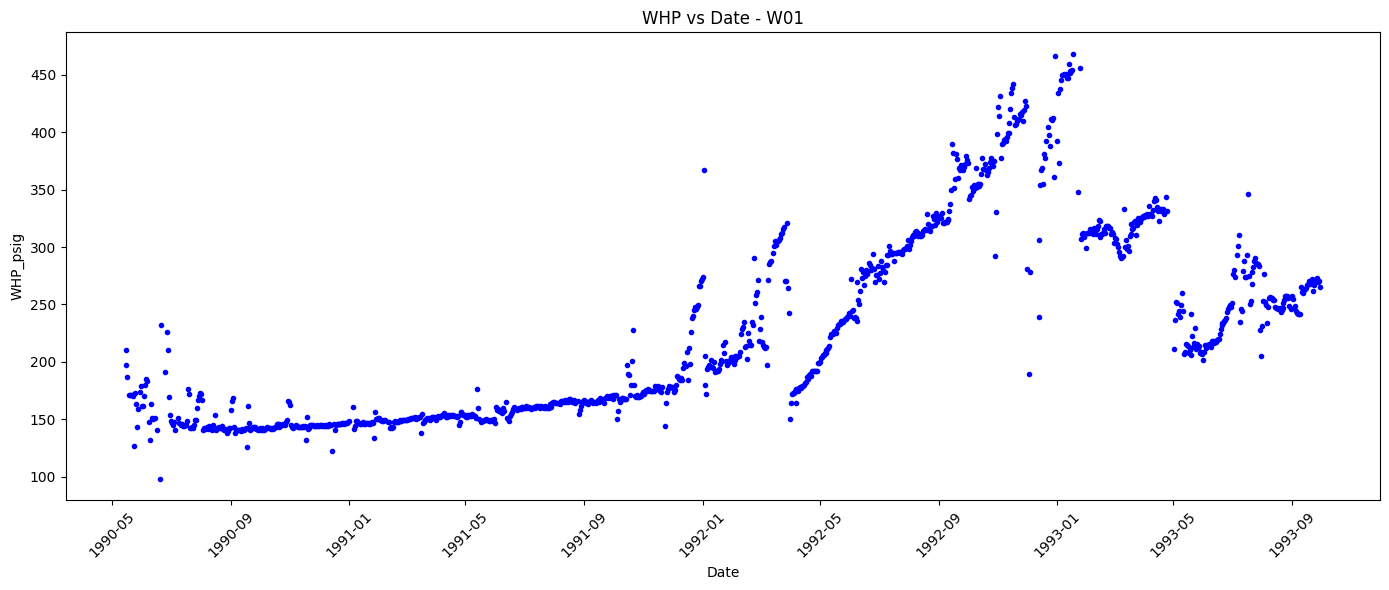

<Figure size 640x480 with 0 Axes>

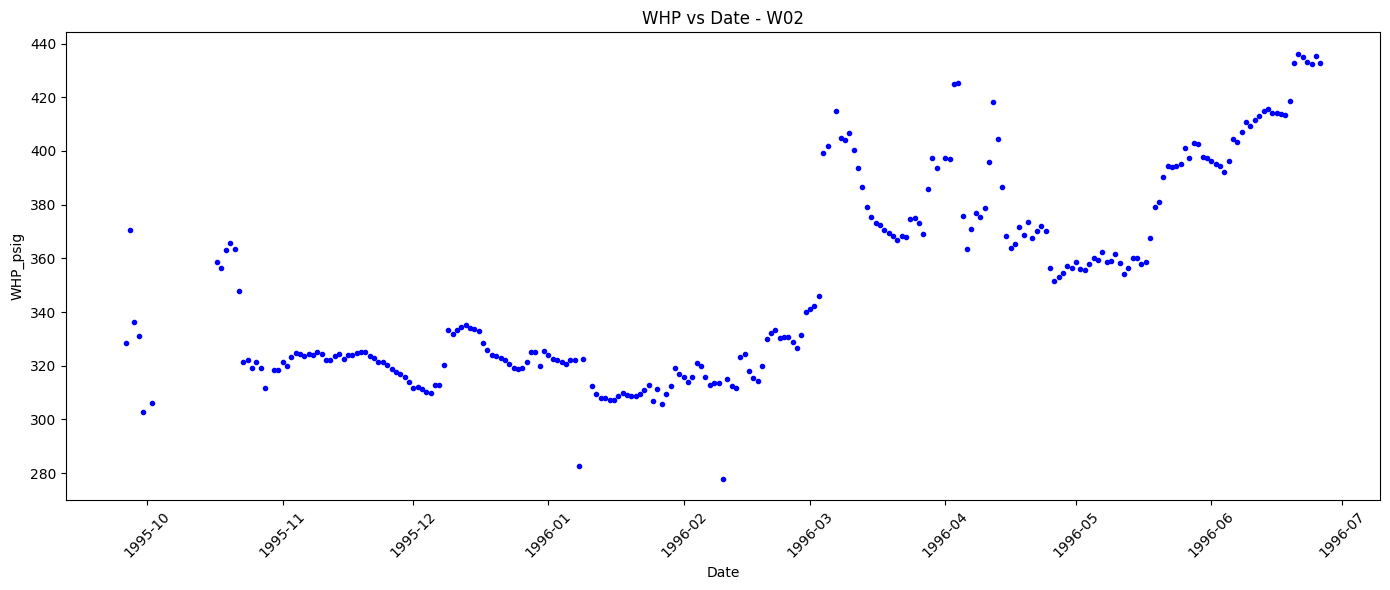

<Figure size 640x480 with 0 Axes>

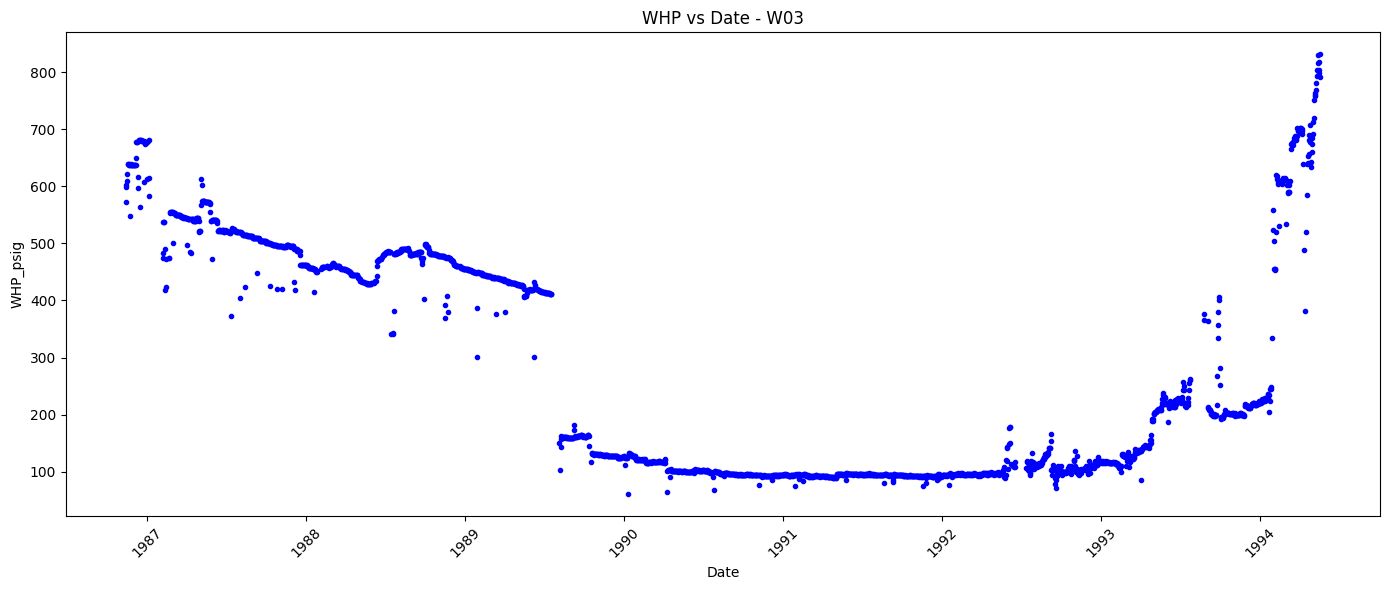

<Figure size 640x480 with 0 Axes>

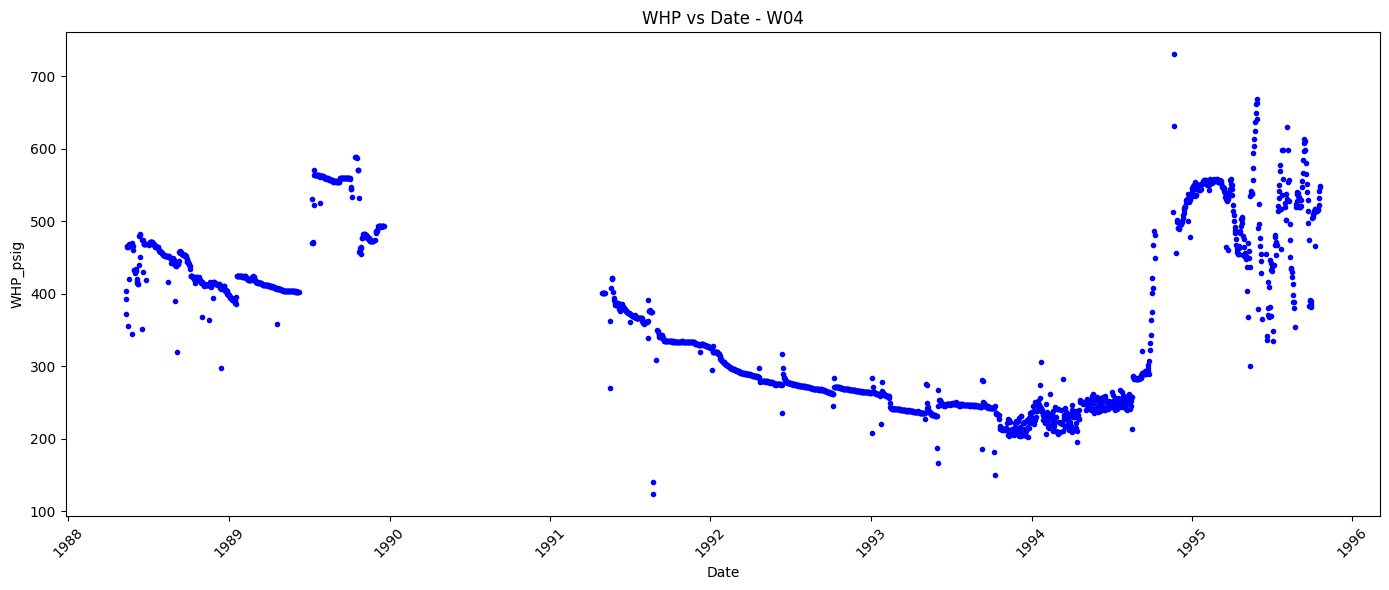

<Figure size 640x480 with 0 Axes>

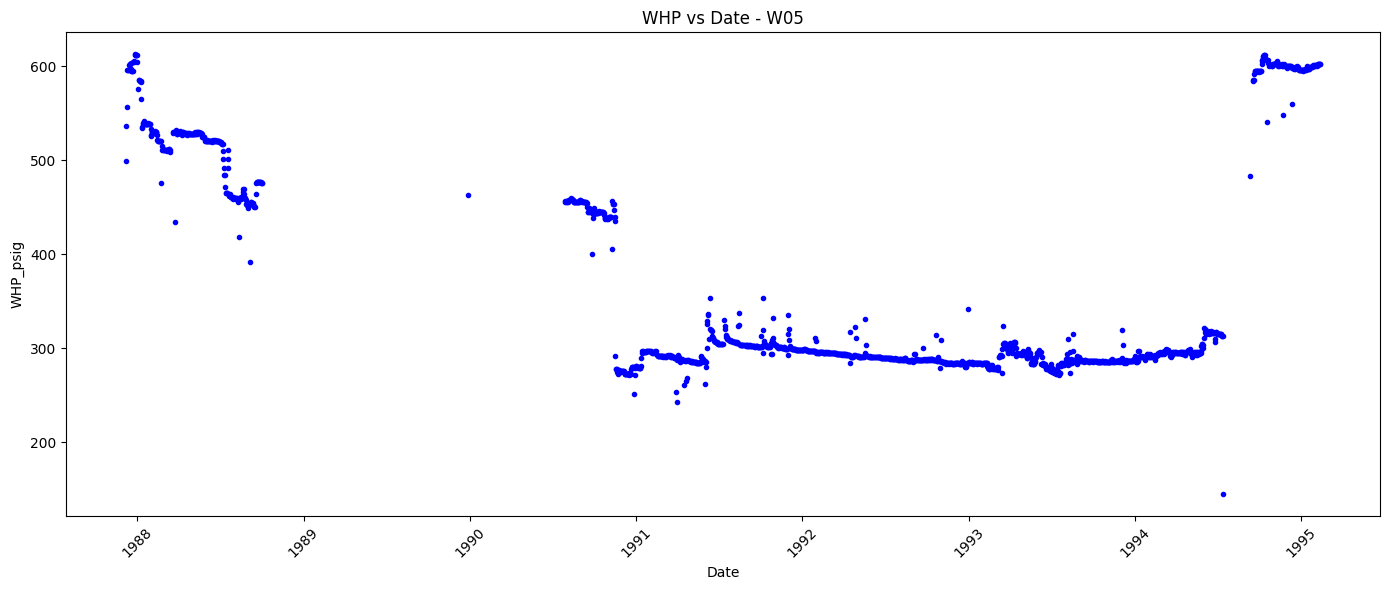

In [ ]:
for well, group in df_no_outliers.groupby("Well"):

    plt.figure()  # ✅ Un solo gráfico por pozo
    plt.figure(figsize=(14, 6))
    plt.scatter(group["Date"], group["WHP_psig"],c='blue', marker='.')

    plt.xlabel("Date")
    plt.ylabel("WHP_psig")
    plt.title(f"WHP vs Date - {well}")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Remove internal outliers due drastic changes in other parameters**

In [ ]:
def remove_spikes(group):
    # Calculate a rolling median of the 5 nearest points
    rolling_median = group["WHP_psig"].rolling(window=5, center=True).median()
    # Calculate the difference from the median
    difference = (group["WHP_psig"] - rolling_median).abs()
    # Standard deviation of the differences
    threshold = 0.5 * difference.std()

    return group[difference < threshold]

df_no_outliers_scondRemoval = df_no_outliers.groupby("Well", group_keys=False).apply(remove_spikes)

/tmp/ipython-input-1053254879.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_no_outliers_scondRemoval = df_no_outliers.groupby("Well", group_keys=False).apply(remove_spikes)


<Figure size 640x480 with 0 Axes>

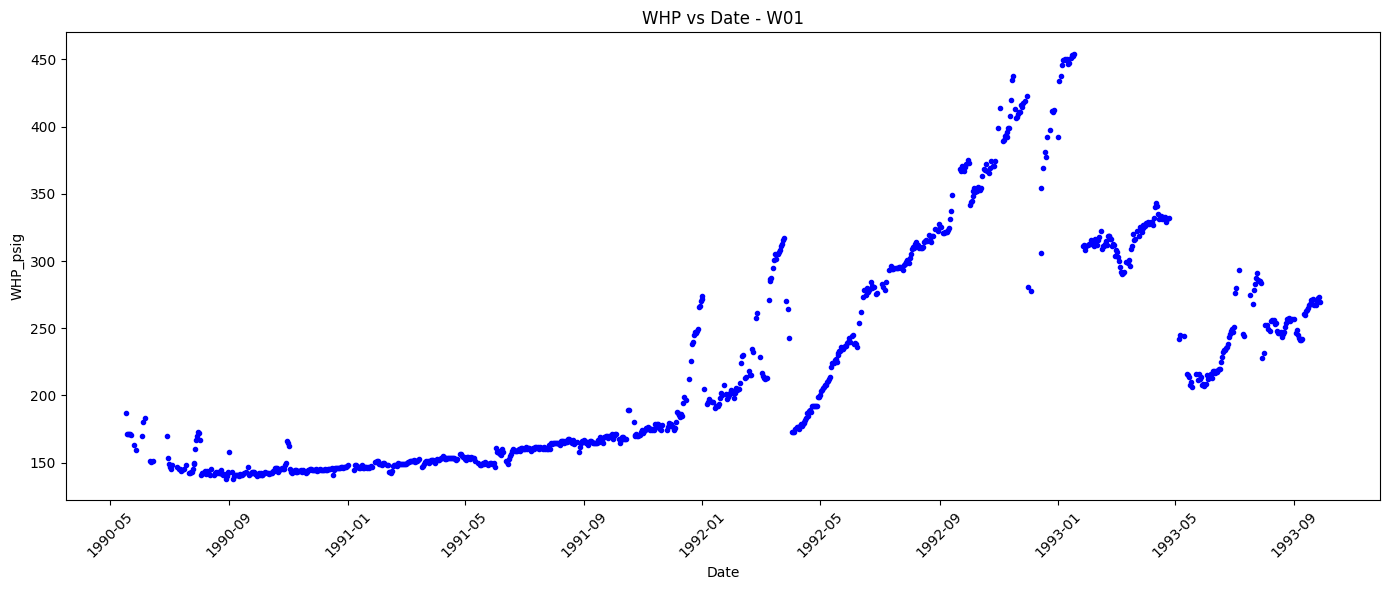

<Figure size 640x480 with 0 Axes>

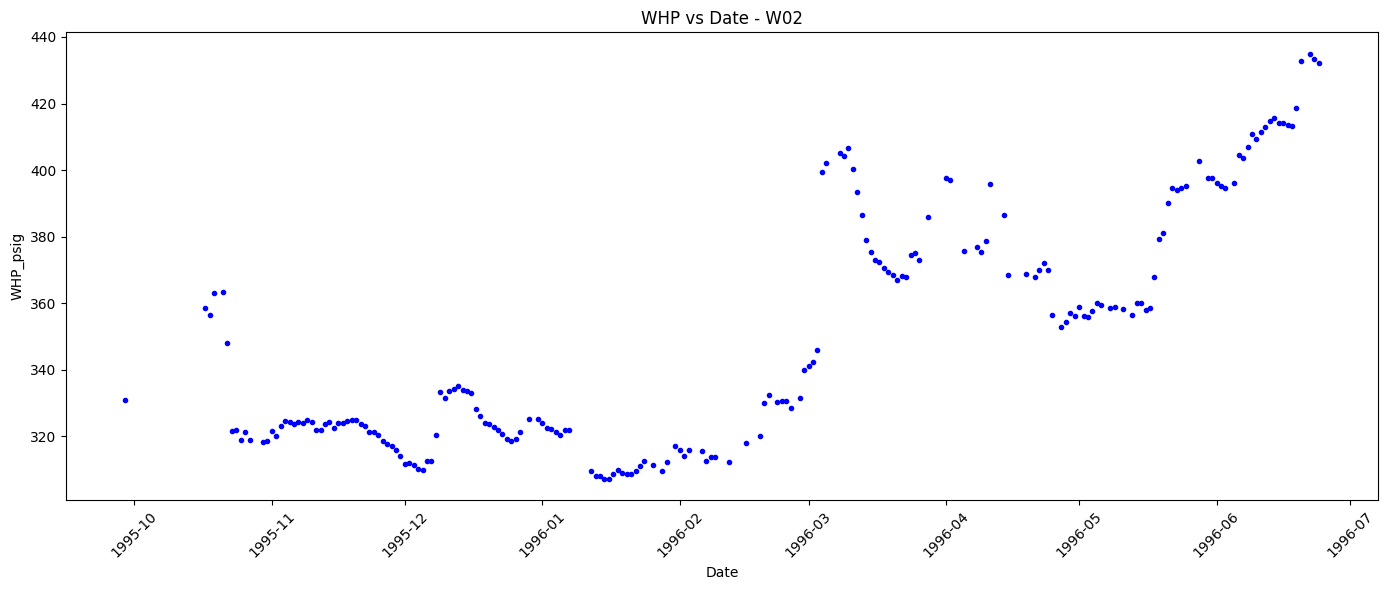

<Figure size 640x480 with 0 Axes>

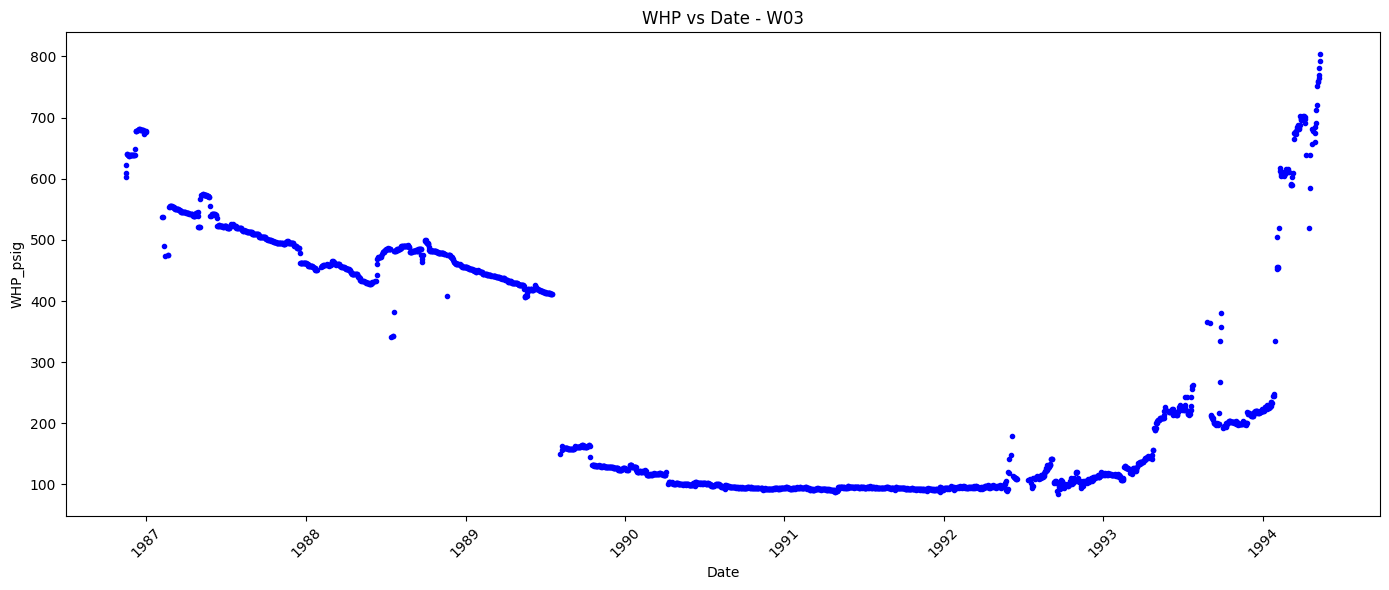

<Figure size 640x480 with 0 Axes>

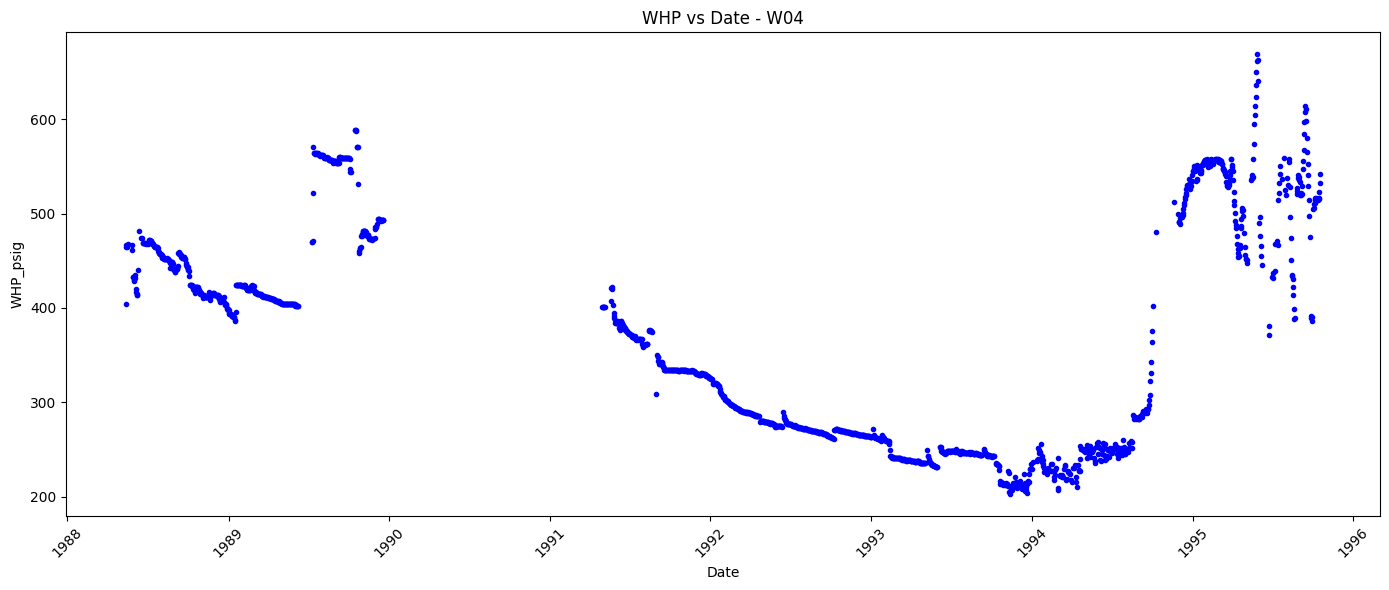

<Figure size 640x480 with 0 Axes>

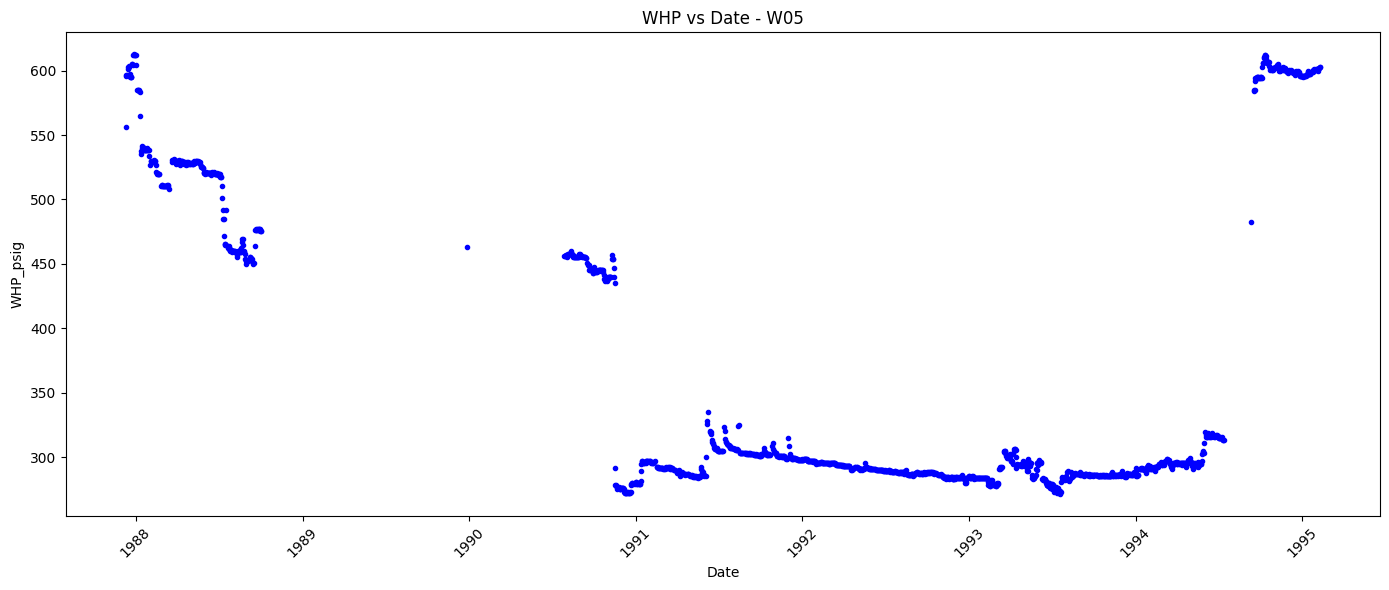

In [ ]:
for well, group in df_no_outliers_scondRemoval.groupby("Well"):

    plt.figure()  # ✅ Un solo gráfico por pozo
    plt.figure(figsize=(14, 6))
    plt.scatter(group["Date"], group["WHP_psig"],c='blue', marker='.')

    plt.xlabel("Date")
    plt.ylabel("WHP_psig")
    plt.title(f"WHP vs Date - {well}")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
df_no_outliers = df_no_outliers_scondRemoval

In [ ]:
corr_list = []

for well, group in df_no_outliers.groupby("Well"):

    # Keep only numeric columns
    df_numeric = group.select_dtypes(include="number")

    # Correlation matrix
    corr_matrix = df_numeric.corr()

    # Add well name as first index level
    corr_matrix["Well"] = well
    corr_matrix = corr_matrix.set_index("Well", append=True)
    corr_matrix = corr_matrix.reorder_levels(["Well", corr_matrix.index.names[0]])

    corr_list.append(corr_matrix)


Correlation matrix for Well: W01
                  Choke  WHP_psig      Rate       BSW      Freq   Pi_psia  \
Well                                                                        
W01  Choke     1.000000 -0.463266  0.901933 -0.439092  0.873869 -0.897431   
     WHP_psig -0.463266  1.000000 -0.321627  0.702306 -0.246453  0.589782   
     Rate      0.901933 -0.321627  1.000000 -0.288698  0.968608 -0.905512   
     BSW      -0.439092  0.702306 -0.288698  1.000000 -0.233547  0.544702   
     Freq      0.873869 -0.246453  0.968608 -0.233547  1.000000 -0.883607   
     Pi_psia  -0.897431  0.589782 -0.905512  0.544702 -0.883607  1.000000   
     Pd_psia   0.411356 -0.727966  0.307128 -0.695548  0.283542 -0.540498   

                Pd_psia  
Well                     
W01  Choke     0.411356  
     WHP_psig -0.727966  
     Rate      0.307128  
     BSW      -0.695548  
     Freq      0.283542  
     Pi_psia  -0.540498  
     Pd_psia   1.000000  


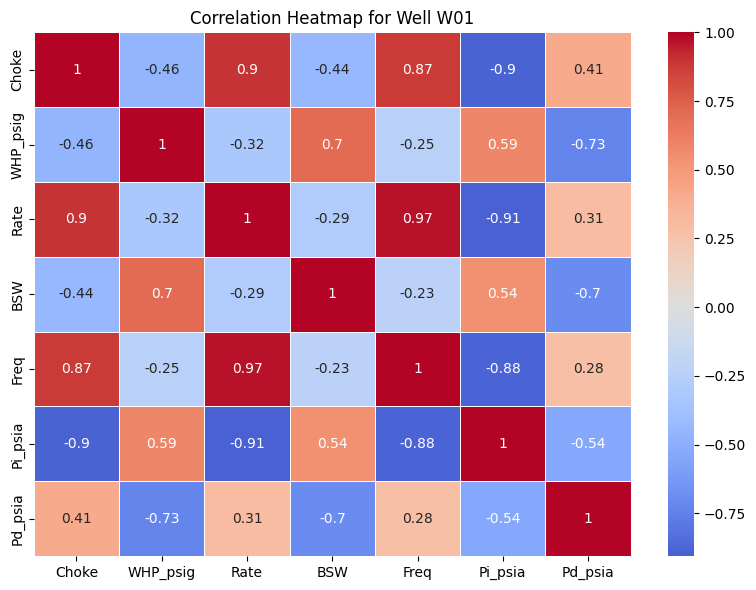


Correlation matrix for Well: W02
                  Choke  WHP_psig      Rate       BSW      Freq   Pi_psia  \
Well                                                                        
W02  Choke     1.000000 -0.027232 -0.105489  0.113766 -0.122636  0.029134   
     WHP_psig -0.027232  1.000000  0.310546 -0.389094  0.853499  0.167609   
     Rate     -0.105489  0.310546  1.000000 -0.216697  0.620668 -0.204816   
     BSW       0.113766 -0.389094 -0.216697  1.000000 -0.363262  0.021106   
     Freq     -0.122636  0.853499  0.620668 -0.363262  1.000000 -0.217358   
     Pi_psia   0.029134  0.167609 -0.204816  0.021106 -0.217358  1.000000   
     Pd_psia  -0.019807  0.979153  0.267675 -0.294455  0.816801  0.229470   

                Pd_psia  
Well                     
W02  Choke    -0.019807  
     WHP_psig  0.979153  
     Rate      0.267675  
     BSW      -0.294455  
     Freq      0.816801  
     Pi_psia   0.229470  
     Pd_psia   1.000000  


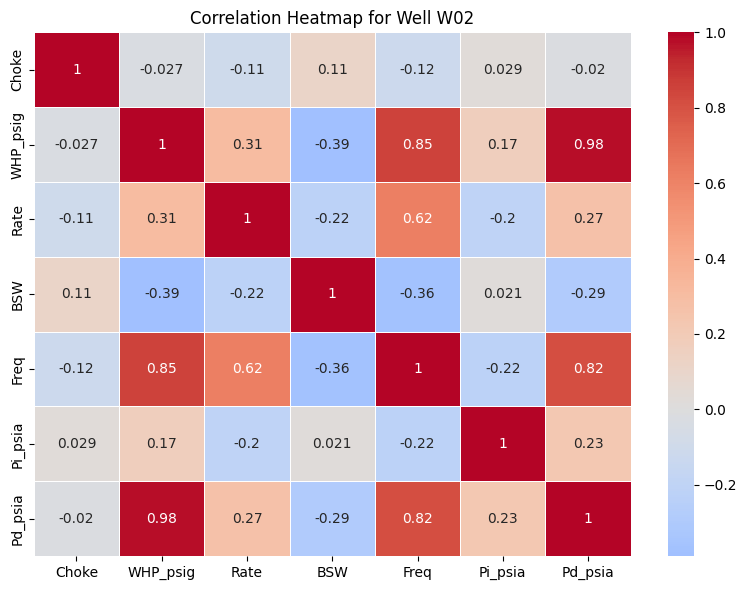


Correlation matrix for Well: W03
                  Choke  WHP_psig      Rate       BSW      Freq   Pi_psia  \
Well                                                                        
W03  Choke     1.000000  0.713222  0.855156 -0.381876  0.318037  0.214828   
     WHP_psig  0.713222  1.000000  0.750113 -0.672155  0.347702  0.740183   
     Rate      0.855156  0.750113  1.000000 -0.554768  0.432384  0.248597   
     BSW      -0.381876 -0.672155 -0.554768  1.000000 -0.331476 -0.464523   
     Freq      0.318037  0.347702  0.432384 -0.331476  1.000000  0.005767   
     Pi_psia   0.214828  0.740183  0.248597 -0.464523  0.005767  1.000000   
     Pd_psia   0.445080  0.785112  0.442065 -0.531005  0.209384  0.595434   

                Pd_psia  
Well                     
W03  Choke     0.445080  
     WHP_psig  0.785112  
     Rate      0.442065  
     BSW      -0.531005  
     Freq      0.209384  
     Pi_psia   0.595434  
     Pd_psia   1.000000  


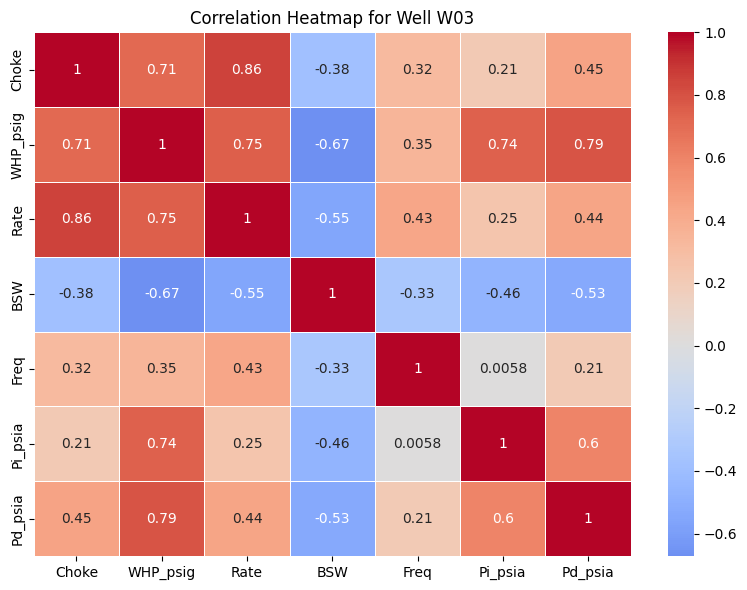


Correlation matrix for Well: W04
                  Choke  WHP_psig      Rate       BSW      Freq   Pi_psia  \
Well                                                                        
W04  Choke     1.000000  0.260901  0.917451 -0.369599  0.473658  0.264744   
     WHP_psig  0.260901  1.000000  0.441592 -0.652261  0.734620  0.836677   
     Rate      0.917451  0.441592  1.000000 -0.512993  0.621171  0.369141   
     BSW      -0.369599 -0.652261 -0.512993  1.000000 -0.300491 -0.382115   
     Freq      0.473658  0.734620  0.621171 -0.300491  1.000000  0.636865   
     Pi_psia   0.264744  0.836677  0.369141 -0.382115  0.636865  1.000000   
     Pd_psia  -0.197675  0.565676 -0.080478  0.149088  0.626808  0.679650   

                Pd_psia  
Well                     
W04  Choke    -0.197675  
     WHP_psig  0.565676  
     Rate     -0.080478  
     BSW       0.149088  
     Freq      0.626808  
     Pi_psia   0.679650  
     Pd_psia   1.000000  


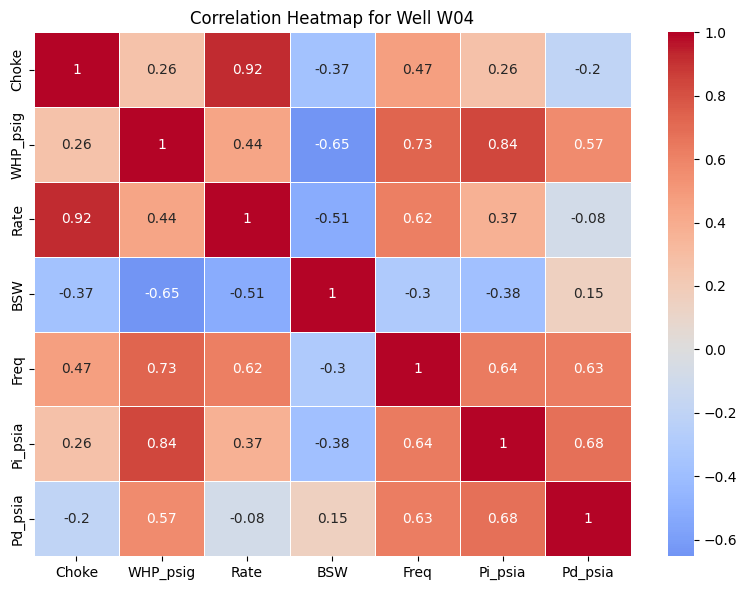


Correlation matrix for Well: W05
                  Choke  WHP_psig      Rate       BSW      Freq   Pi_psia  \
Well                                                                        
W05  Choke     1.000000 -0.558362  0.335007  0.179102  0.054514 -0.746902   
     WHP_psig -0.558362  1.000000  0.551184 -0.687912  0.483085  0.731009   
     Rate      0.335007  0.551184  1.000000 -0.491838  0.597314  0.030045   
     BSW       0.179102 -0.687912 -0.491838  1.000000 -0.397661 -0.303737   
     Freq      0.054514  0.483085  0.597314 -0.397661  1.000000  0.132102   
     Pi_psia  -0.746902  0.731009  0.030045 -0.303737  0.132102  1.000000   
     Pd_psia  -0.412664  0.970421  0.679507 -0.593147  0.540582  0.664367   

                Pd_psia  
Well                     
W05  Choke    -0.412664  
     WHP_psig  0.970421  
     Rate      0.679507  
     BSW      -0.593147  
     Freq      0.540582  
     Pi_psia   0.664367  
     Pd_psia   1.000000  


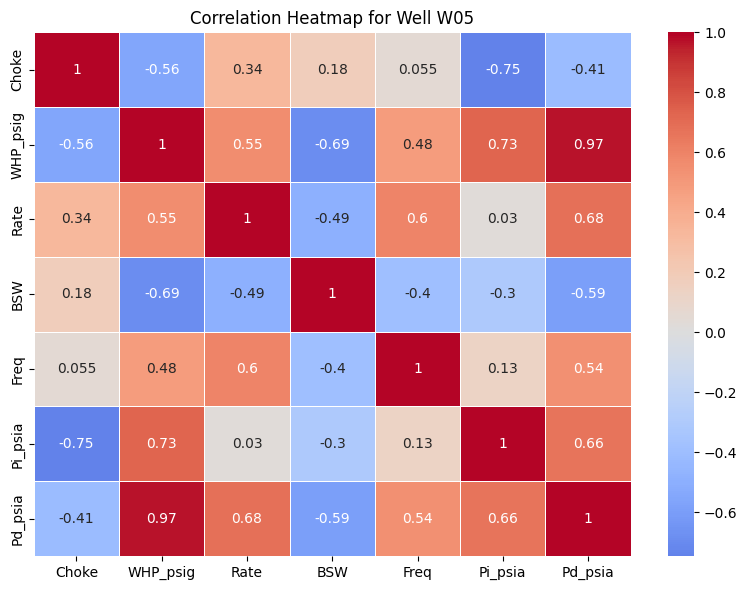

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_list = []

for well, group in df_no_outliers.groupby("Well"):
    # Keep only numeric columns
    df_numeric = group.select_dtypes(include="number")

    # Correlation matrix
    corr_matrix = df_numeric.corr()

    # Add well name as first index level
    corr_matrix["Well"] = well
    corr_matrix = corr_matrix.set_index("Well", append=True)
    corr_matrix = corr_matrix.reorder_levels(["Well", corr_matrix.index.names[0]])

    corr_list.append(corr_matrix)

    # --- Print correlation matrix ---
    print(f"\nCorrelation matrix for Well: {well}")
    print(corr_matrix)

    # --- Plot heatmap ---
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_numeric.corr(),
                annot=True,        # show correlation values
                cmap="coolwarm",   # red-blue color map
                center=0,          # center colors at 0
                linewidths=0.5)    # grid lines between cells
    plt.title(f"Correlation Heatmap for Well {well}")
    plt.tight_layout()
    plt.show()

In [ ]:
# ✅ Final combined correlation DataFrame
corr_df = pd.concat(corr_list)
corr_df

Choke  WHP_psig      Rate       BSW      Freq   Pi_psia  \
Well                                                                        
W01  Choke     1.000000 -0.463266  0.901933 -0.439092  0.873869 -0.897431   
     WHP_psig -0.463266  1.000000 -0.321627  0.702306 -0.246453  0.589782   
     Rate      0.901933 -0.321627  1.000000 -0.288698  0.968608 -0.905512   
     BSW      -0.439092  0.702306 -0.288698  1.000000 -0.233547  0.544702   
     Freq      0.873869 -0.246453  0.968608 -0.233547  1.000000 -0.883607   
     Pi_psia  -0.897431  0.589782 -0.905512  0.544702 -0.883607  1.000000   
     Pd_psia   0.411356 -0.727966  0.307128 -0.695548  0.283542 -0.540498   
W02  Choke     1.000000 -0.027232 -0.105489  0.113766 -0.122636  0.029134   
     WHP_psig -0.027232  1.000000  0.310546 -0.389094  0.853499  0.167609   
     Rate     -0.105489  0.310546  1.000000 -0.216697  0.620668 -0.204816   
     BSW       0.113766 -0.389094 -0.216697  1.000000 -0.363262  0.021106   
     Freq     -0.122636  0.853499  0.620668 -0.363262  1.000000 -0.217358   
     Pi_psia   0.029134  0.167609 -0.204816  0.021106 -0.217358  1.000000   
     Pd_psia  -0.019807  0.979153  0.267675 -0.294455  0.816801  0.229470   
W03  Choke     1.000000  0.713222  0.855156 -0.381876  0.318037  0.214828   
     WHP_psig  0.713222  1.000000  0.750113 -0.672155  0.347702  0.740183   
     Rate      0.855156  0.750113  1.000000 -0.554768  0.432384  0.248597   
     BSW      -0.381876 -0.672155 -0.554768  1.000000 -0.331476 -0.464523   
     Freq      0.318037  0.347702  0.432384 -0.331476  1.000000  0.005767   
     Pi_psia   0.214828  0.740183  0.248597 -0.464523  0.005767  1.000000   
     Pd_psia   0.445080  0.785112  0.442065 -0.531005  0.209384  0.595434   
W04  Choke     1.000000  0.260901  0.917451 -0.369599  0.473658  0.264744   
     WHP_psig  0.260901  1.000000  0.441592 -0.652261  0.734620  0.836677   
     Rate      0.917451  0.441592  1.000000 -0.512993  0.621171  0.369141   
     BSW      -0.369599 -0.652261 -0.512993  1.000000 -0.300491 -0.382115   
     Freq      0.473658  0.734620  0.621171 -0.300491  1.000000  0.636865   
     Pi_psia   0.264744  0.836677  0.369141 -0.382115  0.636865  1.000000   
     Pd_psia  -0.197675  0.565676 -0.080478  0.149088  0.626808  0.679650   
W05  Choke     1.000000 -0.558362  0.335007  0.179102  0.054514 -0.746902   
     WHP_psig -0.558362  1.000000  0.551184 -0.687912  0.483085  0.731009   
     Rate      0.335007  0.551184  1.000000 -0.491838  0.597314  0.030045   
     BSW       0.179102 -0.687912 -0.491838  1.000000 -0.397661 -0.303737   
     Freq      0.054514  0.483085  0.597314 -0.397661  1.000000  0.132102   
     Pi_psia  -0.746902  0.731009  0.030045 -0.303737  0.132102  1.000000   
     Pd_psia  -0.412664  0.970421  0.679507 -0.593147  0.540582  0.664367   

                Pd_psia  
Well                     
W01  Choke     0.411356  
     WHP_psig -0.727966  
     Rate      0.307128  
     BSW      -0.695548  
     Freq      0.283542  
     Pi_psia  -0.540498  
     Pd_psia   1.000000  
W02  Choke    -0.019807  
     WHP_psig  0.979153  
     Rate      0.267675  
     BSW      -0.294455  
     Freq      0.816801  
     Pi_psia   0.229470  
     Pd_psia   1.000000  
W03  Choke     0.445080  
     WHP_psig  0.785112  
     Rate      0.442065  
     BSW      -0.531005  
     Freq      0.209384  
     Pi_psia   0.595434  
     Pd_psia   1.000000  
W04  Choke    -0.197675  
     WHP_psig  0.565676  
     Rate     -0.080478  
     BSW       0.149088  
     Freq      0.626808  
     Pi_psia   0.679650  
     Pd_psia   1.000000  
W05  Choke    -0.412664  
     WHP_psig  0.970421  
     Rate      0.679507  
     BSW      -0.593147  
     Freq      0.540582  
     Pi_psia   0.664367  
     Pd_psia   1.000000

In [ ]:
df = df_no_outliers

## ***Linear Model***


===== W01 LINEAR REGRESSION MODEL =====
R²: -21.9562, Adj R²: -22.3813
MAE: 181.19, MSE: 36613.76, RMSE: 191.35
MAPE: 72.11 %, SMAPE: 50.92 %



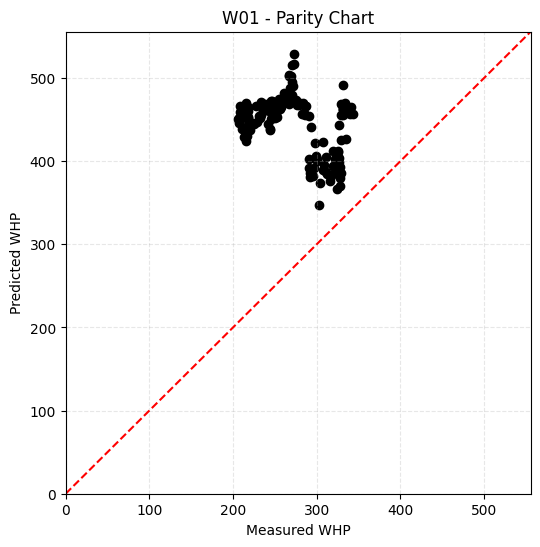

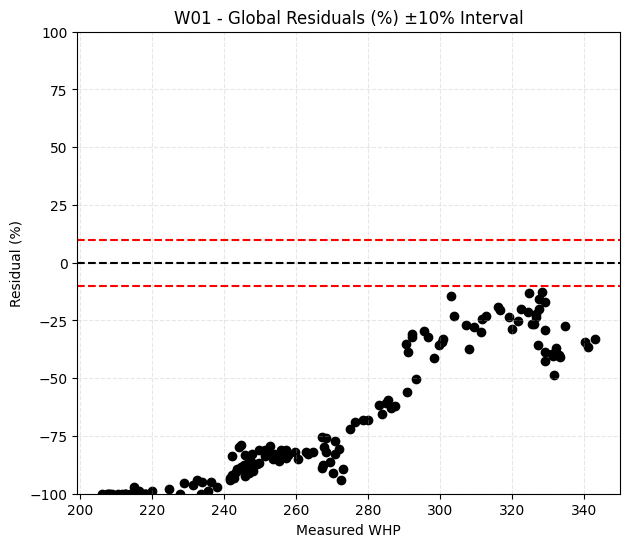

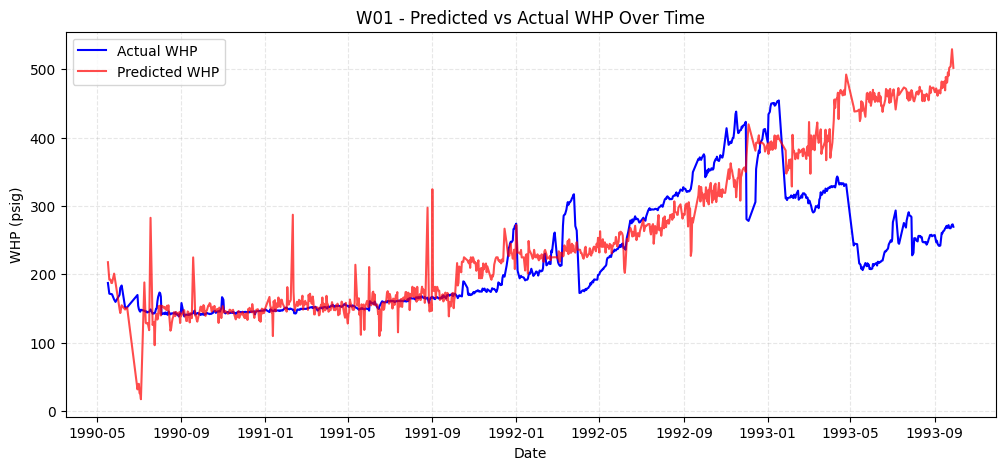


===== W02 LINEAR REGRESSION MODEL =====
R²: 0.7613, Adj R²: 0.7459
MAE: 7.96, MSE: 69.89, RMSE: 8.36
MAPE: 1.96 %, SMAPE: 1.99 %



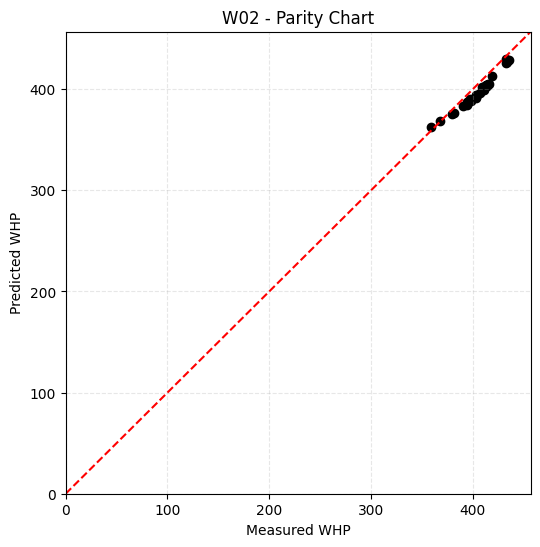

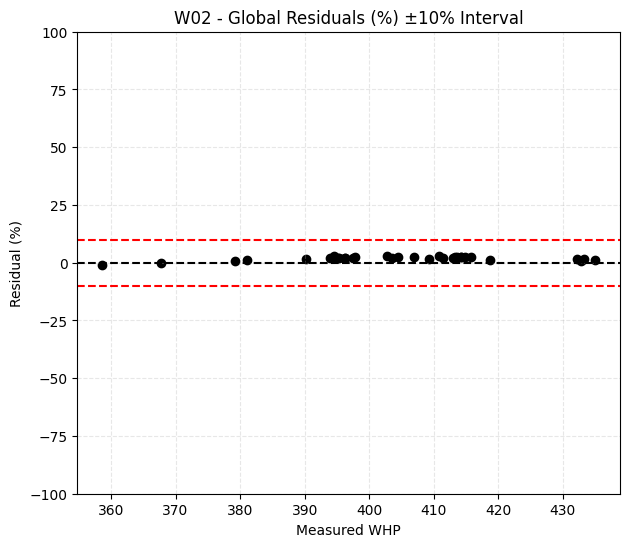

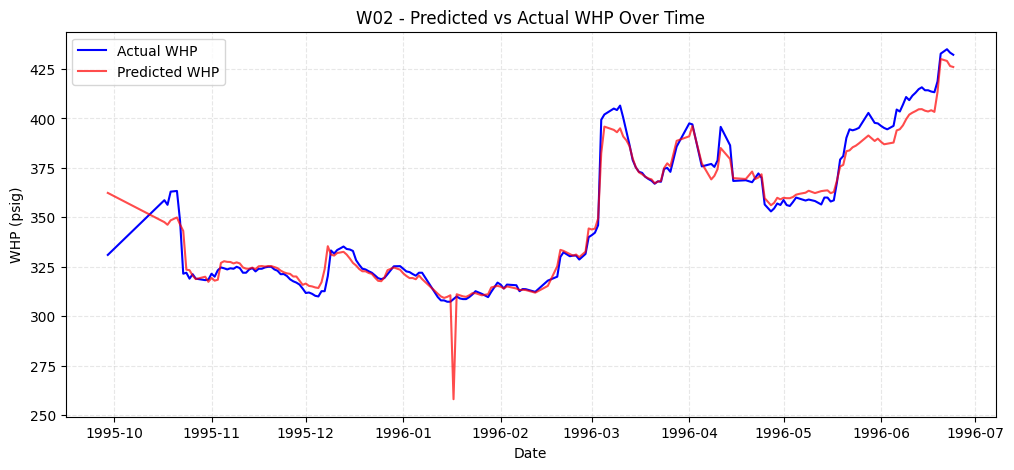


===== W03 LINEAR REGRESSION MODEL =====
R²: 0.8789, Adj R²: 0.8773
MAE: 50.37, MSE: 4583.28, RMSE: 67.70
MAPE: 20.83 %, SMAPE: 20.90 %



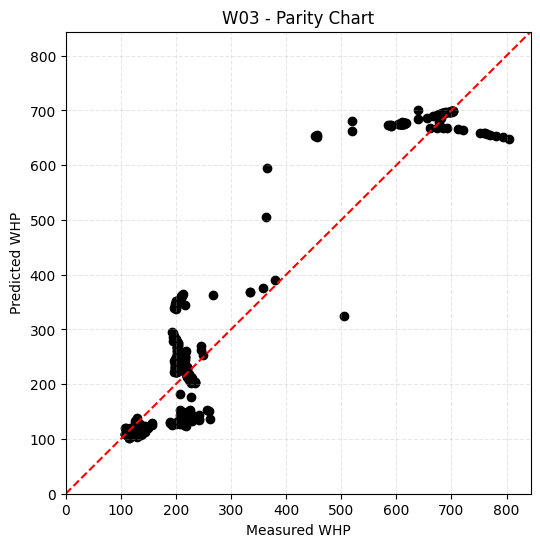

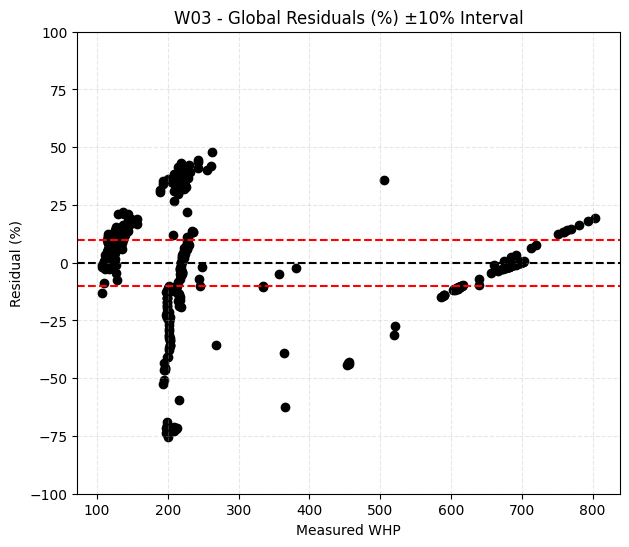

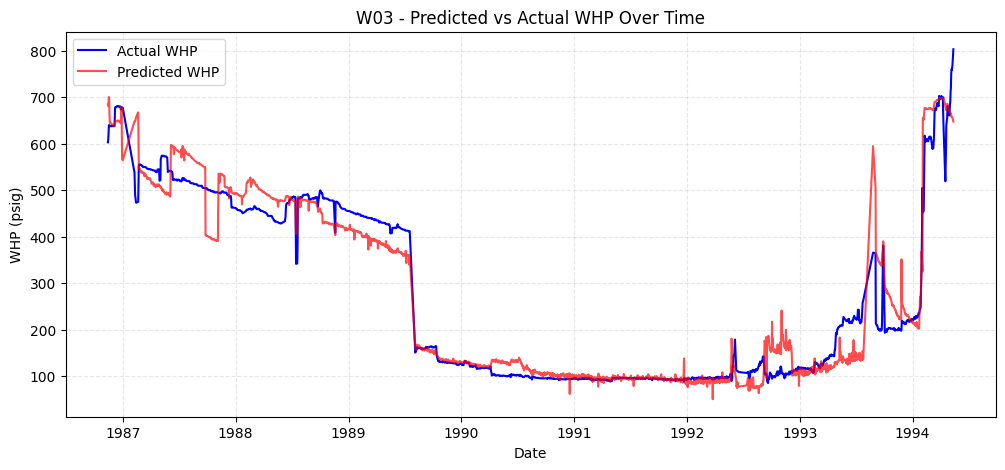


===== W04 LINEAR REGRESSION MODEL =====
R²: -0.2329, Adj R²: -0.2492
MAE: 97.33, MSE: 11288.60, RMSE: 106.25
MAPE: 19.19 %, SMAPE: 21.51 %



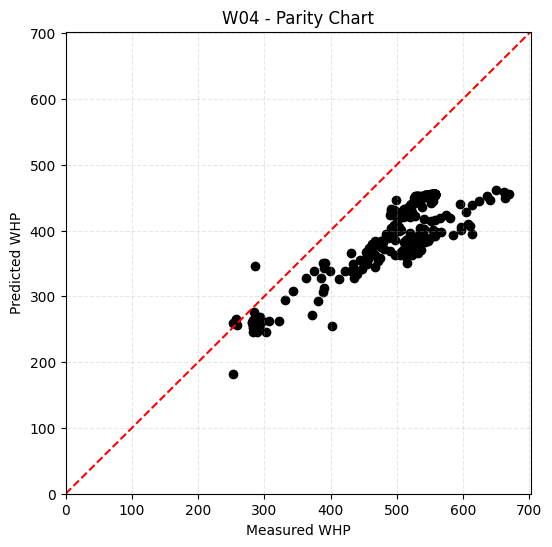

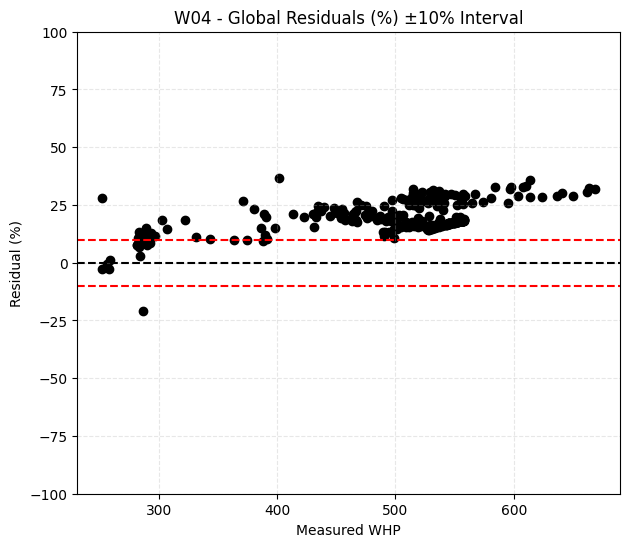

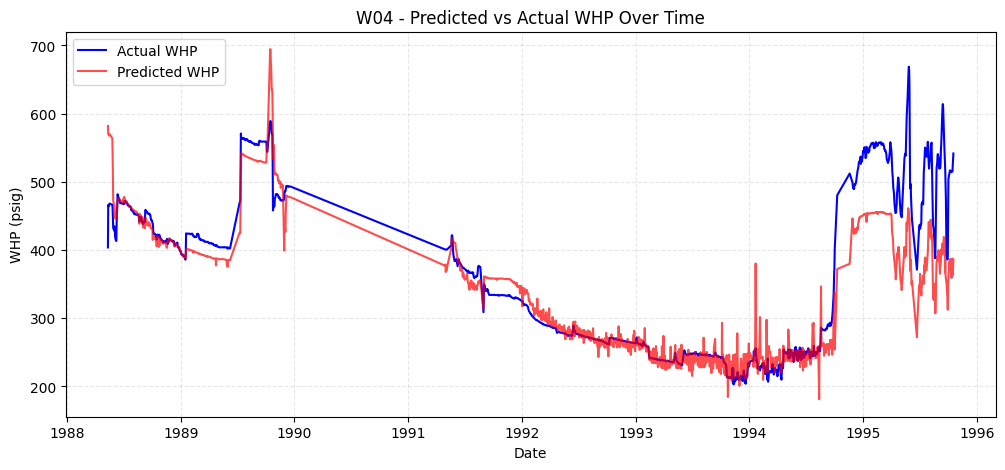


===== W05 LINEAR REGRESSION MODEL =====
R²: 0.8645, Adj R²: 0.8631
MAE: 41.38, MSE: 3016.01, RMSE: 54.92
MAPE: 7.33 %, SMAPE: 7.77 %



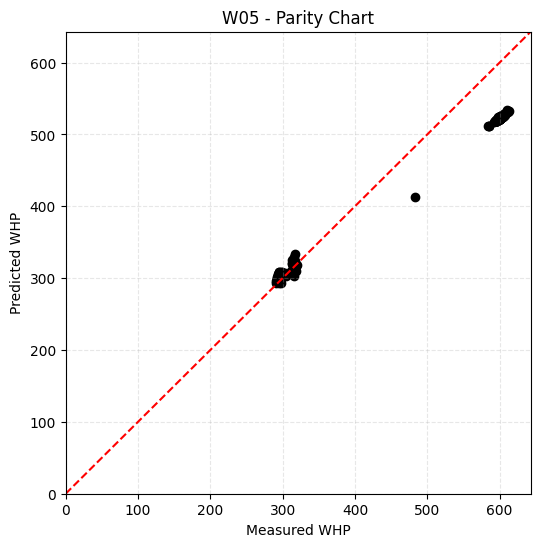

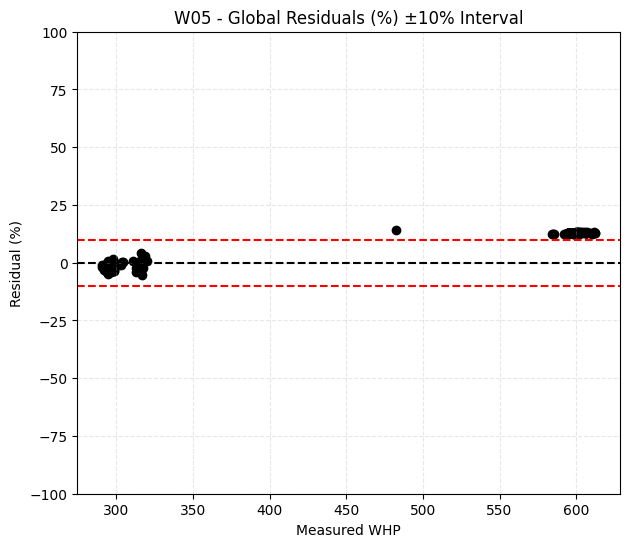

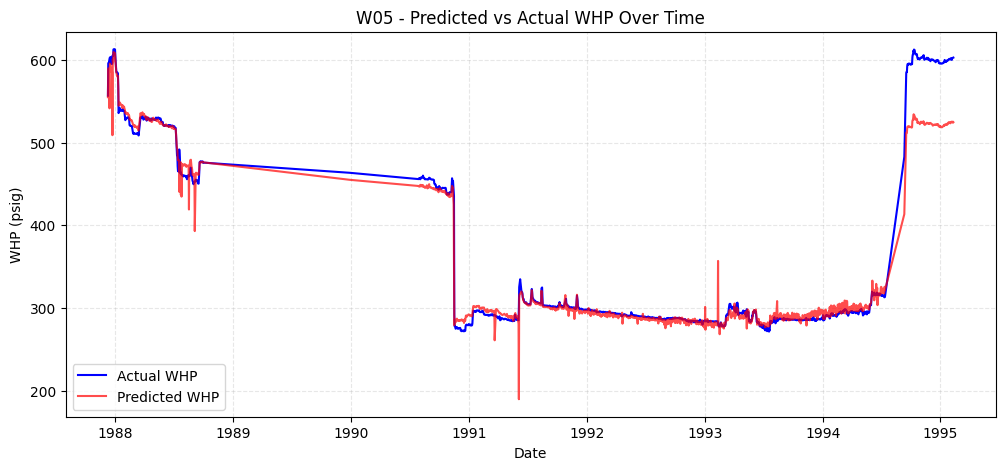

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ==============================
# CONFIG
# ==============================

well_features = {
    "W01": ["BSW", "Pd_psia","Pi_psia"],
    "W02": ["Freq", "Pd_psia"],
    "W03": ["Choke", "Rate", "BSW", "Pi_psia", "Pd_psia"],
    "W04": ["BSW", "Freq", "Pi_psia", "Pd_psia"],
    "W05": ["BSW", "Pd_psia","Pi_psia"]
}

target = "WHP_psig"
df["Date"] = pd.to_datetime(df["Date"])

metrics_list = []


# ==============================
# METRIC FUNCTIONS
# ==============================

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )


# ==============================
# LOOP OVER EACH WELL
# ==============================

for well, group in df.groupby("Well"):

    if well not in well_features:
        continue

    feature_cols = well_features[well]
    p = len(feature_cols)

    # ===== Sort by Date =====
    group = group.sort_values("Date").reset_index(drop=True)

    # ===== Remove NaNs =====
    required_cols = feature_cols + [target]
    group = group.dropna(subset=required_cols)

    if len(group) < 40:
        print(f"Skipping {well}: Not enough data.")
        continue

    X = group[feature_cols]
    y = group[target]

    # ==============================
    # TIME SERIES SPLIT (LAST FOLD)
    # ==============================

    tscv = TimeSeriesSplit(n_splits=5)

    for train_idx, test_idx in tscv.split(X):
        pass  # use last fold as final test

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ==============================
    # FIT LINEAR REGRESSION
    # ==============================
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # ==============================
    # FINAL METRICS
    # ==============================
    n_final = len(y_test)

    r2_final = r2_score(y_test, y_pred)
    adjr2_final = adjusted_r2(r2_final, n_final, p)
    mae_final = mean_absolute_error(y_test, y_pred)
    mse_final = mean_squared_error(y_test, y_pred)
    rmse_final = np.sqrt(mse_final)
    mape_final = mape(y_test, y_pred)
    smape_final = smape(y_test, y_pred)

    metrics_list.append({
        "Well": well,
        "Model": "Linear Regression",
        "R2_Final": r2_final,
        "Adj_R2_Final": adjr2_final,
        "MAE_Final": mae_final,
        "MSE_Final": mse_final,
        "RMSE_Final": rmse_final,
        "MAPE_Final_%": mape_final,
        "SMAPE_Final_%": smape_final
    })

    print(f"\n===== {well} LINEAR REGRESSION MODEL =====")
    print(f"R²: {r2_final:.4f}, Adj R²: {adjr2_final:.4f}")
    print(f"MAE: {mae_final:.2f}, MSE: {mse_final:.2f}, RMSE: {rmse_final:.2f}")
    print(f"MAPE: {mape_final:.2f} %, SMAPE: {smape_final:.2f} %")
    print()

    # ==============================
    # PARITY PLOT (Dynamic Axes)
    # ==============================
    max_val = max(y_test.max(), y_pred.max()) * 1.05
    plt.figure(figsize=(6,6))
    plt.scatter(y_test.values, y_pred, color='black')
    plt.plot([0, max_val], [0, max_val], '--', color='red')
    plt.xlabel("Measured WHP")
    plt.ylabel("Predicted WHP")
    plt.title(f"{well} - Parity Chart")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # GLOBAL RESIDUALS IN % (Capped ±100%)
    # ==============================
    residuals_pct = 100 * (y_test.values - y_pred) / y_test.values
    residuals_pct = np.clip(residuals_pct, -100, 100)

    plt.figure(figsize=(7,6))
    plt.scatter(y_test.values, residuals_pct, color='black')
    plt.axhline(0, linestyle="--", color="black")
    plt.axhline(10, linestyle="--", color="red")   # +10%
    plt.axhline(-10, linestyle="--", color="red")  # -10%
    plt.xlabel("Measured WHP")
    plt.ylabel("Residual (%)")
    plt.title(f"{well} - Global Residuals (%) ±10% Interval")
    plt.ylim(-100, 100)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # PREDICTION VS ACTUAL OVER TIME
    # ==============================
    full_pred = model.predict(X)

    plt.figure(figsize=(12,5))
    plt.plot(group["Date"], y, label="Actual WHP", color="blue")
    plt.plot(group["Date"], full_pred, label="Predicted WHP", color="red", alpha=0.7)
    plt.xlabel("Date")
    plt.ylabel("WHP (psig)")
    plt.title(f"{well} - Predicted vs Actual WHP Over Time")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


In [ ]:
metrics_df

NameError: name 'metrics_df' is not defined

**RF model**


✅ W01 Best RF Params: {'max_depth': None, 'n_estimators': 400}

===== W01 RANDOM FOREST MODEL =====
R²: -7.1545, Adj R²: -7.2546
MAE: 98.44, MSE: 13005.95, RMSE: 114.04
MAPE: 40.33 %, SMAPE: 31.67 %



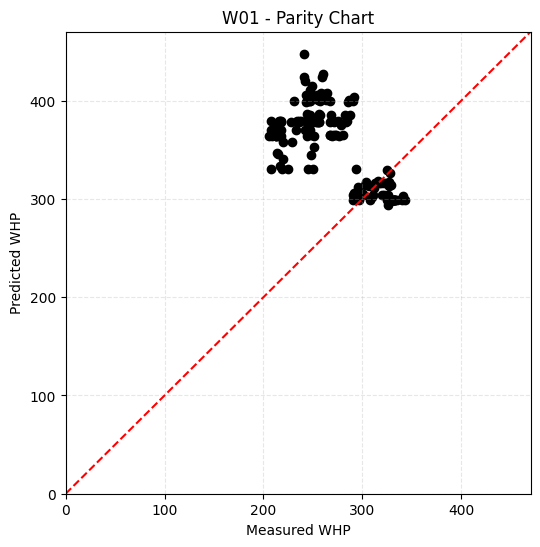

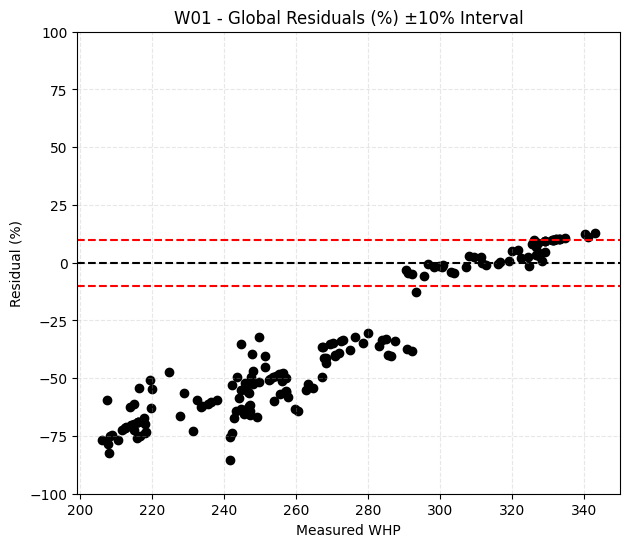

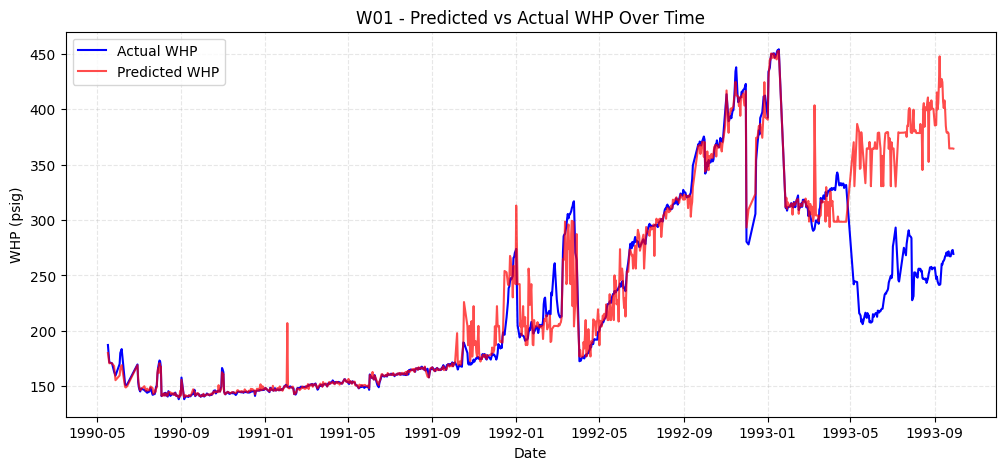


✅ W02 Best RF Params: {'max_depth': 6, 'n_estimators': 400}

===== W02 RANDOM FOREST MODEL =====
R²: 0.1858, Adj R²: 0.1332
MAE: 12.02, MSE: 238.44, RMSE: 15.44
MAPE: 2.89 %, SMAPE: 2.96 %



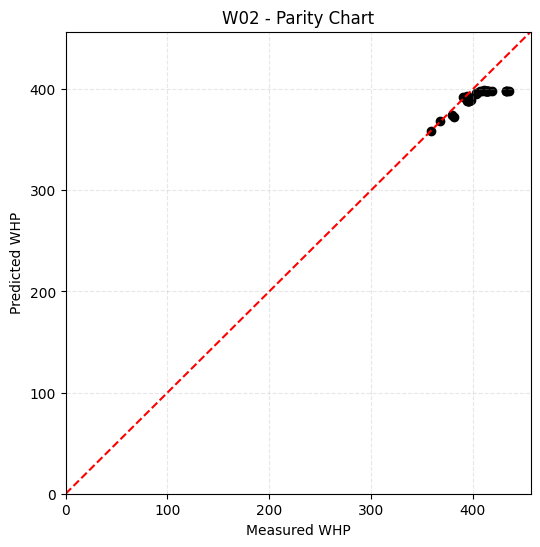

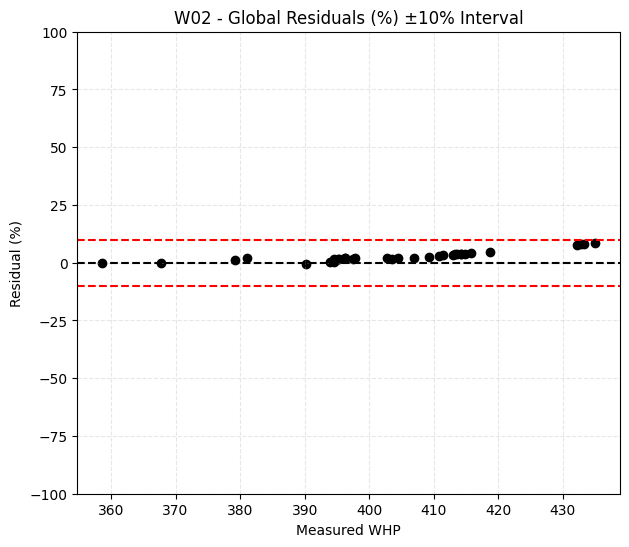

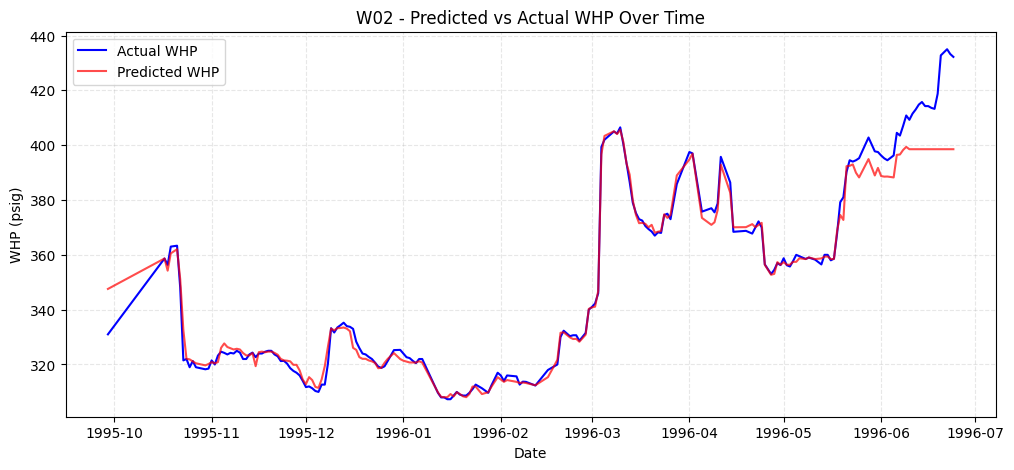


✅ W03 Best RF Params: {'max_depth': 10, 'n_estimators': 400}

===== W03 RANDOM FOREST MODEL =====
R²: 0.5563, Adj R²: 0.5505
MAE: 88.05, MSE: 16796.86, RMSE: 129.60
MAPE: 37.57 %, SMAPE: 36.22 %



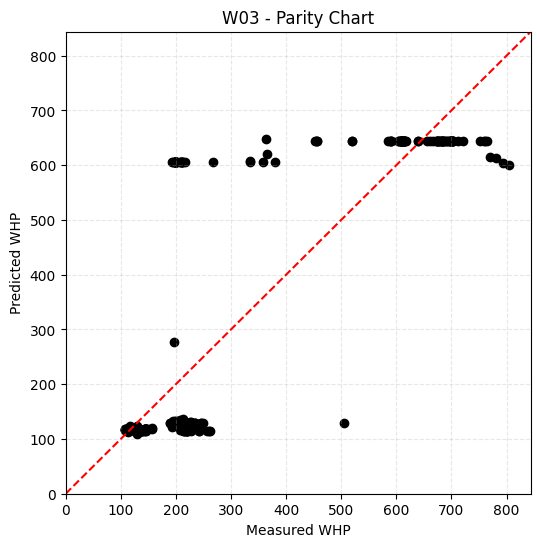

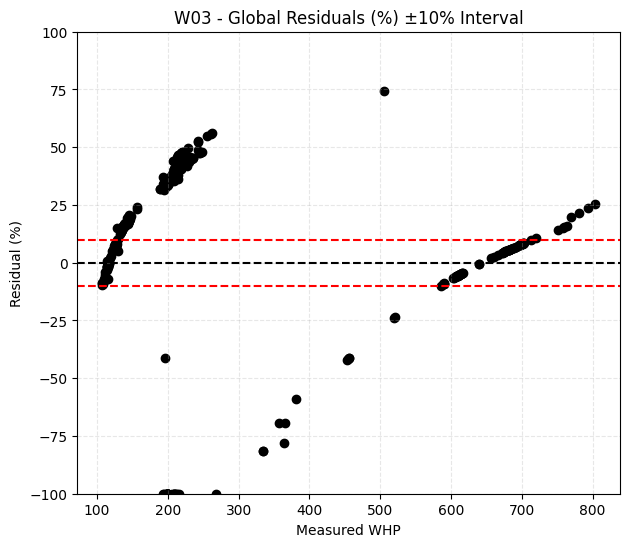

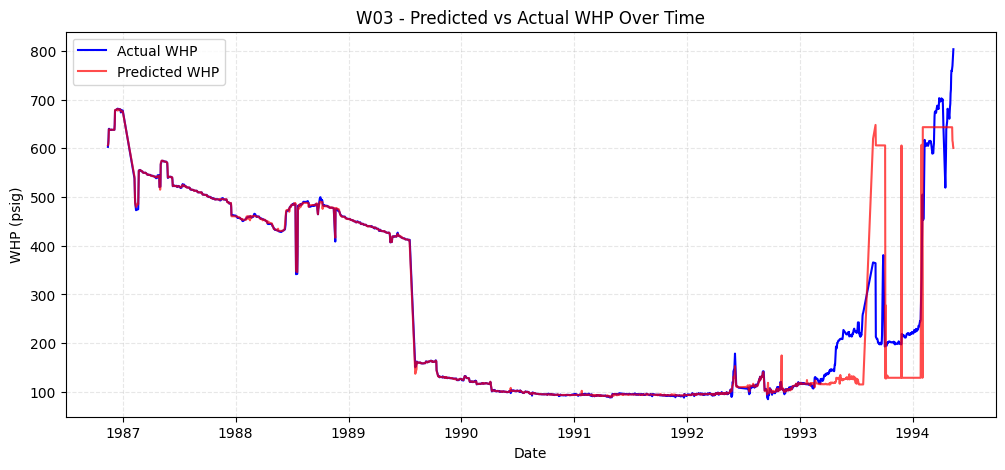


✅ W04 Best RF Params: {'max_depth': 4, 'n_estimators': 200}

===== W04 RANDOM FOREST MODEL =====
R²: 0.1052, Adj R²: 0.0934
MAE: 75.15, MSE: 8192.69, RMSE: 90.51
MAPE: 16.13 %, SMAPE: 17.75 %



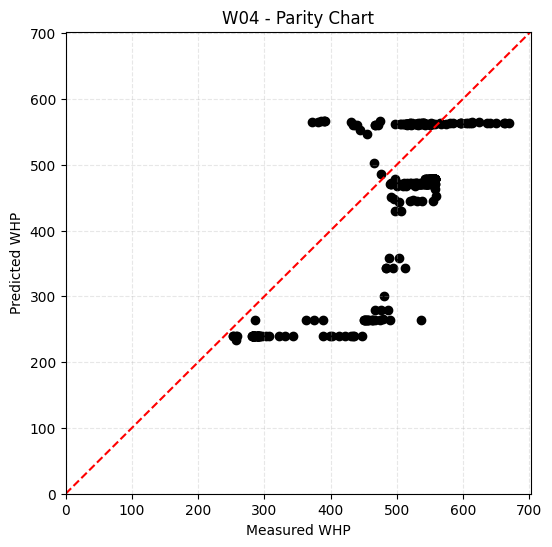

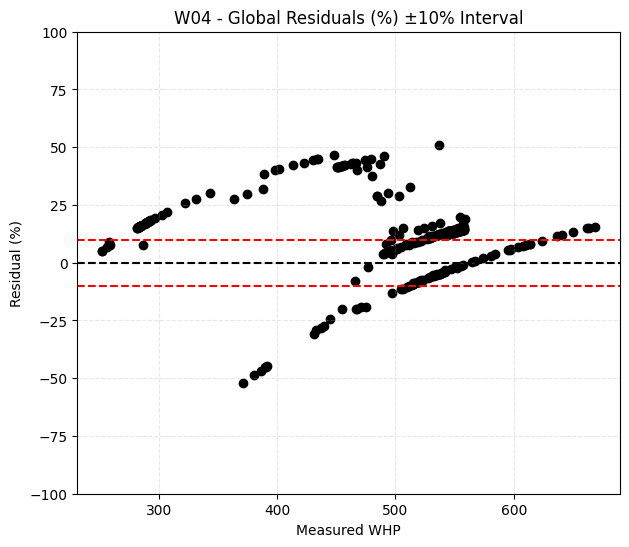

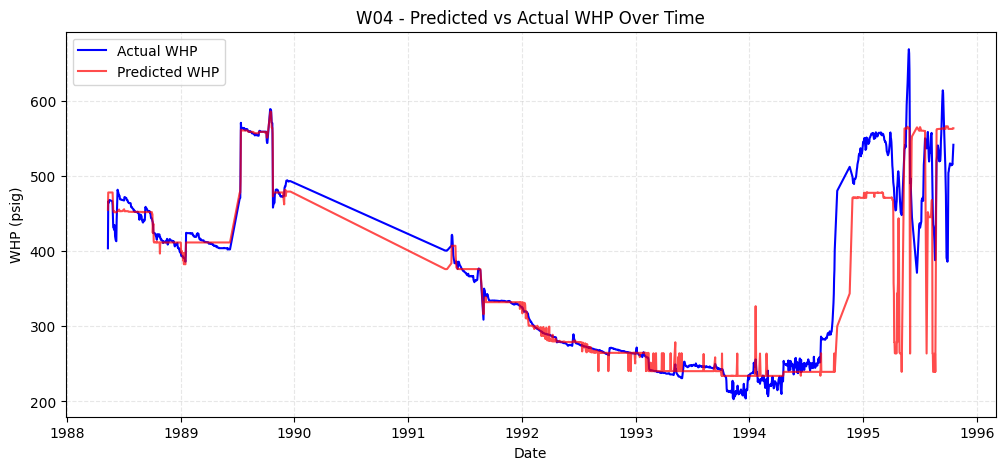


✅ W05 Best RF Params: {'max_depth': None, 'n_estimators': 200}

===== W05 RANDOM FOREST MODEL =====
R²: 0.8193, Adj R²: 0.8180
MAE: 49.36, MSE: 4023.55, RMSE: 63.43
MAPE: 9.02 %, SMAPE: 9.56 %



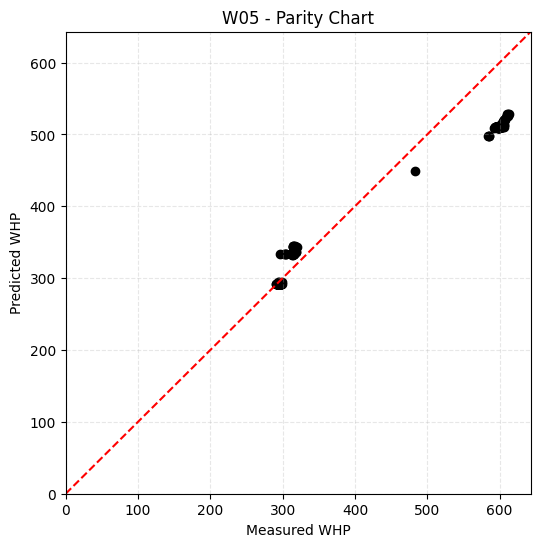

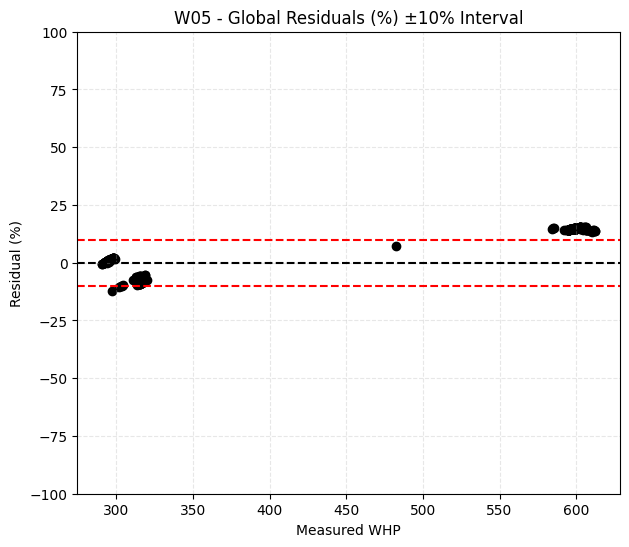

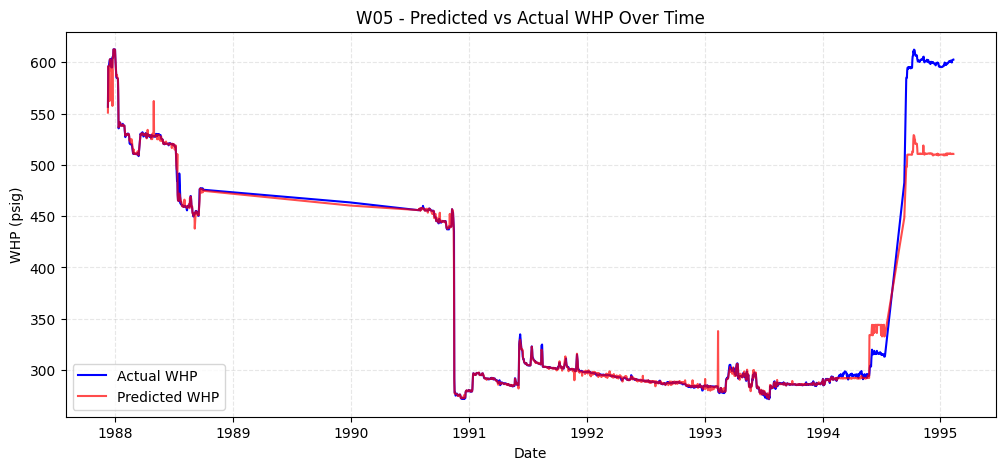

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ==============================
# CONFIG
# ==============================

well_features = {
    "W01": ["BSW", "Pd_psia"],
    "W02": ["Freq", "Pd_psia"],
    "W03": ["Choke", "Rate", "BSW", "Pi_psia", "Pd_psia"],
    "W04": ["BSW", "Freq", "Pi_psia", "Pd_psia"],
    "W05": ["BSW", "Pd_psia"]
}

target = "WHP_psig"
df["Date"] = pd.to_datetime(df["Date"])

metrics_list = []


# ==============================
# METRIC FUNCTIONS
# ==============================

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )


# ==============================
# RANDOM FOREST SEARCH SPACE
# ==============================

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 10, None]
}


# ==============================
# LOOP OVER EACH WELL
# ==============================

for well, group in df.groupby("Well"):

    if well not in well_features:
        continue

    feature_cols = well_features[well]
    p = len(feature_cols)

    # ===== Sort by Date =====
    group = group.sort_values("Date").reset_index(drop=True)

    # ===== Remove NaNs =====
    required_cols = feature_cols + [target]
    group = group.dropna(subset=required_cols)

    if len(group) < 40:
        print(f"Skipping {well}: Not enough data.")
        continue

    X = group[feature_cols]
    y = group[target]

    # ==============================
    # TIME SERIES CROSS VALIDATION
    # ==============================

    tscv = TimeSeriesSplit(n_splits=5)

    rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        rf_base,
        param_grid,
        cv=tscv,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X, y)
    best_params = grid.best_params_
    print(f"\n✅ {well} Best RF Params:", best_params)

    # ==============================
    # FINAL TIME SPLIT (LAST FOLD)
    # ==============================

    for train_idx, test_idx in tscv.split(X):
        pass  # last fold

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)

    # ==============================
    # FINAL METRICS
    # ==============================

    n_final = len(y_test)

    r2_final = r2_score(y_test, y_pred)
    adjr2_final = adjusted_r2(r2_final, n_final, p)
    mae_final = mean_absolute_error(y_test, y_pred)
    mse_final = mean_squared_error(y_test, y_pred)
    rmse_final = np.sqrt(mse_final)
    mape_final = mape(y_test, y_pred)
    smape_final = smape(y_test, y_pred)

    metrics_list.append({
        "Well": well,
        "Model": "Random Forest",
        "R2_Final": r2_final,
        "Adj_R2_Final": adjr2_final,
        "MAE_Final": mae_final,
        "MSE_Final": mse_final,
        "RMSE_Final": rmse_final,
        "MAPE_Final_%": mape_final,
        "SMAPE_Final_%": smape_final
    })

    print(f"\n===== {well} RANDOM FOREST MODEL =====")
    print(f"R²: {r2_final:.4f}, Adj R²: {adjr2_final:.4f}")
    print(f"MAE: {mae_final:.2f}, MSE: {mse_final:.2f}, RMSE: {rmse_final:.2f}")
    print(f"MAPE: {mape_final:.2f} %, SMAPE: {smape_final:.2f} %")
    print()

    # ==============================
    # PARITY PLOT (Dynamic Axes)
    # ==============================
    max_val = max(y_test.max(), y_pred.max()) * 1.05  # 5% margin
    plt.figure(figsize=(6,6))
    plt.scatter(y_test.values, y_pred, color='black')
    plt.plot([0, max_val], [0, max_val], '--', color='red')
    plt.xlabel("Measured WHP")
    plt.ylabel("Predicted WHP")
    plt.title(f"{well} - Parity Chart")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # GLOBAL RESIDUALS IN % (Capped ±100%)
    # ==============================
    residuals_pct = 100 * (y_test.values - y_pred) / y_test.values
    residuals_pct = np.clip(residuals_pct, -100, 100)

    plt.figure(figsize=(7,6))
    plt.scatter(y_test.values, residuals_pct, color='black')
    plt.axhline(0, linestyle="--", color="black")
    plt.axhline(10, linestyle="--", color="red")   # +10%
    plt.axhline(-10, linestyle="--", color="red")  # -10%
    plt.xlabel("Measured WHP")
    plt.ylabel("Residual (%)")
    plt.title(f"{well} - Global Residuals (%) ±10% Interval")
    plt.ylim(-100, 100)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # PREDICTION VS ACTUAL OVER TIME
    # ==============================
    full_pred = final_model.predict(X)

    plt.figure(figsize=(12,5))
    plt.plot(group["Date"], y, label="Actual WHP", color="blue")
    plt.plot(group["Date"], full_pred, label="Predicted WHP", color="red", alpha=0.7)
    plt.xlabel("Date")
    plt.ylabel("WHP (psig)")
    plt.title(f"{well} - Predicted vs Actual WHP Over Time")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

In [ ]:

# ==============================
# SUMMARY TABLE FOR RANDOM FOREST
# ==============================

metrics_df_RF = pd.DataFrame(metrics_list)
print("\n===== RANDOM FOREST TIME SERIES PERFORMANCE (ALL WELLS) =====")
metrics_df_RF

# **Neural Neuronal**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==============================
# CONFIG
# ==============================
well_features = {
    "W01": ["BSW", "Pd_psia"],
    "W02": ["Freq", "Pd_psia"],
    "W03": ["Choke", "Rate", "BSW", "Pi_psia", "Pd_psia"],
    "W04": ["BSW", "Freq", "Pi_psia", "Pd_psia"],
    "W05": ["BSW", "Pd_psia"]
}

target = "WHP_psig"
df["Date"] = pd.to_datetime(df["Date"])
metrics_list = []

# ==============================
# METRIC FUNCTIONS
# ==============================
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )

# ==============================
# HYPERPARAMETER GRID (Neuron optimization)
# ==============================
param_grid = {
    "hidden_layer_sizes": [(5,), (10,), (20,), (20,10), (30,15)],  # neurons per layer
    "max_iter": [500, 2000],
    "learning_rate_init": [0.001, 0.01],
    "alpha": [0.0001, 0.001]
}

# ==============================
# LOOP OVER EACH WELL
# ==============================
for well, group in df.groupby("Well"):

    if well not in well_features:
        continue

    feature_cols = well_features[well]
    p = len(feature_cols)

    # Sort by date
    group = group.sort_values("Date").reset_index(drop=True)

    # Remove NaNs
    required_cols = feature_cols + [target]
    group = group.dropna(subset=required_cols)

    if len(group) < 40:
        print(f"Skipping {well}: Not enough data.")
        continue

    X = group[feature_cols]
    y = group[target]

    # ==============================
    # TIME SERIES CROSS VALIDATION
    # ==============================
    tscv = TimeSeriesSplit(n_splits=5)
    mlp_base = MLPRegressor(random_state=42)

    grid = GridSearchCV(
        mlp_base,
        param_grid,
        cv=tscv,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X, y)
    best_params = grid.best_params_
    print(f"\n✅ {well} Best MLP Params:", best_params)

    # ==============================
    # FINAL TIME SPLIT (LAST FOLD)
    # ==============================
    for train_idx, test_idx in tscv.split(X):
        pass  # last fold

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # ==============================
    # FIT FINAL MLP
    # ==============================
    model = MLPRegressor(**best_params, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # ==============================
    # FINAL METRICS
    # ==============================
    n_final = len(y_test)

    r2_final = r2_score(y_test, y_pred)
    adjr2_final = adjusted_r2(r2_final, n_final, p)
    mae_final = mean_absolute_error(y_test, y_pred)
    mse_final = mean_squared_error(y_test, y_pred)
    rmse_final = np.sqrt(mse_final)
    mape_final = mape(y_test, y_pred)
    smape_final = smape(y_test, y_pred)

    metrics_list.append({
        "Well": well,
        "Model": "Neural Network",
        "R2_Final": r2_final,
        "Adj_R2_Final": adjr2_final,
        "MAE_Final": mae_final,
        "MSE_Final": mse_final,
        "RMSE_Final": rmse_final,
        "MAPE_Final_%": mape_final,
        "SMAPE_Final_%": smape_final,
        "Hidden_Layers": best_params["hidden_layer_sizes"]
    })

    print(f"\n===== {well} NEURAL NETWORK MODEL =====")
    print(f"R²: {r2_final:.4f}, Adj R²: {adjr2_final:.4f}")
    print(f"MAE: {mae_final:.2f}, MSE: {mse_final:.2f}, RMSE: {rmse_final:.2f}")
    print(f"MAPE: {mape_final:.2f} %, SMAPE: {smape_final:.2f} %")
    print(f"Hidden Layers: {best_params['hidden_layer_sizes']}")
    print()

    # ==============================
    # PARITY PLOT (Dynamic Axes)
    # ==============================
    max_val = max(y_test.max(), y_pred.max()) * 1.05
    plt.figure(figsize=(6,6))
    plt.scatter(y_test.values, y_pred, color='black')
    plt.plot([0, max_val], [0, max_val], '--', color='red')
    plt.xlabel("Measured WHP")
    plt.ylabel("Predicted WHP")
    plt.title(f"{well} - Parity Chart")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # GLOBAL RESIDUALS IN % (Capped ±100%)
    # ==============================
    residuals_pct = 100 * (y_test.values - y_pred) / y_test.values
    residuals_pct = np.clip(residuals_pct, -100, 100)

    plt.figure(figsize=(7,6))
    plt.scatter(y_test.values, residuals_pct, color='black')
    plt.axhline(0, linestyle="--", color="black")
    plt.axhline(10, linestyle="--", color="red")
    plt.axhline(-10, linestyle="--", color="red")
    plt.xlabel("Measured WHP")
    plt.ylabel("Residual (%)")
    plt.title(f"{well} - Global Residuals (%) ±10% Interval")
    plt.ylim(-100, 100)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # PREDICTION VS ACTUAL OVER TIME
    # ==============================
    full_pred = model.predict(X)

    plt.figure(figsize=(12,5))
    plt.plot(group["Date"], y, label="Actual WHP", color="blue")
    plt.plot(group["Date"], full_pred, label="Predicted WHP", color="red", alpha=0.7)
    plt.xlabel("Date")
    plt.ylabel("WHP (psig)")
    plt.title(f"{well} - Predicted vs Actual WHP Over Time")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


In [ ]:
# ==============================
# SUMMARY TABLE FOR NEURAL NETWORK
# ==============================
metrics_df_NN = pd.DataFrame(metrics_list)
print("\n===== NEURAL NETWORK TIME SERIES PERFORMANCE (ALL WELLS) =====")
metrics_df_NN

# **Linear model, no time series with normal CV (shuffle)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error
)

# ==============================
# CONFIG
# ==============================
well_features = {
    "W01": ["BSW", "Pd_psia","Pi_psia"],
    "W02": ["Freq", "Pd_psia"],
    "W03": ["Choke", "Rate", "BSW", "Pi_psia", "Pd_psia"],
    "W04": ["BSW", "Freq", "Pi_psia", "Pd_psia"],
    "W05": ["BSW", "Pd_psia","Pi_psia"]
}

target = "WHP_psig"
metrics_list = []


# ==============================
# METRIC FUNCTIONS
# ==============================
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )


# ==============================
# MAIN LOOP OVER WELLS
# ==============================
for well, group in df.groupby("Well"):

    if well not in well_features:
        continue

    print(f"\n---------------- Running Well {well} -----------------")

    feature_cols = well_features[well]
    p = len(feature_cols)

    required_cols = feature_cols + [target]
    group = group.dropna(subset=required_cols)

    X = group[feature_cols].values
    y = group[target].values

    if len(X) < 10:
        print(f"Skipping {well}: Not enough data.")
        continue

    # ==============================
    # K-FOLD CROSS VALIDATION
    # ==============================
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # TEST metrics
    r2_scores, adj_r2_scores = [], []
    mae_scores, mse_scores, rmse_scores = [], [], []
    mape_scores, smape_scores = [], []

    # TRAIN metrics
    r2_train_scores, adj_r2_train_scores = [], []
    mae_train_scores, mse_train_scores, rmse_train_scores = [], [], []
    mape_train_scores, smape_train_scores = [], []

    y_test_all = []
    y_pred_all = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LinearRegression()
        model.fit(X_train, y_train)

        # ===== PREDICT TEST & TRAIN =====
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        # Save global test results
        y_test_all.append(y_test)
        y_pred_all.append(y_pred)

        # ===== TEST METRICS =====
        r2 = r2_score(y_test, y_pred)
        adj_r2 = adjusted_r2(r2, len(y_test), p)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mape_val = mape(y_test, y_pred)
        smape_val = smape(y_test, y_pred)

        r2_scores.append(r2)
        adj_r2_scores.append(adj_r2)
        mae_scores.append(mae)
        mse_scores.append(mse)
        rmse_scores.append(rmse)
        mape_scores.append(mape_val)
        smape_scores.append(smape_val)

        # ===== TRAIN METRICS =====
        r2_t = r2_score(y_train, y_pred_train)
        adj_r2_t = adjusted_r2(r2_t, len(y_train), p)
        mae_t = mean_absolute_error(y_train, y_pred_train)
        mse_t = mean_squared_error(y_train, y_pred_train)
        rmse_t = np.sqrt(mse_t)
        mape_t = mape(y_train, y_pred_train)
        smape_t = smape(y_train, y_pred_train)

        r2_train_scores.append(r2_t)
        adj_r2_train_scores.append(adj_r2_t)
        mae_train_scores.append(mae_t)
        mse_train_scores.append(mse_t)
        rmse_train_scores.append(rmse_t)
        mape_train_scores.append(mape_t)
        smape_train_scores.append(smape_t)

    # ==============================
    # AVERAGE CV METRICS
    # ==============================
    cv_r2 = np.mean(r2_scores)
    cv_adj_r2 = np.mean(adj_r2_scores)
    cv_mae = np.mean(mae_scores)
    cv_mse = np.mean(mse_scores)
    cv_rmse = np.mean(rmse_scores)
    cv_mape = np.mean(mape_scores)
    cv_smape = np.mean(smape_scores)

    # TRAIN METRICS AVERAGE
    train_r2 = np.mean(r2_train_scores)
    train_adj_r2 = np.mean(adj_r2_train_scores)
    train_mae = np.mean(mae_train_scores)
    train_mse = np.mean(mse_train_scores)
    train_rmse = np.mean(rmse_train_scores)
    train_mape = np.mean(mape_train_scores)
    train_smape = np.mean(smape_train_scores)

    print(f"\n===== {well} CV TEST RESULTS =====")
    print(f"CV R²: {cv_r2:.4f} | CV Adj R²: {cv_adj_r2:.4f}")
    print(f"CV MAE: {cv_mae:.2f} | CV MSE: {cv_mse:.2f} | CV RMSE: {cv_rmse:.2f}")
    print(f"CV MAPE: {cv_mape:.2f}% | CV SMAPE: {cv_smape:.2f}%")

    print(f"\n===== {well} CV TRAIN RESULTS =====")
    print(f"Train R²: {train_r2:.4f} | Train Adj R²: {train_adj_r2:.4f}")
    print(f"Train MAE: {train_mae:.2f} | Train MSE: {train_mse:.2f} | Train RMSE: {train_rmse:.2f}")
    print(f"Train MAPE: {train_mape:.2f}% | Train SMAPE: {train_smape:.2f}%")

    # ==============================
    # FINAL MODEL (TRAINED ON ALL DATA)
    # ==============================
    model_full = LinearRegression()
    model_full.fit(X, y)
    y_pred_full = model_full.predict(X)

    final_r2 = r2_score(y, y_pred_full)
    final_adj_r2 = adjusted_r2(final_r2, len(y), p)
    final_mae = mean_absolute_error(y, y_pred_full)
    final_mse = mean_squared_error(y, y_pred_full)
    final_rmse = np.sqrt(final_mse)
    final_mape = mape(y, y_pred_full)
    final_smape = smape(y, y_pred_full)

    print(f"\n===== {well} FINAL MODEL RESULTS =====")
    print(f"R²: {final_r2:.4f} | Adj R²: {final_adj_r2:.4f}")
    print(f"MAE: {final_mae:.2f} | MSE: {final_mse:.2f} | RMSE: {final_rmse:.2f}")
    print(f"MAPE: {final_mape:.2f}% | SMAPE: {final_smape:.2f}%")

    # ==============================
    # SAVE METRICS INTO METRICS LIST
    # ==============================
    metrics_list.append({
        "Well": well,
        "Model": "Linear Regression",

        # CV TEST
        "CV_R2": cv_r2,
        "CV_Adj_R2": cv_adj_r2,
        "CV_MAE": cv_mae,
        "CV_MSE": cv_mse,
        "CV_RMSE": cv_rmse,
        "CV_MAPE_%": cv_mape,
        "CV_SMAPE_%": cv_smape,

        # CV TRAIN
        "Train_R2": train_r2,
        "Train_Adj_R2": train_adj_r2,
        "Train_MAE": train_mae,
        "Train_MSE": train_mse,
        "Train_RMSE": train_rmse,
        "Train_MAPE_%": train_mape,
        "Train_SMAPE_%": train_smape,

        # Final Model
        "Final_R2": final_r2,
        "Final_Adj_R2": final_adj_r2,
        "Final_MAE": final_mae,
        "Final_MSE": final_mse,
        "Final_RMSE": final_rmse,
        "Final_MAPE_%": final_mape,
        "Final_SMAPE_%": final_smape,
    })

    # ==============================
    # CONCATENATE CV RESULTS
    # ==============================
    y_test_concat = np.concatenate(y_test_all)
    y_pred_concat = np.concatenate(y_pred_all)

    # ==============================
    # PARITY CHART
    # ==============================
    max_val = max(y_test_concat.max(), y_pred_concat.max()) * 1.05

    plt.figure(figsize=(6,6))
    plt.scatter(y_test_concat, y_pred_concat, color="black", s=12)
    plt.plot([0, max_val], [0, max_val], "--", color="red")
    plt.xlabel("Measured WHP")
    plt.ylabel("Predicted WHP")
    plt.title(f"{well} - Parity Chart")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.show()

    # ==============================
    # GLOBAL ABSOLUTE RESIDUALS
    # ==============================
    residuals_abs = (y_test_concat - y_pred_concat)

    plt.figure(figsize=(7,6))
    plt.scatter(y_test_concat, residuals_abs, marker="*", c="purple", s=35)
    plt.axhline(0, linewidth=3, color="black")
    plt.xlabel("Measured WHP")
    plt.ylabel("Absolute Residual (psig)")
    plt.title(f"{well} - Global Absolute Residuals")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # PREDICTION VS ACTUAL (±10% SHADED)
    # ==============================
    upper_band = y * 1.10
    lower_band = y * 0.90

    plt.figure(figsize=(12,5))
    plt.fill_between(group["Date"], lower_band, upper_band, alpha=0.25)

    plt.scatter(group["Date"], y, label="Actual WHP", s=12, color="blue")
    plt.scatter(group["Date"], y_pred_full, label="Predicted WHP", s=12, color="red")

    plt.xlabel("Date")
    plt.ylabel("WHP (psig)")
    plt.title(f"{well} - Predicted vs Actual WHP (±10%)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


In [ ]:
# ==============================
# ROUND METRICS AND EXPORT TABLE
# ==============================
# Round all numeric metrics to 2 decimals
for m in metrics_list:
    for key in m:
        if key != "Well" and key != "Model":
            m[key] = round(m[key], 2)

df_metrics = pd.DataFrame(metrics_list)
print("\n\n================ FINAL METRICS TABLE ================")
df_metrics

# Optional:
# df_metrics.to_excel("WHP_linear_regression_metrics_rounded.xlsx", index=False)

# **Radom Forest model, no time series with normal CV (shuffle)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==============================
# CONFIG
# ==============================
well_features = {
    "W01": ["BSW", "Pd_psia","Pi_psia"],
    "W02": ["Freq", "Pd_psia"],
    "W03": ["Choke", "Rate", "BSW", "Pi_psia", "Pd_psia"],
    "W04": ["BSW", "Freq", "Pi_psia", "Pd_psia"],
    "W05": ["BSW", "Pd_psia","Pi_psia"]
}

target = "WHP_psig"
metrics_list = []

# ==============================
# METRIC FUNCTIONS
# ==============================
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )

# ==============================
# LOOP OVER WELLS
# ==============================
for well, group in df.groupby("Well"):

    if well not in well_features:
        continue

    feature_cols = well_features[well]
    p = len(feature_cols)

    # Remove NaNs
    required_cols = feature_cols + [target]
    group = group.dropna(subset=required_cols)

    X = group[feature_cols].values
    y = group[target].values

    if len(X) < 10:
        print(f"Skipping {well}: Not enough data.")
        continue

    # ==============================
    # RANDOM FOREST HYPERPARAMETER OPTIMIZATION
    # ==============================
    param_grid = {
        "n_estimators": [10,50,100,200,500,1000],
        "max_depth": [3,5,10,15,20,25,30,35,None]
    }

    base_rf = RandomForestRegressor(random_state=42)

    grid = GridSearchCV(
        base_rf,
        param_grid,
        cv=3,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X, y)
    best_rf = grid.best_estimator_

    print(f"\n===== BEST HYPERPARAMETERS FOR {well} =====")
    print(f"n_estimators: {grid.best_params_['n_estimators']}")
    print(f"max_depth:    {grid.best_params_['max_depth']}")

    # ==============================
    # K-FOLD CROSS VALIDATION
    # ==============================
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # TEST metrics
    r2_scores, adj_r2_scores = [], []
    mae_scores, mse_scores, rmse_scores = [], [], []
    mape_scores, smape_scores = [], []

    # TRAIN metrics
    r2_train_scores, adj_r2_train_scores = [], []
    mae_train_scores, mse_train_scores, rmse_train_scores = [], [], []
    mape_train_scores, smape_train_scores = [], []

    y_test_all, y_pred_all = [], []

    for train_idx, test_idx in kf.split(X):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = RandomForestRegressor(
            n_estimators=best_rf.n_estimators,
            max_depth=best_rf.max_depth,
            random_state=42
        )

        model.fit(X_train, y_train)

        # --- TRAIN PREDICTION ---
        y_pred_train = model.predict(X_train)

        # Train Metrics
        r2_t = r2_score(y_train, y_pred_train)
        adj_r2_t = adjusted_r2(r2_t, len(y_train), p)
        mae_t = mean_absolute_error(y_train, y_pred_train)
        mse_t = mean_squared_error(y_train, y_pred_train)
        rmse_t = np.sqrt(mse_t)
        mape_t = mape(y_train, y_pred_train)
        smape_t = smape(y_train, y_pred_train)

        r2_train_scores.append(r2_t)
        adj_r2_train_scores.append(adj_r2_t)
        mae_train_scores.append(mae_t)
        mse_train_scores.append(mse_t)
        rmse_train_scores.append(rmse_t)
        mape_train_scores.append(mape_t)
        smape_train_scores.append(smape_t)

        # --- TEST PREDICTION ---
        y_pred = model.predict(X_test)

        y_test_all.append(y_test)
        y_pred_all.append(y_pred)

        # Test Metrics
        r2 = r2_score(y_test, y_pred)
        adj_r2 = adjusted_r2(r2, len(y_test), p)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mape_val = mape(y_test, y_pred)
        smape_val = smape(y_test, y_pred)

        r2_scores.append(r2)
        adj_r2_scores.append(adj_r2)
        mae_scores.append(mae)
        mse_scores.append(mse)
        rmse_scores.append(rmse)
        mape_scores.append(mape_val)
        smape_scores.append(smape_val)

    # ==============================
    # PRINT RESULTS
    # ==============================
    print(f"\n===== {well} TRAIN METRICS =====")
    print(f"Train R²: {np.mean(r2_train_scores):.4f} | Train Adj R²: {np.mean(adj_r2_train_scores):.4f}")
    print(f"Train MAE: {np.mean(mae_train_scores):.2f} | Train RMSE: {np.mean(rmse_train_scores):.2f}")
    print(f"Train MAPE: {np.mean(mape_train_scores):.2f}% | Train SMAPE: {np.mean(smape_train_scores):.2f}%")

    print(f"\n===== {well} TEST (CV) METRICS =====")
    print(f"Test R²: {np.mean(r2_scores):.4f} | Test Adj R²: {np.mean(adj_r2_scores):.4f}")
    print(f"Test MAE: {np.mean(mae_scores):.2f} | Test RMSE: {np.mean(rmse_scores):.2f}")
    print(f"Test MAPE: {np.mean(mape_scores):.2f}% | Test SMAPE: {np.mean(smape_scores):.2f}%")

    # ==============================
    # STORE METRICS
    # ==============================
    metrics_list.append({
        "Well": well,
        "Model": "Random Forest",

        "Train_R2_Mean": np.mean(r2_train_scores),
        "Train_Adj_R2_Mean": np.mean(adj_r2_train_scores),
        "Train_MAE_Mean": np.mean(mae_train_scores),
        "Train_MSE_Mean": np.mean(mse_train_scores),
        "Train_RMSE_Mean": np.mean(rmse_train_scores),
        "Train_MAPE_Mean_%": np.mean(mape_train_scores),
        "Train_SMAPE_Mean_%": np.mean(smape_train_scores),

        "Test_R2_Mean": np.mean(r2_scores),
        "Test_Adj_R2_Mean": np.mean(adj_r2_scores),
        "Test_MAE_Mean": np.mean(mae_scores),
        "Test_MSE_Mean": np.mean(mse_scores),
        "Test_RMSE_Mean": np.mean(rmse_scores),
        "Test_MAPE_Mean_%": np.mean(mape_scores),
        "Test_SMAPE_Mean_%": np.mean(smape_scores),

        "Best_Params": grid.best_params_
    })

    # ==============================
    # CONCAT ALL RESULTS
    # ==============================
    y_test_concat = np.concatenate(y_test_all)
    y_pred_concat = np.concatenate(y_pred_all)

    # ==============================
    # PARITY CHART
    # ==============================
    max_val = max(y_test_concat.max(), y_pred_concat.max()) * 1.05

    plt.figure(figsize=(6,6))
    plt.scatter(y_test_concat, y_pred_concat, color='black', s=10)
    plt.plot([0, max_val], [0, max_val], '--', color='red')
    plt.xlabel("Measured WHP")
    plt.ylabel("Predicted WHP")
    plt.title(f"{well} - Random Forest Parity Chart")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # RESIDUALS
    # ==============================
    residuals_abs = y_test_concat - y_pred_concat

    plt.figure(figsize=(7,6))
    plt.scatter(y_test_concat, residuals_abs, marker="*", s=10, c="purple")
    plt.axhline(0, linewidth=3, c="black")
    plt.xlabel("Measured WHP")
    plt.ylabel("Residual (psig)")
    plt.title(f"{well} - Global Residuals (Random Forest)")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # FINAL MODEL ON FULL DATA
    # ==============================
    model_full = RandomForestRegressor(
        n_estimators=best_rf.n_estimators,
        max_depth=best_rf.max_depth,
        random_state=42
    )

    model_full.fit(X, y)
    y_pred_full = model_full.predict(X)

    upper_band = y * 1.10
    lower_band = y * 0.90

    # ==============================
    # PREDICTION VS ACTUAL TIME PLOT
    # ==============================
    plt.figure(figsize=(12,5))
    plt.fill_between(group["Date"], lower_band, upper_band, alpha=0.25, label="±10% Confidence Band")
    plt.scatter(group["Date"], y, label="Actual WHP", s=10, c="blue")
    plt.scatter(group["Date"], y_pred_full, label="Predicted WHP", s=10, c="red")
    plt.xlabel("Date")
    plt.ylabel("WHP (psig)")
    plt.title(f"{well} - Random Forest Predicted vs Actual")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


In [ ]:
# ==============================
# ✅ FINAL METRICS TABLE
# ==============================
metrics_df_RF_CV = pd.DataFrame(metrics_list)
print("\n===== FINAL RANDOM FOREST CV METRICS (ALL WELLS) =====")
metrics_df_RF_CV

# **Neural neurons model, no time series with normal CV (shuffle)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ==============================
# CONFIG (ajusta si quieres)
# ==============================
well_features = {
    "W01": ["BSW", "Pd_psia"],
    "W02": ["Freq", "Pd_psia"],
    "W03": ["Choke", "Rate", "BSW", "Pi_psia", "Pd_psia"],
    "W04": ["BSW", "Freq", "Pi_psia", "Pd_psia"],
    "W05": ["BSW", "Pd_psia"]
}

target = "WHP_psig"
metrics_list = []

# ==============================
# MÉTRICAS
# ==============================
def adjusted_r2(r2, n, p):
    # n: número de observaciones; p: número de predictores
    if n - p - 1 <= 0:
        return r2  # evitar división por cero; devuelve r2 simple si no aplica
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mape(y_true, y_pred):
    # evita dividir por cero: ignora casos donde y_true == 0
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if not np.any(mask):
        return np.nan
    return 100 * np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask])

# ==============================
# LOOP POR POZO
# ==============================
for well, group in df.groupby("Well"):

    if well not in well_features:
        continue

    print(f"\n=================== Processing {well} ===================")

    feature_cols = well_features[well]
    p = len(feature_cols)

    # limpiar NaNs
    required_cols = feature_cols + [target]
    group = group.dropna(subset=required_cols).copy()

    # asegurar que Date sea datetime para las gráficas de tiempo
    if "Date" in group.columns:
        try:
            group["Date"] = pd.to_datetime(group["Date"])
        except Exception:
            # si falla, seguimos igual (las gráficas vs index funcionarán)
            pass

    X = group[feature_cols].values
    y = group[target].values

    if len(X) < 15:
        print(f"Skipping {well}: Not enough data (<15 rows).")
        continue

    # ==============================
    # PIPELINE + GRIDSEARCH
    # ==============================
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(random_state=42))
    ])

    param_grid = {
        "mlp__hidden_layer_sizes": [(10,), (20,), (30,), (20,10), (30,15)],
        "mlp__alpha": [0.0001, 0.001, 0.01],
        "mlp__max_iter": [1000, 5000]
    }

    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=3,
        scoring="r2",
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X, y)
    best_params = grid.best_params_
    print(f"\n✅ {well} Best MLP Params: {best_params}")

    # best_estimator_ es un Pipeline; lo clonaremos por fold para reentrenar correctamente
    # (usaremos grid.best_estimator_ as template)
    template_estimator = grid.best_estimator_

    # ==============================
    # K-FOLD CROSS-VALIDATION
    # ==============================
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # TEST metrics lists
    r2_test_list = []
    adj_r2_test_list = []
    mae_test_list = []
    mse_test_list = []
    rmse_test_list = []
    mape_test_list = []
    smape_test_list = []

    # TRAIN metrics lists (per fold)
    r2_train_list = []
    adj_r2_train_list = []
    mae_train_list = []
    mse_train_list = []
    rmse_train_list = []
    mape_train_list = []
    smape_train_list = []

    y_test_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # clonamos el pipeline (para evitar reusar el estado)
        # la forma más simple: crear un nuevo Pipeline con los mismos hyperparams
        # extraer los mejores hyperparams
        hl = best_params.get("mlp__hidden_layer_sizes")
        alpha = best_params.get("mlp__alpha")
        max_iter = best_params.get("mlp__max_iter")

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=hl,
                                 alpha=alpha,
                                 max_iter=max_iter,
                                 random_state=42))
        ])

        # Fit
        model.fit(X_train, y_train)

        # Predict on train & test
        y_pred_train = model.predict(X_train)
        y_pred = model.predict(X_test)

        # Store test fold predictions for concatenation/plots
        y_test_all.append(y_test)
        y_pred_all.append(y_pred)

        # ===== Test metrics for this fold
        r2_t = r2_score(y_test, y_pred)
        adj_r2_t = adjusted_r2(r2_t, len(y_test), p)
        mae_t = mean_absolute_error(y_test, y_pred)
        mse_t = mean_squared_error(y_test, y_pred)
        rmse_t = np.sqrt(mse_t)
        mape_t = mape(y_test, y_pred)
        smape_t = smape(y_test, y_pred)

        r2_test_list.append(r2_t)
        adj_r2_test_list.append(adj_r2_t)
        mae_test_list.append(mae_t)
        mse_test_list.append(mse_t)
        rmse_test_list.append(rmse_t)
        mape_test_list.append(mape_t)
        smape_test_list.append(smape_t)

        # ===== Train metrics for this fold
        r2_tr = r2_score(y_train, y_pred_train)
        adj_r2_tr = adjusted_r2(r2_tr, len(y_train), p)
        mae_tr = mean_absolute_error(y_train, y_pred_train)
        mse_tr = mean_squared_error(y_train, y_pred_train)
        rmse_tr = np.sqrt(mse_tr)
        mape_tr = mape(y_train, y_pred_train)
        smape_tr = smape(y_train, y_pred_train)

        r2_train_list.append(r2_tr)
        adj_r2_train_list.append(adj_r2_tr)
        mae_train_list.append(mae_tr)
        mse_train_list.append(mse_tr)
        rmse_train_list.append(rmse_tr)
        mape_train_list.append(mape_tr)
        smape_train_list.append(smape_tr)

        print(f" Fold {fold}: TEST R2={r2_t:.4f}, TRAIN R2={r2_tr:.4f}")

    # ==============================
    # AGREGADOS (PROMEDIOS)
    # ==============================
    # Test (CV)
    test_R2_mean = np.mean(r2_test_list)
    test_adjR2_mean = np.mean(adj_r2_test_list)
    test_MAE_mean = np.mean(mae_test_list)
    test_MSE_mean = np.mean(mse_test_list)
    test_RMSE_mean = np.mean(rmse_test_list)
    test_MAPE_mean = np.nanmean(mape_test_list)
    test_SMAPE_mean = np.nanmean(smape_test_list)

    # Train (promedio por folds)
    train_R2_mean = np.mean(r2_train_list)
    train_adjR2_mean = np.mean(adj_r2_train_list)
    train_MAE_mean = np.mean(mae_train_list)
    train_MSE_mean = np.mean(mse_train_list)
    train_RMSE_mean = np.mean(rmse_train_list)
    train_MAPE_mean = np.nanmean(mape_train_list)
    train_SMAPE_mean = np.nanmean(smape_train_list)

    # ==============================
    # FINAL MODEL ENTRENADO EN TODO EL CONJUNTO
    # ==============================
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=best_params.get("mlp__hidden_layer_sizes"),
                             alpha=best_params.get("mlp__alpha"),
                             max_iter=best_params.get("mlp__max_iter"),
                             random_state=42))
    ])

    final_model.fit(X, y)
    y_pred_full = final_model.predict(X)

    final_r2 = r2_score(y, y_pred_full)
    final_adj_r2 = adjusted_r2(final_r2, len(y), p)
    final_mae = mean_absolute_error(y, y_pred_full)
    final_mse = mean_squared_error(y, y_pred_full)
    final_rmse = np.sqrt(final_mse)
    final_mape = mape(y, y_pred_full)
    final_smape = smape(y, y_pred_full)

    # ==============================
    # GUARDAR EN LA TABLA DE MÉTRICAS
    # ==============================
    metrics_list.append({
        "Well": well,
        "Model": "Neural Network (MLP)",
        # Best hyperparams (separados)
        "Best_hidden_layer_sizes": best_params.get("mlp__hidden_layer_sizes"),
        "Best_alpha": best_params.get("mlp__alpha"),
        "Best_max_iter": best_params.get("mlp__max_iter"),

        # TEST (CV)
        "Test_R2_Mean": test_R2_mean,
        "Test_Adj_R2_Mean": test_adjR2_mean,
        "Test_MAE_Mean": test_MAE_mean,
        "Test_MSE_Mean": test_MSE_mean,
        "Test_RMSE_Mean": test_RMSE_mean,
        "Test_MAPE_Mean_%": test_MAPE_mean,
        "Test_SMAPE_Mean_%": test_SMAPE_mean,

        # TRAIN (promedio por folds)
        "Train_R2_Mean": train_R2_mean,
        "Train_Adj_R2_Mean": train_adjR2_mean,
        "Train_MAE_Mean": train_MAE_mean,
        "Train_MSE_Mean": train_MSE_mean,
        "Train_RMSE_Mean": train_RMSE_mean,
        "Train_MAPE_Mean_%": train_MAPE_mean,
        "Train_SMAPE_Mean_%": train_SMAPE_mean,

        # FINAL (entrenado sobre todo)
        "Final_R2": final_r2,
        "Final_Adj_R2": final_adj_r2,
        "Final_MAE": final_mae,
        "Final_MSE": final_mse,
        "Final_RMSE": final_rmse,
        "Final_MAPE_%": final_mape,
        "Final_SMAPE_%": final_smape,
    })

    # ==============================
    # IMPRIMIR RESUMEN POR POZO
    # ==============================
    print(f"\n--- {well} SUMMARY ---")
    print(f"BEST PARAMS: {best_params}")
    print(f"TEST (CV) — R2: {test_R2_mean:.4f} | AdjR2: {test_adjR2_mean:.4f} | MAE: {test_MAE_mean:.3f} | RMSE: {test_RMSE_mean:.3f}")
    print(f"TRAIN (avg folds) — R2: {train_R2_mean:.4f} | AdjR2: {train_adjR2_mean:.4f} | MAE: {train_MAE_mean:.3f} | RMSE: {train_RMSE_mean:.3f}")
    print(f"FINAL on full data — R2: {final_r2:.4f} | AdjR2: {final_adj_r2:.4f} | MAE: {final_mae:.3f} | RMSE: {final_rmse:.3f}")

    # ==============================
    # CONCATENAR PREDICCIONES CV PARA GRAFICAS
    # ==============================
    y_test_concat = np.concatenate(y_test_all)
    y_pred_concat = np.concatenate(y_pred_all)

    # ==============================
    # PARITY CHART (TEST)
    # ==============================
    max_val = max(y_test_concat.max(), y_pred_concat.max()) * 1.05

    plt.figure(figsize=(6,6))
    plt.scatter(y_test_concat, y_pred_concat, s=12, color="black")
    plt.plot([0, max_val], [0, max_val], "--", color="red")
    plt.xlabel("Measured WHP")
    plt.ylabel("Predicted WHP")
    plt.title(f"{well} - Parity Chart (CV)")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # RESIDUALS (TEST)
    # ==============================
    residuals = y_test_concat - y_pred_concat
    plt.figure(figsize=(7,6))
    plt.scatter(y_test_concat, residuals, marker="*", s=30, color="purple")
    plt.axhline(0, linewidth=3, color="black")
    plt.xlabel("Measured WHP")
    plt.ylabel("Residual (psig)")
    plt.title(f"{well} - Global Residuals (CV)")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    # ==============================
    # FINAL PREDICTION VS ACTUAL (TIEMPO) with ±10% band
    # ==============================
    upper_band = y * 1.10
    lower_band = y * 0.90

    plt.figure(figsize=(12,5))
    if "Date" in group.columns:
        x_axis = group["Date"]
    else:
        x_axis = np.arange(len(y))

    plt.fill_between(x_axis, lower_band, upper_band, alpha=0.25, label="±10% band")
    plt.scatter(x_axis, y, label="Actual WHP", s=10, color="blue")
    plt.scatter(x_axis, y_pred_full, label="Predicted WHP (full)", s=10, color="red")
    plt.xlabel("Date" if "Date" in group.columns else "Index")
    plt.ylabel("WHP (psig)")
    plt.title(f"{well} - Predicted vs Actual (final model)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


In [ ]:
# ==============================
# ✅ FINAL METRICS TABLE
# ==============================
metrics_df = pd.DataFrame(metrics_list)
print("\n===== FINAL NEURAL NETWORK CV METRICS (ALL WELLS) =====")
metrics_df


# **Global Linear Model**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error
)

# =========================================================
# CONFIG
# =========================================================
target = "WHP_psig"

# Use ALL numeric input columns except target
feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c != target]

print("Using features:", feature_cols)

# Remove NaNs
df_clean = df.dropna(subset=feature_cols + [target]).copy()

X = df_clean[feature_cols].values
y = df_clean[target].values

# =========================================================
# TRAIN–TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    shuffle=True,
    random_state=42
)

# =========================================================
# LINEAR MODEL PIPELINE
# =========================================================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lin", LinearRegression())
])

pipe.fit(X_train, y_train)

# =========================================================
# PREDICTIONS
# =========================================================
y_pred = pipe.predict(X_test)

# =========================================================
# METRICS (rounded to 2 decimals)
# =========================================================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n===== FINAL MODEL METRICS =====")
print(f"R²: {r2:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# =========================================================
# CROSS-VALIDATION (ONLY AVERAGES)
# =========================================================
cv_r2 = cross_val_score(pipe, X, y, cv=5, scoring="r2").mean()
cv_mae = -cross_val_score(pipe, X, y, cv=5, scoring="neg_mean_absolute_error").mean()
cv_rmse = np.sqrt(
    -cross_val_score(pipe, X, y, cv=5, scoring="neg_mean_squared_error").mean()
)

print("\n===== CV AVERAGE METRICS =====")
print(f"CV R²: {cv_r2:.2f}")
print(f"CV MAE: {cv_mae:.2f}")
print(f"CV RMSE: {cv_rmse:.2f}")

# =========================================================
# PARITY PLOT — Points Only, No ± Band
# =========================================================
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, s=12, marker='*', color="black")

# 1:1 Line
max_val = max(y_test.max(), y_pred.max()) * 1.05
plt.plot([0, max_val], [0, max_val], "--", color="red")

plt.xlabel("Measured WHP")
plt.ylabel("Predicted WHP")
plt.title("Linear Model — Parity Plot")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.show()

# =========================================================
# RESIDUALS PLOT — * Markers + Thick Zero Line
# =========================================================
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_test, residuals, s=20, marker='*', color="purple")

# Zero Residual Reference Line
plt.axhline(0, color="black", linewidth=3)

plt.xlabel("Measured WHP")
plt.ylabel("Residual (psig)")
plt.title("Linear Model — Absolute Residuals")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


# **General Neural Network**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error
)
from sklearn.ensemble import RandomForestRegressor

# =========================================================
# CONFIG
# =========================================================
target = "WHP_psig"

# Use ALL numeric columns except target
feature_cols = [col for col in df.select_dtypes(include=np.number).columns
                if col != target]

print("Using features:", feature_cols)

# Remove NaN rows
df_clean = df.dropna(subset=feature_cols + [target]).copy()

X = df_clean[feature_cols].values
y = df_clean[target].values

# =========================================================
# TRAIN – TEST SPLIT (80/20)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    shuffle=True,
    random_state=42
)

# =========================================================
# GENERAL MODEL (Random Forest Example)
# Replace with LinearRegression() or MLPRegressor() if desired
# =========================================================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
        bootstrap=True
    ))
])

pipe.fit(X_train, y_train)

# Predictions
y_pred = pipe.predict(X_test)

# =========================================================
# METRICS
# =========================================================
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n===== GENERAL MODEL METRICS =====")
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# =========================================================
# PARITY PLOT
# =========================================================
max_val = max(y_test.max(), y_pred.max()) * 1.05

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, s=10, color="black")
plt.plot([0, max_val], [0, max_val], "--", color="red")
plt.xlabel("Measured WHP")
plt.ylabel("Predicted WHP")
plt.title("General Model — Parity Chart")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.show()

# =========================================================
# RESIDUALS
# =========================================================
residuals = y_test - y_pred

plt.figure(figsize=(7,6))
plt.scatter(y_test, residuals, s=12, marker="*", color="purple")
plt.axhline(0, color="black", linewidth=3)
plt.xlabel("Measured WHP")
plt.ylabel("Residual (psig)")
plt.title("General Model — Absolute Residuals")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


# **Gneral Radom Forest**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error
)

# =========================================================
# CONFIG
# =========================================================
target = "WHP_psig"

# Use ALL numeric input columns except target
feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c != target]

print("Using features:", feature_cols)

# Remove NaNs
df_clean = df.dropna(subset=feature_cols + [target]).copy()

X = df_clean[feature_cols].values
y = df_clean[target].values

# =========================================================
# HYPERPARAMETER OPTIMIZATION (GLOBAL)
# =========================================================
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10]
}

base_rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    base_rf,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X, y)
best_rf = grid.best_estimator_

print("\n===== Best RF Hyperparameters =====")
print(grid.best_params_)

# =========================================================
# TRAIN–TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    shuffle=True,
    random_state=42
)

# =========================================================
# FINAL MODEL
# =========================================================
model = RandomForestRegressor(
    n_estimators=best_rf.n_estimators,
    max_depth=best_rf.max_depth,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# =========================================================
# METRICS (rounded)
# =========================================================
def round2(x):
    return float(np.round(x, 2))

r2 = round2(r2_score(y_test, y_pred))
mae = round2(mean_absolute_error(y_test, y_pred))
mse = round2(mean_squared_error(y_test, y_pred))
rmse = round2(np.sqrt(mse))
mape = round2(np.mean(np.abs((y_test - y_pred) / y_test)) * 100)

print("\n===== GENERAL RANDOM FOREST METRICS =====")
print(f"R²: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}%")

# =========================================================
# CROSS-VALIDATION (AVERAGES ONLY)
# =========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_vals = []
cv_mae_vals = []
cv_rmse_vals = []

for train_idx, test_idx in kf.split(X):
    X_train_k, X_test_k = X[train_idx], X[test_idx]
    y_train_k, y_test_k = y[train_idx], y[test_idx]

    m = RandomForestRegressor(
        n_estimators=best_rf.n_estimators,
        max_depth=best_rf.max_depth,
        random_state=42
    )

    m.fit(X_train_k, y_train_k)
    y_pred_k = m.predict(X_test_k)

    cv_r2_vals.append(r2_score(y_test_k, y_pred_k))
    cv_mae_vals.append(mean_absolute_error(y_test_k, y_pred_k))
    cv_rmse_vals.append(np.sqrt(mean_squared_error(y_test_k, y_pred_k)))

cv_r2 = round2(np.mean(cv_r2_vals))
cv_mae = round2(np.mean(cv_mae_vals))
cv_rmse = round2(np.mean(cv_rmse_vals))

print("\n===== CV AVERAGE METRICS =====")
print(f"CV R²: {cv_r2}")
print(f"CV MAE: {cv_mae}")
print(f"CV RMSE: {cv_rmse}")

# =========================================================
# PARITY PLOT — points only
# =========================================================
max_val = max(y_test.max(), y_pred.max()) * 1.05

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, s=12, marker="*", color="black")

plt.plot([0, max_val], [0, max_val], "--", color="red")

plt.xlabel("Measured WHP")
plt.ylabel("Predicted WHP")
plt.title("General RF Model — Parity Plot")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.show()

# =========================================================
# RESIDUALS PLOT — * markers + thick zero line
# =========================================================
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_test, residuals, s=20, marker="*", color="purple")

plt.axhline(0, color="black", linewidth=3)

plt.xlabel("Measured WHP")
plt.ylabel("Residual (psig)")
plt.title("General RF Model — Residuals")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()
